**In this script, The data presented by StudyGroup have been analysed. In this script, we have analysed**
**the application, offered, enrolled and discount columns by different variables such as the followings:**
**1. Demographic variables of the applicants: A. Area, B. Region, C. Sub-Region, D. Nationality.**
**2. and by: A. Lead source, B. Centre, C. Programme offered.**

# 1. Load and Sense-check the Dataset.

**Load and sense-check the Dataset.**

In [1]:
# Import package
import pandas as pd

# Load the Excel file
sgdata = pd.read_csv('cleaned_student_datas.csv')

# View the DataFrame.
print(sgdata.shape)
print(sgdata.columns)
print(sgdata.dtypes)
print(sgdata.head())

(71754, 26)
Index(['centre', 'programme', 'area', 'region', 'sub_region', 'country',
       'branch_urn', 'group_urn', 'lead_source', 'student_id', 'booking_id',
       'nationality', 'intake_year', 'intake_quarter', 'application_date',
       'offered_date', 'confirmation_date', 'arrived_date',
       'cancellation_date', 'completed', 'progressed', 'registered',
       'tuition_fees', 'net_value', 'discount', 'discount_type'],
      dtype='object')
centre                object
programme             object
area                  object
region                object
sub_region            object
country               object
branch_urn            object
group_urn             object
lead_source           object
student_id             int64
booking_id             int64
nationality           object
intake_year            int64
intake_quarter         int64
application_date      object
offered_date          object
confirmation_date     object
arrived_date          object
cancellation_date     ob

In [4]:
# Unique values in each column
sgdata.nunique()

centre                  15
programme                3
area                     6
region                  18
sub_region              37
country                111
branch_urn            2331
group_urn             1781
lead_source              3
student_id           37238
booking_id           67330
nationality            153
intake_year              2
intake_quarter           4
application_date       680
offered_date           654
confirmation_date      497
arrived_date           118
cancellation_date      245
completed                3
progressed               2
registered               2
tuition_fees           512
net_value              659
discount                55
discount_type          291
dtype: int64

**Outlier analysis**

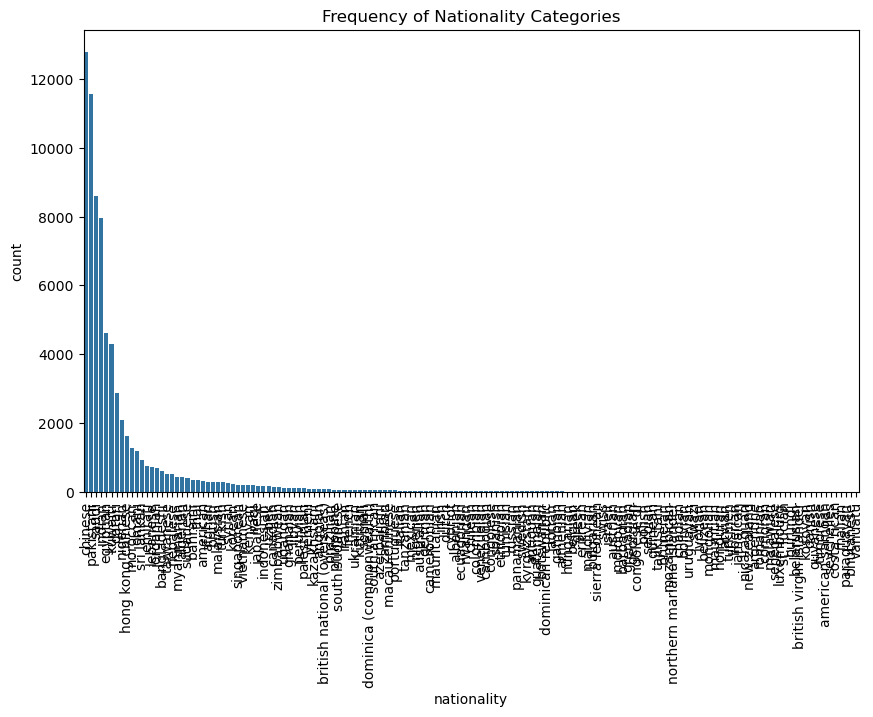

Outliers (infrequent categories):
nationality
uruguayan                  4
swazi                      4
ivorian                    4
belizean                   4
mongolian                  4
mauritian                  3
honduran                   3
latvian                    3
turkmen                    3
liberian                   3
jamaican                   3
nicaraguan                 3
new zealand                3
argentine                  3
romanian                   3
comoran                    3
malawian                   3
senegalese                 3
luxembourg                 2
st. lucian                 2
burundi                    2
belarusian                 2
british virgin islander    1
kosovan                    1
danish                     1
guyanese                   1
timorese                   1
american samoan            1
seychelles                 1
costa rican                1
malian                     1
paraguayan                 1
bhutanese                 

In [23]:
# Outlier analysis for Nationality column.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Count the frequency of each category in the 'nationality' column
category_counts = sgdata["nationality"].value_counts()

# Set a threshold for "outlier" categories (e.g., categories that appear less than 5 times)
threshold = 5
outliers = category_counts[category_counts < threshold]

# Identify rows in sgdata that belong to outlier categories
outlier_rows = sgdata[sgdata["nationality"].isin(outliers.index)]

# Visualize the frequencies of each category in a bar plot
plt.figure(figsize=(10, 6))
sns.countplot(x="nationality", data=sgdata, order=category_counts.index)
plt.xticks(rotation=90)
plt.title("Frequency of Nationality Categories")
plt.show()

# Print out the identified outliers and the rows containing them
print("Outliers (infrequent categories):")
print(outliers)
print("\nRows with outlier categories:")
print(outlier_rows)

In [3]:
# Check for duplicates
duplicates = sgdata[sgdata.duplicated()]

print("Duplicate Rows:")
print(duplicates)

Duplicate Rows:
Empty DataFrame
Columns: [centre, programme, area, region, sub_region, country, branch_urn, group_urn, lead_source, student_id, booking_id, nationality, intake_year, intake_quarter, application_date, offered_date, confirmation_date, arrived_date, cancellation_date, completed, progressed, registered, tuition_fees, net_value, discount, discount_type]
Index: []

[0 rows x 26 columns]


In [5]:
# Check for missing values
missing_values = sgdata.isnull().sum()

# View the output
print(missing_values)

centre                   0
programme                0
area                     0
region                   0
sub_region             808
country                  0
branch_urn               0
group_urn                0
lead_source              0
student_id               0
booking_id               0
nationality              0
intake_year              0
intake_quarter           0
application_date         0
offered_date         19862
confirmation_date    65318
arrived_date         67666
cancellation_date    57144
completed            67666
progressed           68059
registered           68500
tuition_fees             0
net_value                0
discount                 0
discount_type        69270
dtype: int64


**Fill the missing values in the 'columns with missing values.**

In [31]:
# Fill missing values in 'sub-region' column with the text 'region'
sgdata['sub_region'] = sgdata['sub_region'].fillna('region')

# Check the result
print(sgdata[['sub_region']])

# Check for missing values in the 'sub-region' column
missing_values_sub_region = sgdata['sub_region'].isna().sum()

# Print the number of missing values
print(f"Number of missing values in 'sub_region' column: {missing_values_sub_region}")

          sub_region
0          australia
1          hong kong
2          hong kong
3          hong kong
4          hong kong
...              ...
71749  uk & w europe
71750  uk & w europe
71751  uk & w europe
71752  uk & w europe
71753  uk & w europe

[71754 rows x 1 columns]
Number of missing values in 'sub_region' column: 0


In [9]:
# Fill missing values in 'offered_date', 'confirmation_date', 'arrived_date' , and 'cancellation_date' 
# columns with the text 'not specified'
sgdata[['offered_date', 
        'confirmation_date', 
        'arrived_date',
        'cancellation_date']] = sgdata[['offered_date', 
                                        'confirmation_date', 
                                        'arrived_date', 
                                        'cancellation_date']].fillna('not specified')

# Check the result
print(sgdata[['offered_date', 'confirmation_date', 'arrived_date', 'cancellation_date']])

        offered_date confirmation_date   arrived_date cancellation_date
0      not specified     not specified  not specified        10/05/2023
1         21/11/2023     not specified  not specified        03/01/2024
2         29/11/2023     not specified  not specified        03/01/2024
3      not specified     not specified  not specified     not specified
4         06/12/2023     not specified  not specified     not specified
...              ...               ...            ...               ...
71749     13/06/2023     not specified  not specified     not specified
71750     08/07/2023        21/07/2023  not specified        08/11/2023
71751     28/07/2023        28/07/2023     28/11/2023     not specified
71752     26/05/2023     not specified  not specified     not specified
71753     06/05/2023     not specified  not specified     not specified

[71754 rows x 4 columns]


In [11]:
# Check for missing values in 'offered_date', 'confirmation_date', 'arrived_date' , and 'cancellation_date' columns
missing_values = sgdata[['offered_date', 'confirmation_date', 'arrived_date', 'cancellation_date']].isna().sum()

# Print the number of missing values for each column
print(missing_values)

offered_date         0
confirmation_date    0
arrived_date         0
cancellation_date    0
dtype: int64


In [13]:
# Fill missing values in 'completed', 'progressed', and 'registered' columns with the text 'no'
sgdata[['completed', 'progressed', 'registered']] = sgdata[['completed', 'progressed', 'registered']].fillna('no')

# Check the result
print(sgdata[['completed', 'progressed', 'registered']])

      completed progressed registered
0            no         no         no
1            no         no         no
2            no         no         no
3            no         no         no
4            no         no         no
...         ...        ...        ...
71749        no         no         no
71750        no         no         no
71751      pass        yes        yes
71752        no         no         no
71753        no         no         no

[71754 rows x 3 columns]


In [15]:
# Check for missing values in 'completed', 'progressed', and 'registered' columns
missing_values = sgdata[['completed', 'progressed', 'registered']].isna().sum()

# Print the number of missing values for each column
print(missing_values)

completed     0
progressed    0
registered    0
dtype: int64


In [17]:
# Fill missing values in the 'discount_type' column with the text 'not specified'
sgdata['discount_type'] = sgdata['discount_type'].fillna('not specified')

# Check the result
print(sgdata[['discount_type']])

# Check for missing values in the 'discount_type' column
missing_values_discount_type = sgdata['discount_type'].isna().sum()

# Print the number of missing values
print(f"Number of missing values in 'discount_type' column: {missing_values_discount_type}")

       discount_type
0      not specified
1      not specified
2      not specified
3      not specified
4      not specified
...              ...
71749  not specified
71750  not specified
71751  not specified
71752  not specified
71753  not specified

[71754 rows x 1 columns]
Number of missing values in 'discount_type' column: 0


**Change column name.**

In [19]:
# Rename column
sgdata.rename(columns={'country': 'agent_location'}, inplace=True)

# Print the updated DataFrame
print(sgdata.head())

    centre programme          area     region sub_region agent_location  \
0  cardiff   diploma  anz & n asia        anz  australia      aus - vic   
1  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
2  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
3  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
4  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   

  branch_urn group_urn             lead_source  student_id  ...  \
0     a31552    a31552  standard agent booking     2864317  ...   
1     a15382    a29520  standard agent booking     2853769  ...   
2     a15382    a29520  standard agent booking     2863293  ...   
3      a7608     a7608  standard agent booking     2854643  ...   
4      d1107     d1107  standard agent booking     2871048  ...   

   confirmation_date   arrived_date  cancellation_date  completed progressed  \
0      not specified  not specified         10/05/2023         no 

**Convert intake_year column to date**

In [21]:
import pandas as pd
from datetime import date

# Convert to date
def convert_to_date(x):
    if isinstance(x, date):  
        return date(x.year, 1, 1)  
    else:
        return date(int(x), 1, 1)  

# Apply the function to convert 'intake_year' to a date object
sgdata['intake_year'] = sgdata['intake_year'].apply(convert_to_date)

# Check the result
print(sgdata['intake_year'])
print(sgdata['intake_year'].dtypes)

# Get unique values from the 'intake_year' column
unique_values = sgdata['intake_year'].unique()

# Print the unique values
print(unique_values)

0        2024-01-01
1        2024-01-01
2        2024-01-01
3        2024-01-01
4        2024-01-01
            ...    
71749    2023-01-01
71750    2023-01-01
71751    2023-01-01
71752    2023-01-01
71753    2023-01-01
Name: intake_year, Length: 71754, dtype: object
object
[datetime.date(2024, 1, 1) datetime.date(2023, 1, 1)]


**Basic descriptive statistics.**

In [23]:
# Determine the metadata of the data set.
metadata = sgdata.info()

# View the DataFrame.
print(metadata)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71754 entries, 0 to 71753
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   centre             71754 non-null  object 
 1   programme          71754 non-null  object 
 2   area               71754 non-null  object 
 3   region             71754 non-null  object 
 4   sub_region         70946 non-null  object 
 5   agent_location     71754 non-null  object 
 6   branch_urn         71754 non-null  object 
 7   group_urn          71754 non-null  object 
 8   lead_source        71754 non-null  object 
 9   student_id         71754 non-null  int64  
 10  booking_id         71754 non-null  int64  
 11  nationality        71754 non-null  object 
 12  intake_year        71754 non-null  object 
 13  intake_quarter     71754 non-null  int64  
 14  application_date   71754 non-null  object 
 15  offered_date       71754 non-null  object 
 16  confirmation_date  717

In [25]:
sgdata.describe()

,student_id,booking_id,intake_quarter,tuition_fees,net_value,discount
count,7.175400e+04,7.175400e+04,71754.000000,71754.000000,71754.000000,71754.000000
mean,2.814269e+06,4.394030e+07,2.731388,18223.435462,18103.217868,91.084139
std,4.650807e+05,4.218965e+05,0.994142,4192.043789,4196.214656,551.745647
min,3.798990e+05,2.475583e+07,1.000000,6950.000000,-112.000000,0.000000
25%,2.787310e+06,4.385661e+07,3.000000,14500.000000,14500.000000,0.000000
50%,2.823211e+06,4.398754e+07,3.000000,19250.000000,19125.000000,0.000000
75%,2.846213e+06,4.415893e+07,3.000000,20700.000000,20700.000000,0.000000
max,9.023152e+07,4.477511e+07,4.000000,29960.000000,29960.000000,9500.000000


In [33]:
# Check for missing values
missing_values = sgdata.isnull().sum()

# View the output
print(missing_values)

centre               0
programme            0
area                 0
region               0
sub_region           0
agent_location       0
branch_urn           0
group_urn            0
lead_source          0
student_id           0
booking_id           0
nationality          0
intake_year          0
intake_quarter       0
application_date     0
offered_date         0
confirmation_date    0
arrived_date         0
cancellation_date    0
completed            0
progressed           0
registered           0
tuition_fees         0
net_value            0
discount             0
discount_type        0
dtype: int64


**Save the cleaned dataset as an Excel file.**

In [39]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [40]:
# Save the cleaned dataset to an Excel file
sgdata.to_excel('cleaned_SG_data.xlsx', index=False, engine='openpyxl')

# Confirm the file is saved
print("Data saved as 'cleaned_SG_data.xlsx'")

Data saved as 'cleaned_SG_data.xlsx'


# 2. Explore the Dataset.

**How many centres are operating under StudyGroup?**

In [42]:
# Find unique values in centre column 
unique_values_c = sgdata['centre'].unique()

# Display the unique values
print(unique_values_c)
print(len(unique_values_c))

['cardiff' 'durham' 'kingston' 'leeds beckett' 'liverpool'
 'royal holloway' 'teesside' 'aberdeen' 'huddersfield' 'leeds' 'sheffield'
 'strathclyde' 'surrey' 'sussex' 'lancaster']
15


**How many programmes does StudyGroup offer to its students?**

In [46]:
# Find unique values in programme column 
unique_values_p = sgdata['programme'].unique()

# Display the unique values
print(unique_values_p)
print(len(unique_values_p))

['diploma' 'foundation' 'pre masters']
3


**From which areas do student come to study at StudyGroup?**

In [48]:
# Find unique values in area column 
unique_values_a = sgdata['area'].unique()

# Display the unique values
print(unique_values_a)
print(len(unique_values_a))

['anz & n asia' 'china' 'elmea & pakistan' 'se asia' 'south asia'
 'uk eu & americas']
6


**From which regions do student come to study at StudyGroup?**

In [536]:
# Find unique values in region column 
unique_values_r = sgdata['region'].unique()

# Display the unique values
print(unique_values_r)
print(len(unique_values_r))

['anz' 'hong kong' 'north asia' 'e c1 china' 'n c2 china' 's w china'
 'middle east' 'nigeria' 'pakistan' 'rest of africa'
 's europe, levant & n africa' 'se asia 1' 'se asia 2' 'india'
 'rest of s asia' 'na & lam' 'russia, e europe, c asia' 'uk & w europe']
18


**From which sub-regions do student come to study at StudyGroup?**

In [538]:
# Find unique values in sub_region column 
unique_values_s = sgdata['sub_region'].unique()

# Display the unique values
print(unique_values_s)
print(len(unique_values_s))

['australia' 'hong kong' 'korea' 'taiwan' 'c china 1' 'e china'
 'c china 2' 'n china' 's china' 'w china' 'kuwait, bahrain & qatar'
 'oman' 'saudi arabia' 'uae, iran & iraq' 'nigeria' 'pakistan'
 'rest of africa' 'n africa' 's europe, levant' 'thailand'
 'malaysia, brunei' 'myanmar' 'singapore' 'india' 'bangladesh' 'sri lanka'
 'region' 'central asia' 'eastern europe' 'uk & w europe' 'japan'
 'indonesia' 'nepal' 'lam' 'vietnam' 'cambodia, laos' 'philippines'
 'new zealand']
38


**How many nationalities applied to study at StudyGroup?**

In [540]:
# Find unique values in nationality column 
unique_values_naty = sgdata['nationality'].unique()

# Display the unique values
print(len(unique_values_naty))
print(unique_values_naty)

153
['bangladeshi' 'hong kong chinese' 'chinese' 'indian' 'korean' 'taiwanese'
 'egyptian' 'turkish' 'qatari' 'omani' 'saudi' 'jordanian' 'emirati'
 'nigerian' 'pakistani' 'congolese' 'british' 'kenyan' 'rwandan' 'ugandan'
 'zimbabwean' 'algerian' 'iraqi' 'thai' 'myanmarian' 'malaysian'
 'singaporean' 'sri lankan' 'turkmen' 'uzbek' 'azerbaijani' 'sudanese'
 'lebanese' 'angolan' 'israeli' 'japanese' 'bahraini' 'kuwaiti' 'canadian'
 'iranian' 'american' 'dominica (commonwealth)' 'french' 'australian'
 'somali' 'zambian' 'chilean' 'kittitian' 'indonesian' 'philippine'
 'nepalese' 'peruvian' 'burundi' 'kazakhstani' 'libyan' 'syrian' 'italian'
 'mauritanian' 'brazilian' 'south sudanese' 'moroccan' 'ghanaian'
 'ivorian' 'yemeni' 'afghan' 'vietnamese' 'macau chinese' 'portuguese'
 'irish' 'south african' 'guatemalan' 'german' 'tanzanian' 'cypriot'
 'laotian' 'cambodian' 'palestinian' 'liberian'
 'british national (overseas)' 'venezuelan' 'dutch' 'tunisian'
 'kyrgyzstani' 'congolese dr' 'mongo

**From how many agent locations do student come to study at study group?**

In [542]:
# Find unique values in country column 
unique_values_c = sgdata['agent_location'].unique()

# Display the unique values
print(len(unique_values_c))
print(unique_values_c)

111
['aus - vic' 'hong kong' 'korea' 'taiwan' 'anhui' 'hubei' 'jiangsu'
 'shanghai' 'zhejiang' 'shanxi' 'beijing' 'hebei' 'liaoning' 'shandong'
 'fujian' 'guangdong' 'hunan' 'sichuan' 'kuwait' 'qatar' 'oman'
 'saudi arabia' 'united arab emirates' 'nigeria' 'pakistan' 'kenya'
 'south africa' 'zimbabwe' 'algeria' 'egypt' 'jordan' 'lebanon' 'thailand'
 'malaysia' 'myanmar (burma)' 'singapore' 'india' 'bangladesh' 'sri lanka'
 'canada' 'kazakhstan' 'uzbekistan' 'azerbaijan' 'uk' 'aus - nsw' 'japan'
 'henan' 'shaanxi' 'bahrain' 'angola' 'uganda' 'zambia' 'libya' 'turkey'
 'indonesia' 'nepal' 'peru' 'jiangxi' 'tianjin' 'guangxi' 'yunnan'
 'vietnam' 'macau' 'gansu' 'ningxia' 'heilongjiang' 'inner mongolia'
 'chongqing' 'qinghai' 'xinjiang' 'albania' 'guatemala' 'mexico'
 'tanzania' 'morocco' 'laos' 'philippines' 'ghana' 'cambodia' 'panama'
 'united states' 'mongolia' 'venezuela' 'iraq' 'brazil' 'brunei'
 'colombia' 'ukraine' 'new zealand' 'bolivia' 'cameroon' 'aus - other'
 'jilin' 'guizhou' 

**How many intake year are present in the dataset?**

In [544]:
# Find unique values in intake year column 
unique_values_i = sgdata['intake_year'].unique()

# Display the unique values
print(unique_values_i)
print(len(unique_values_i))

[datetime.date(2024, 1, 1) datetime.date(2023, 1, 1)]
2


**How many intake quarters are present in the dataset?**

In [546]:
# Find unique values in intake_quarter column 
unique_values_iq= sgdata['intake_quarter'].unique()

# Display the unique values
print(len(unique_values_iq))
print(unique_values_iq)

4
[1 2 3 4]


**What are the different discount types provided to the students?**

In [548]:
# Find unique values in discount_type column 
unique_values_d = sgdata['discount_type'].unique()

# Display the unique values
print(len(unique_values_d))
print(unique_values_d)

292
['not specified' 'center of excellence - gbp 3500'
 'centre of excellence - gbp 3000' 'center of excellence - gbp 4500'
 'other scholarships / bursaries' 'price adjustment decrease'
 'center of excellence - gbp 3000' 'center of excellence 2500 gbp'
 'center of excellence - gbp 2500' 'center of excellence - gbp 4000'
 'center of excellence -3000gbp' 'center of excellence - gbp 1000'
 'center of excellence - 5000 gbp' 'center of excellence - gbp 5000'
 'center of excellence- 4500 gbp' 'center of excellence - gbp 2000'
 'course fee adjusted' 'center of excellence- 1000 gbp'
 'center of excellence - gbp 6500' 'centre for excellence'
 'center of excellence 5000 gbp' 'center of excellence'
 'course fee adjustment' 'centre of execellence' 'scholarship added'
 'price adjustment increase' 'price adjustment decrease-1,200 gbp'
 'centre of excellence gbp 5000' 'center of excellence- 1500'
 'center of excellence - gbp 1500' 'centre of excellence gbp 1500'
 'center of excellence - 1500' 'centre

**How many unique branch agents are present in the dataset?**

In [550]:
# Find unique values in branch_urn column 
unique_values_b = sgdata['branch_urn'].unique()

# Display the unique values
print(len(unique_values_b))
print(unique_values_b)

2331
['a31552' 'a15382' 'a7608' ... 'e29846' 'v29055' 'u11121']


**How many unique parent agents are present in the dataset?**

In [533]:
# Find unique values in group_urn column 
unique_values_gr = sgdata['group_urn'].unique()

# Display the unique values
print(len(unique_values_gr))
print(unique_values_gr)

1781
['a31552' 'a29520' 'a7608' ... 'e29846' 'v29055' 'u11121']


**What are the lead sources through which students come to study at StudyGroup?**

In [552]:
# Find unique values in lead_source column 
unique_values_ls = sgdata['lead_source'].unique()

# Display the unique values
print(len(unique_values_ls))
print(unique_values_ls)

3
['standard agent booking' 'apd' 'sponsor']


**What are the different categories in the completed column?**

In [554]:
# Find unique values in completed column 
unique_values_cpd = sgdata['completed'].unique()

# Display the unique values
print(len(unique_values_cpd))
print(unique_values_cpd)

4
['no' 'pass' 'fail' 'terminated']


**What are the different categories in the progressed column?**

In [556]:
# Find unique values in progressed column 
unique_values_pgd = sgdata['progressed'].unique()

# Display the unique values
print(len(unique_values_pgd))
print(unique_values_pgd)

2
['no' 'yes']


**What are the different discount amounts provided to the students?**

In [558]:
# Find unique values in progressed column 
unique_values_dis = sgdata['discount'].unique()

# Display the unique values
print(len(unique_values_dis))
print(unique_values_dis)

55
[   0.   3500.   3000.   4500.    260.   2500.   4000.   1000.   5000.
 2000.   2050.   6500.   1500.   1200.   6000.    500.   5500.   2728.
 1269.    235.    650.   1300.   1050.    900.    400.    750.   2100.
 6400.   1250.   1600.   1150.   3150.    250.    265.    360.   1208.33
 4250.   1850.   1750.   7612.   1400.   5250.   2550.    800.    950.
 7500.   6700.   1700.   9500.   5150.    700.   5650.    550.   5700.
  600.  ]


In [560]:
# Descriptive statistics for column 'discount'
print(sgdata['discount'].describe())

count    71754.000000
mean        91.084139
std        551.745647
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       9500.000000
Name: discount, dtype: float64


In [562]:
# Find unique values in offered_date column 
unique_values_off = sgdata['offered_date'].unique()

# Display the unique values
print(len(unique_values_off))
print(unique_values_off)

655
['not specified' '21/11/2023' '29/11/2023' '06/12/2023' '18/11/2023'
 '19/09/2023' '24/11/2023' '12/09/2023' '14/06/2023' '05/09/2023'
 '13/09/2023' '11/10/2023' '31/01/2024' '24/10/2023' '30/08/2023'
 '04/08/2023' '20/10/2023' '18/09/2023' '07/11/2023' '09/11/2023'
 '21/10/2023' '06/09/2023' '24/08/2023' '14/05/2024' '12/08/2023'
 '27/10/2023' '15/07/2023' '19/07/2023' '28/10/2023' '06/01/2024'
 '03/11/2023' '17/10/2023' '15/08/2023' '23/05/2024' '21/12/2022'
 '02/11/2023' '04/06/2024' '14/09/2023' '16/05/2023' '18/10/2023'
 '23/01/2024' '27/09/2023' '28/09/2023' '12/10/2023' '21/09/2023'
 '22/09/2023' '20/12/2023' '23/11/2023' '29/09/2023' '29/08/2023'
 '14/12/2023' '08/10/2023' '12/11/2023' '16/11/2023' '26/09/2023'
 '07/09/2023' '13/10/2023' '16/09/2023' '21/06/2023' '23/12/2023'
 '09/12/2023' '03/10/2023' '12/07/2023' '23/09/2023' '15/09/2023'
 '04/11/2023' '08/07/2023' '02/05/2023' '15/12/2023' '22/02/2024'
 '22/11/2023' '16/12/2023' '17/05/2024' '05/04/2024' '05/12/2023'
 '1

In [564]:
# Find unique values in confirmation_date column 
unique_values_conf = sgdata['confirmation_date'].unique()

# Display the unique values
print(len(unique_values_conf))
print(unique_values_conf)

498
['not specified' '30/11/2023' '12/09/2023' '04/11/2023' '16/08/2023'
 '16/11/2023' '01/12/2023' '19/12/2023' '28/11/2023' '29/11/2023'
 '06/12/2023' '09/12/2023' '18/11/2023' '02/02/2024' '14/12/2023'
 '23/12/2023' '07/02/2024' '19/10/2023' '06/02/2024' '26/09/2023'
 '19/01/2024' '16/12/2023' '20/09/2023' '21/10/2023' '20/12/2023'
 '27/12/2023' '02/08/2023' '05/11/2023' '06/10/2023' '04/10/2023'
 '01/11/2023' '15/11/2023' '12/12/2023' '31/01/2024' '25/11/2023'
 '22/02/2024' '24/10/2023' '19/11/2023' '21/12/2023' '07/11/2023'
 '28/09/2023' '15/09/2023' '22/12/2023' '13/01/2024' '05/03/2024'
 '17/10/2023' '07/10/2023' '15/12/2023' '17/11/2023' '24/11/2023'
 '13/12/2023' '12/01/2024' '26/01/2024' '29/08/2023' '05/12/2023'
 '23/09/2023' '19/08/2023' '20/07/2023' '27/09/2023' '08/12/2023'
 '28/08/2023' '02/12/2023' '27/05/2023' '22/03/2023' '30/03/2023'
 '27/10/2023' '08/04/2023' '08/11/2023' '22/03/2024' '16/09/2023'
 '17/08/2023' '12/10/2023' '22/08/2023' '14/10/2023' '01/07/2023'
 '2

In [566]:
# Find unique values in arrived_date column 
unique_values_arr = sgdata['arrived_date'].unique()

# Display the unique values
print(len(unique_values_arr))
print(unique_values_arr)

119
['not specified' '16/01/2024' '17/01/2024' '18/01/2024' '13/03/2024'
 '31/01/2024' '07/02/2024' '26/01/2024' '19/03/2024' '10/01/2024'
 '11/01/2024' '19/01/2024' '13/01/2024' '12/01/2024' '21/02/2024'
 '21/01/2024' '30/01/2024' '27/01/2024' '24/01/2024' '14/01/2024'
 '23/01/2024' '25/01/2024' '20/01/2024' '26/04/2024' '24/04/2024'
 '09/01/2024' '01/02/2024' '16/04/2024' '17/04/2024' '23/04/2024'
 '20/04/2024' '06/03/2024' '05/03/2024' '14/02/2024' '08/02/2024'
 '21/05/2024' '28/01/2024' '15/06/2024' '03/07/2024' '11/06/2024'
 '18/06/2024' '07/03/2024' '26/03/2024' '09/04/2024' '27/03/2024'
 '06/02/2024' '17/03/2024' '12/03/2024' '20/03/2024' '28/03/2024'
 '05/04/2024' '15/02/2024' '14/05/2024' '20/05/2024' '27/02/2024'
 '09/02/2024' '30/04/2024' '08/03/2024' '29/11/2023' '27/09/2023'
 '29/09/2023' '03/10/2023' '10/10/2023' '30/09/2023' '13/10/2023'
 '07/10/2023' '28/09/2023' '04/10/2023' '06/10/2023' '26/09/2023'
 '01/10/2023' '17/10/2023' '30/11/2023' '07/12/2023' '01/12/2023'
 '0

In [568]:
# Find unique values in cancellation_date column 
unique_values_canc = sgdata['cancellation_date'].unique()

# Display the unique values
print(len(unique_values_canc))
print(unique_values_canc)

246
['10/05/2023' '03/01/2024' 'not specified' '03/03/2024' '01/05/2024'
 '07/05/2024' '12/05/2023' '06/12/2024' '12/06/2023' '01/03/2024'
 '01/04/2024' '08/02/2024' '01/10/2024' '10/03/2023' '11/02/2023'
 '10/06/2023' '10/10/2023' '11/10/2023' '11/09/2023' '11/07/2023'
 '10/08/2023' '08/10/2023' '11/08/2023' '10/11/2023' '10/04/2023'
 '06/07/2023' '02/01/2024' '11/04/2023' '11/11/2023' '04/05/2024'
 '02/02/2024' '10/12/2023' '02/03/2024' '10/07/2023' '09/03/2023'
 '01/12/2024' '12/02/2023' '04/02/2024' '05/07/2024' '07/08/2023'
 '04/10/2024' '09/02/2023' '11/05/2023' '06/09/2023' '12/01/2023'
 '05/11/2024' '09/09/2023' '03/02/2024' '12/12/2023' '02/09/2024'
 '08/04/2023' '12/09/2023' '02/10/2024' '02/07/2024' '01/06/2024'
 '08/11/2023' '12/07/2023' '08/01/2023' '09/05/2023' '07/12/2023'
 '11/03/2023' '03/06/2024' '04/09/2024' '07/11/2023' '05/02/2023'
 '11/01/2023' '12/08/2023' '01/09/2024' '02/08/2024' '01/11/2024'
 '09/07/2023' '02/04/2024' '04/04/2023' '08/09/2023' '09/04/2024'
 '0

# 3. Application analysis

In [570]:
# Make a copy of the sgdata DataFrame
sgdata_copy = sgdata.copy()

# Display the output
print(sgdata_copy.head())

    centre programme          area     region sub_region agent_location  \
0  cardiff   diploma  anz & n asia        anz  australia      aus - vic   
1  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
2  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
3  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
4  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   

  branch_urn group_urn             lead_source  student_id  ...  \
0     a31552    a31552  standard agent booking     2864317  ...   
1     a15382    a29520  standard agent booking     2853769  ...   
2     a15382    a29520  standard agent booking     2863293  ...   
3      a7608     a7608  standard agent booking     2854643  ...   
4      d1107     d1107  standard agent booking     2871048  ...   

   confirmation_date   arrived_date cancellation_date  completed progressed  \
0      not specified  not specified        10/05/2023         no   

**What is the total number of student id per intake year?**

In [572]:
# Grouping by 'intake_year' and counting the number of students in each year
student_counts = sgdata_copy.groupby('intake_year')['student_id'].count().reset_index()

# Rename the columns 
student_counts.columns = ['intake_year', 'Total_student_id']

# Print the result
print(student_counts)

  intake_year  Total_student_id
0  2023-01-01             54631
1  2024-01-01             17123


**How many unique student id are present in the dataset?**

In [574]:
# Find unique values in student_id column 
unique_values_std = sgdata_copy['student_id'].unique()

# Display the unique values
print(len(unique_values_std))
print(unique_values_std)

37238
[2864317 2853769 2863293 ... 2840577 2382877 2806717]


**What is the total number of unique student id per intake year?**

In [935]:
# Counting unique student IDs by intake year
unique_student_counts = sgdata_copy.groupby('intake_year')['student_id'].nunique().reset_index()

# Rename the columns 
unique_student_counts.columns = ['intake_year', 'Total_unique_student_id']

# Print the result
print(unique_student_counts)

  intake_year  Total_unique_student_id
0  2023-01-01                    29366
1  2024-01-01                    10785


**What is the total number of common student id in both intake years?**

In [1023]:
from datetime import datetime
import pandas as pd

# Intake years 
intake_year_1 = datetime(2023, 1, 1)
intake_year_2 = datetime(2024, 1, 1)

# Ensure 'intake_year' is in datetime format 
sgdata_copy['intake_year'] = pd.to_datetime(sgdata_copy['intake_year'])

# Get student IDs for each intake year
students_year_1 = sgdata_copy[sgdata_copy['intake_year'] == intake_year_1]['student_id']
students_year_2 = sgdata_copy[sgdata_copy['intake_year'] == intake_year_2]['student_id']

# Find the common student IDs between the two years
common_students = students_year_1[students_year_1.isin(students_year_2)]

# Count the number of common student IDs
num_common_students = common_students.nunique()

# Print the result
print(f"Number of student IDs present in both intake years: {num_common_students}")

Number of student IDs present in both intake years: 2913


**Which study centre have received the most number of applications?**

In [576]:
# Group by 'centre' and count the number of applications for each centre
applications_by_centre = sgdata_copy.groupby('centre').size()

# Find the centre with the most applications
most_applications_centre = applications_by_centre.idxmax()
most_applications_centre_count = applications_by_centre.max()

# Print the result with correct f-string formatting
print(f"The centre that have received the most number of applications "
      f"is '{most_applications_centre}' with {most_applications_centre_count} applications.")

The centre that have received the most number of applications is 'sheffield' with 10073 applications.


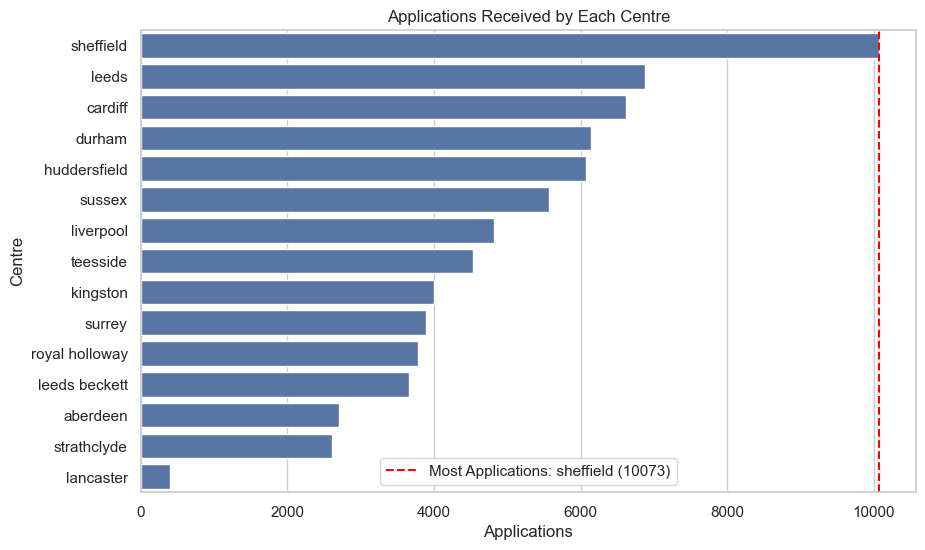

In [578]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count applications per centre
applications_by_centre = sgdata_copy.groupby('centre').size().reset_index(name='applications')

# Sort by number of applications
applications_by_centre_sorted = applications_by_centre.sort_values(by='applications', ascending=False)

# Create bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='applications', y='centre', data=applications_by_centre_sorted)

# Highlight centre with most applications
plt.axvline(x=most_applications_centre_count, color='red', linestyle='--', 
            label=f'Most Applications: {most_applications_centre} ({most_applications_centre_count})')

# Add title, labels, and legend
plt.title('Applications Received by Each Centre')
plt.xlabel('Applications')
plt.ylabel('Centre')
plt.legend()

# Show plot
plt.show()

**Find the centres that have received the most number of applications per intake year?**

In [580]:
# Group by 'intake_year' and 'centre' and count the number of unique student applications
unique_applications_by_year_centre = sgdata_copy.groupby(
    ['intake_year', 'centre'])['student_id'].nunique().reset_index(
    name='unique_applications'
)

# Sort the results in descending order to get the centres with the most unique applications for each intake year
unique_applications_by_year_centre_sorted = unique_applications_by_year_centre.sort_values(
    by=['intake_year', 'unique_applications'], 
    ascending=[True, False]
)

# Print the result
print("Centres with the most unique applications per intake year:")
print(unique_applications_by_year_centre_sorted)

Centres with the most unique applications per intake year:
   intake_year          centre  unique_applications
10  2023-01-01       sheffield                 7570
6   2023-01-01           leeds                 5274
1   2023-01-01         cardiff                 5236
2   2023-01-01          durham                 4806
3   2023-01-01    huddersfield                 4238
13  2023-01-01          sussex                 4232
8   2023-01-01       liverpool                 3405
14  2023-01-01        teesside                 3220
12  2023-01-01          surrey                 2889
9   2023-01-01  royal holloway                 2655
7   2023-01-01   leeds beckett                 2625
4   2023-01-01        kingston                 2243
0   2023-01-01        aberdeen                 2175
11  2023-01-01     strathclyde                 1977
5   2023-01-01       lancaster                  403
24  2024-01-01       sheffield                 2406
18  2024-01-01    huddersfield                 1692
20  2

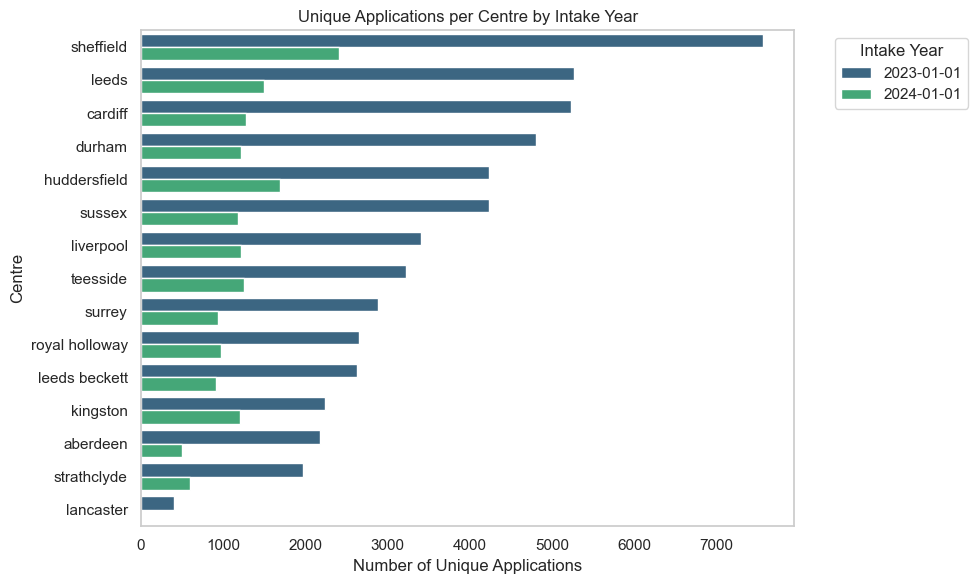

In [582]:
# Create visualisation for Centres with the most unique applications per intake year.
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(10, 6))

# Create a barplot with Seaborn
sns.barplot(
    x='unique_applications', 
    y='centre', 
    hue='intake_year', 
    data=unique_applications_by_year_centre_sorted, 
    palette='viridis'
)

# Add labels and title
plt.xlabel('Number of Unique Applications')
plt.ylabel('Centre')
plt.title('Unique Applications per Centre by Intake Year')

# Move the legend outside the plot
plt.legend(
    title='Intake Year', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left'
)

# Remove gridlines
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

**Which nationality have applied the most to study at StudyGroup?**

In [584]:
# Group by 'nationality' and count the total number of students (applications) 
# for each nationality
total_applications_by_nationality = sgdata_copy.groupby('nationality')['student_id'].nunique()

# Sort the results by count of students in descending order and get the top 15
top_30_nationalities_by_applications = total_applications_by_nationality.sort_values(
    ascending=False
).head(30)

# Display the result
print("Nationalities with the highest total number of unique applications, Top 30:")
print(top_30_nationalities_by_applications)

Nationalities with the highest total number of unique applications, Top 30:
nationality
chinese              8157
pakistani            5595
indian               4721
saudi                3983
kuwaiti              2324
egyptian             1495
nigerian             1380
qatari               1015
hong kong chinese     925
sri lankan            480
emirati               412
omani                 407
nepalese              372
moroccan              359
bangladeshi           357
jordanian             313
taiwanese             307
myanmarian            260
lebanese              248
algerian              225
thai                  208
malaysian             187
bahraini              186
korean                178
turkish               173
singaporean           156
sudanese              147
vietnamese            144
afghan                142
kenyan                137
Name: student_id, dtype: int64


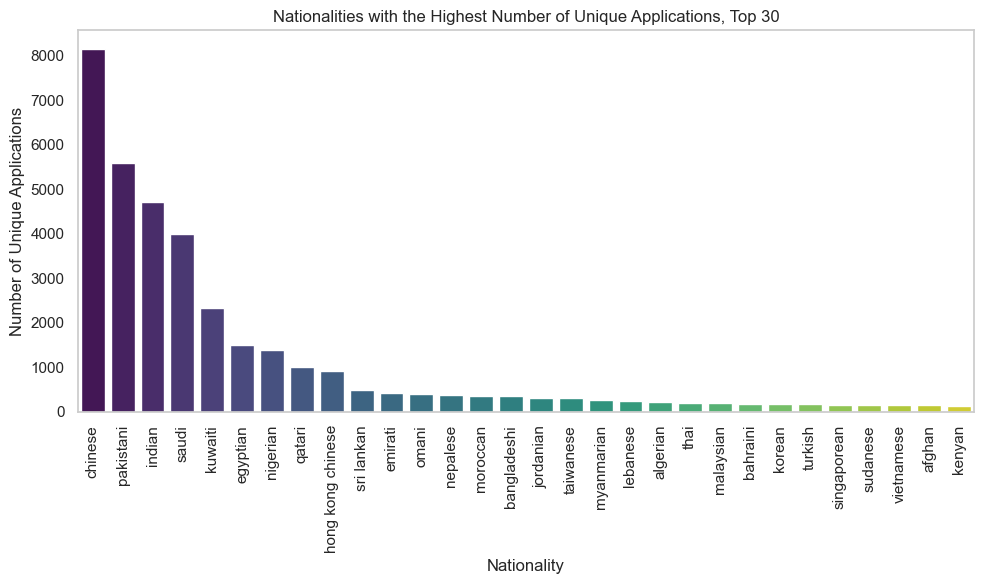

In [586]:
# Create Visualisation for Nationalities with the highest total number of unique applications, Top 30
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(10, 6))

# Create a barplot for the top 30 nationalities by the total number of unique applications
sns.barplot(
    x=top_30_nationalities_by_applications.index, 
    y=top_30_nationalities_by_applications.values, 
    hue=top_30_nationalities_by_applications.index,  
    palette='viridis',
    legend=False 
)

# Add labels and title
plt.xlabel('Nationality')
plt.ylabel('Number of Unique Applications')
plt.title('Nationalities with the Highest Number of Unique Applications, Top 30')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Remove the grid
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

In [588]:
# In Percentages, Nationalities with the Highest Number of Unique Applications, Top 30.

import pandas as pd

# Group by 'nationality' and count the total number of unique students 
# for each nationality
total_applications_by_nationality = sgdata_copy.groupby(
    'nationality')['student_id'].nunique()

# Calculate the total number of unique applications across all nationalities
total_unique_applications = total_applications_by_nationality.sum()

# Calculate the percentage of applications for each nationality
total_applications_by_nationality_percentage = (
    (total_applications_by_nationality / total_unique_applications) * 100
)

# Sort the results by percentage in descending order and get the top 30
top_30_nationalities_by_applications_percentage = (
    total_applications_by_nationality_percentage.sort_values(ascending=False)
    .head(30)
)

# Display the result
print("Distribution of unique applications in percentages"
      " by Nationality, Top 30:")
print(top_30_nationalities_by_applications_percentage)

Distribution of unique applications in percentages by Nationality, Top 30:
nationality
chinese              21.859842
pakistani            14.993970
indian               12.651749
saudi                10.673992
kuwaiti               6.228058
egyptian              4.006432
nigerian              3.698245
qatari                2.720086
hong kong chinese     2.478896
sri lankan            1.286346
emirati               1.104114
omani                 1.090714
nepalese              0.996918
moroccan              0.962080
bangladeshi           0.956720
jordanian             0.838805
taiwanese             0.822725
myanmarian            0.696771
lebanese              0.664612
algerian              0.602975
thai                  0.557417
malaysian             0.501139
bahraini              0.498459
korean                0.477020
turkish               0.463621
singaporean           0.418062
sudanese              0.393943
vietnamese            0.385904
afghan                0.380544
kenyan        

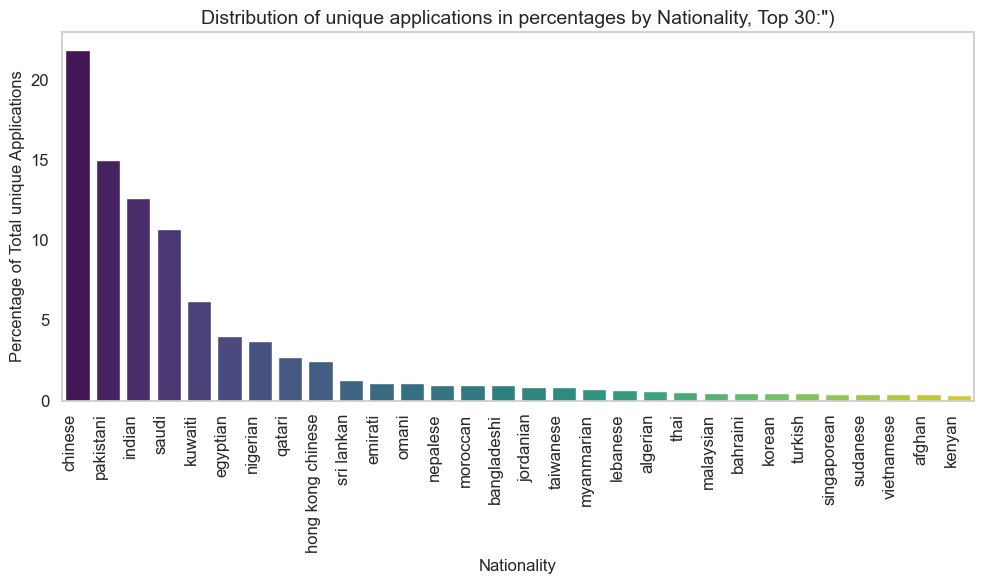

In [590]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualization of Nationalities by Percentage of Unique Applications, Top 30 
plt.figure(figsize=(10, 6))

# Create the bar plot with hue as x to avoid FutureWarning
sns.barplot(
    x=top_30_nationalities_by_applications_percentage.index,
    y=top_30_nationalities_by_applications_percentage.values,
    hue=top_30_nationalities_by_applications_percentage.index, 
    palette='viridis',
    legend=False
)

# Set the labels and title
plt.xlabel('Nationality', fontsize=12)
plt.ylabel('Percentage of Total unique Applications', fontsize=12)
plt.title('Distribution of unique applications in percentages by Nationality, Top 30:")', fontsize=14
)
plt.xticks(rotation=90, ha="right", fontsize=12)
plt.yticks(fontsize=12)

# Remove the gridlines
plt.grid(False)

# Display the plot
plt.tight_layout()
plt.show()

**From which area most of the applications come from?**

In [592]:
# Group by 'area' and count the number of unique 'student_id' (applications) for each lead source
applications_by_area = sgdata_copy.groupby('area')['student_id'].nunique()

# Sort the results in descending order to get the lead source with the most applications
applications_by_area_sorted = applications_by_area.sort_values(ascending=False)

# Display the result
print("Total number of unique applications by area:")
print(applications_by_area_sorted)

Total number of unique applications by area:
area
elmea & pakistan    12498
uk eu & americas     9485
china                7535
south asia           5656
anz & n asia         1757
se asia              1162
Name: student_id, dtype: int64


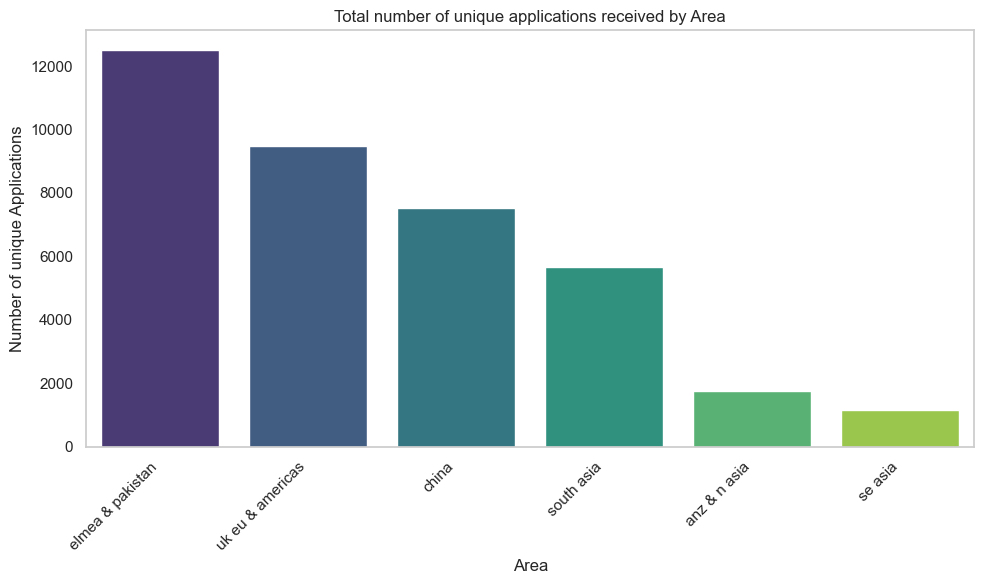

In [594]:
# Create visualisation for Total number of unique applications received by Area.
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot 
plt.figure(figsize=(10, 6))
sns.barplot(x=applications_by_area_sorted.index, y=applications_by_area_sorted.values, palette='viridis', 
            hue=applications_by_area_sorted.index, legend=False)

# Add labels and title
plt.xlabel('Area')
plt.ylabel('Number of unique Applications')
plt.title('Total number of unique applications received by Area')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove grid
plt.grid(False)

# Save the plot to a file 
plt.savefig("Total number of unique applications received by Area.png")

# Show the plot
plt.tight_layout()
plt.show()

In [596]:
# Group by 'area' and count the number of unique 'student_id' (applications) for each area
applications_by_area = sgdata_copy.groupby('area')['student_id'].nunique()

# Sort the results in descending order to get the areas with the most applications
applications_by_area_sorted = applications_by_area.sort_values(ascending=False)

# Calculate the percentage of applications for each area
total_applications = applications_by_area.sum()  # Total number of unique applications
applications_by_area_percentage = (applications_by_area_sorted / total_applications) * 100

# Display the result in percentages
print("Total number of unique applications received by area (in percentages):")
print(applications_by_area_percentage)

Total number of unique applications received by area (in percentages):
area
elmea & pakistan    32.809178
uk eu & americas    24.899588
china               19.780537
south asia          14.847872
anz & n asia         4.612396
se asia              3.050429
Name: student_id, dtype: float64


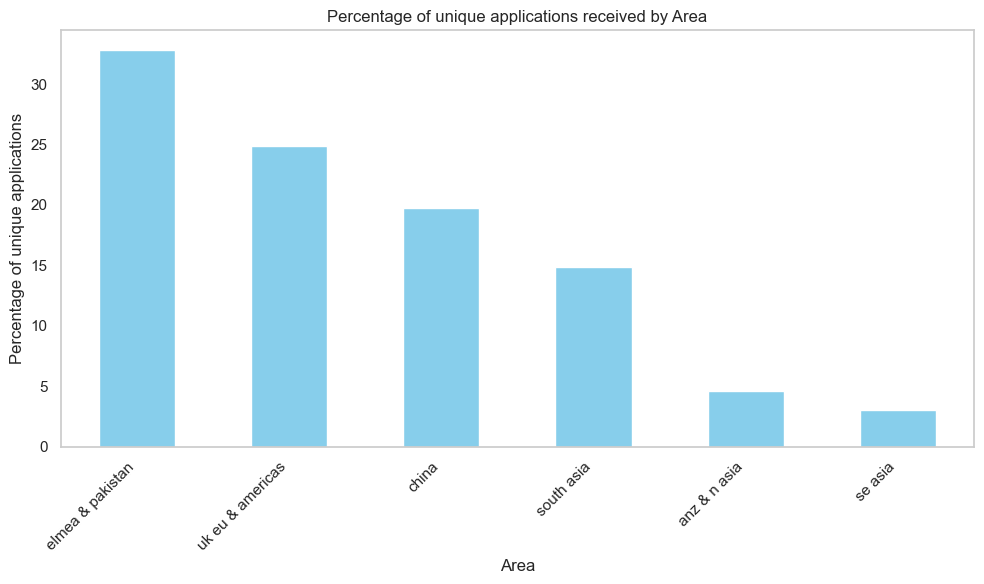

In [598]:
import matplotlib.pyplot as plt

# Create a bar plot for the percentage of applications by area
plt.figure(figsize=(10, 6))
applications_by_area_percentage.plot(kind='bar', color='skyblue')

# Add labels and title
plt.title('Percentage of unique applications received by Area')
plt.xlabel('Area')
plt.ylabel('Percentage of unique applications')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Remove grid
plt.grid(False)

# Save the plot to a file (e.g., PNG format)
plt.savefig("Percentage of unique Applications recevived by Area.png")

# Show the plot
plt.tight_layout()
plt.show()

**What is the distribution of unique applications received by region?**

In [600]:
# Group by 'region' and count the number of unique 'student_id' (applications) for each lead source
applications_by_region = sgdata_copy.groupby('region')['student_id'].nunique()

# Sort the results in descending order to get the lead source with the most applications
applications_by_region_sorted = applications_by_region.sort_values(ascending=False)

# Display the result
print("Total number of unique applications by region:")
print(applications_by_region_sorted)

Total number of unique applications by region:
region
uk & w europe                  8509
middle east                    5181
india                          4702
pakistan                       4314
n c2 china                     2864
e c1 china                     2671
s w china                      2043
s europe, levant & n africa    1746
hong kong                       993
rest of s asia                  963
nigeria                         890
na & lam                        823
se asia 2                       792
north asia                      609
rest of africa                  434
se asia 1                       372
russia, e europe, c asia        167
anz                             157
Name: student_id, dtype: int64


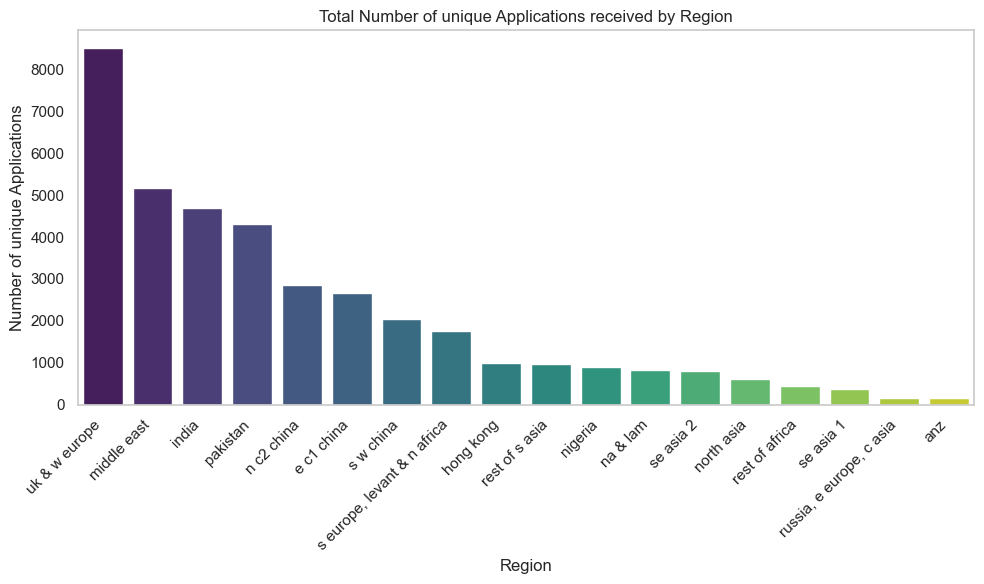

In [602]:
# Create visualisation for Total Number of unique Applications received by Region.
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot 
plt.figure(figsize=(10, 6))
sns.barplot(x=applications_by_region_sorted.index, y=applications_by_region_sorted.values, palette='viridis', 
            hue=applications_by_region_sorted.index, legend=False)

# Add labels and title
plt.xlabel('Region')
plt.ylabel('Number of unique Applications')
plt.title('Total Number of unique Applications received by Region')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove grid
plt.grid(False)

# Save the plot to a file 
plt.savefig("Total Number of unique Applications received by Region.png")

# Show the plot
plt.tight_layout()
plt.show()


In [604]:
# Calculate Percentage of unique applications by region
import pandas as pd

# Group by 'region' and count the number of unique 'student_id' for each region
applications_by_region = sgdata_copy.groupby('region')['student_id'].nunique()

# Calculate the total number of applications
total_applications = applications_by_region.sum()

# Calculate the percentage of applications by region
applications_by_region_percentage = (applications_by_region / total_applications) * 100

# Sort the results in descending order
applications_by_region_percentage_sorted = applications_by_region_percentage.sort_values(ascending=False)

# Display the result in percentages
print("Percentage of unique applications by region:")
print(applications_by_region_percentage_sorted)

Percentage of unique applications by region:
region
uk & w europe                  22.257389
middle east                    13.552184
india                          12.299241
pakistan                       11.284332
n c2 china                      7.491499
e c1 china                      6.986660
s w china                       5.343971
s europe, levant & n africa     4.567094
hong kong                       2.597437
rest of s asia                  2.518964
nigeria                         2.328015
na & lam                        2.152760
se asia 2                       2.071671
north asia                      1.592990
rest of africa                  1.135234
se asia 1                       0.973058
russia, e europe, c asia        0.436830
anz                             0.410672
Name: student_id, dtype: float64


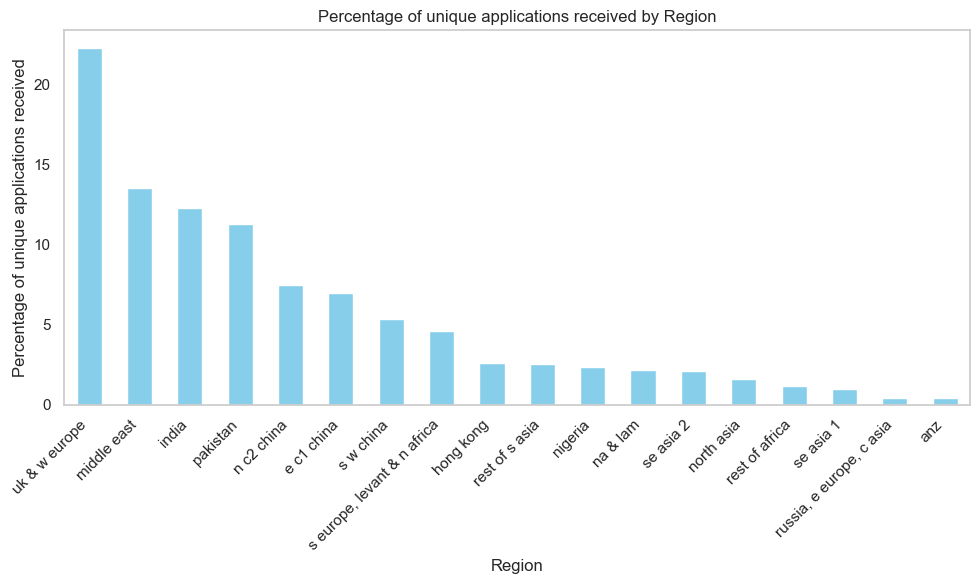

In [106]:
# Create Visualisation for Percentage of unique applications by region.
import matplotlib.pyplot as plt

# Plotting the percentage of applications by region
plt.figure(figsize=(10, 6))
applications_by_region_percentage_sorted.plot(kind='bar', color='skyblue')

# Adding labels and title
plt.xlabel('Region')
plt.ylabel('Percentage of unique applications received')
plt.title('Percentage of unique applications received by Region')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove the grid
plt.grid(False)

# Save the plot to a file 
plt.savefig("Percentage of unique applications received by Region.png")

# Display the plot
plt.tight_layout()
plt.show()

**What is the distribution of unique applications received by sub-region?**

In [606]:
# Group by 'sub_region' and count the number of unique 'student_id' (applications) for each sub_region
unique_applications_by_sub_region = sgdata_copy.groupby('sub_region')['student_id'].nunique()

# Sort the results in descending order to get the sub_region with the most applications
unique_applications_by_sub_region_sorted = unique_applications_by_sub_region.sort_values(ascending=False)

# Get the top 10 sub-regions
top_10_unique_applications_by_sub_region = unique_applications_by_sub_region_sorted.head(10)

# Display the result
print("Top 10 sub-regions with the most unique applications:")
print(top_10_unique_applications_by_sub_region)

Top 10 sub-regions with the most unique applications:
sub_region
uk & w europe              8509
india                      4702
pakistan                   4314
n china                    2455
kuwait, bahrain & qatar    2396
e china                    2075
saudi arabia               1619
s china                    1471
n africa                   1108
hong kong                   993
Name: student_id, dtype: int64


In [608]:
# Top 10 sub-regions by percentage of unique applications.
import pandas as pd

# Group by 'sub_region' and count the number of unique 'student_id' for each region
unique_applications_by_sub_region = sgdata_copy.groupby('sub_region')['student_id'].nunique()

# Calculate the total number of unique applications
total_applications = unique_applications_by_sub_region.sum()

# Calculate the percentage of unique applications by region
unique_applications_by_region_percentage = (unique_applications_by_sub_region / total_applications) * 100

# Sort the results in descending order
unique_applications_by_sub_region_percentage_sorted = unique_applications_by_region_percentage.sort_values(ascending=False)

# Get the top 10 sub-regions
top_10_unique_applications_by_sub_region_percentage = unique_applications_by_sub_region_percentage_sorted.head(10)

# Display the result in percentages
print("Top 10 sub-regions by percentage of unique applications:")
print(top_10_unique_applications_by_sub_region_percentage)

Top 10 sub-regions by percentage of unique applications:
sub_region
uk & w europe              22.233545
india                      12.286065
pakistan                   11.272243
n china                     6.414779
kuwait, bahrain & qatar     6.260615
e china                     5.421860
saudi arabia                4.230357
s china                     3.843641
n africa                    2.895143
hong kong                   2.594654
Name: student_id, dtype: float64


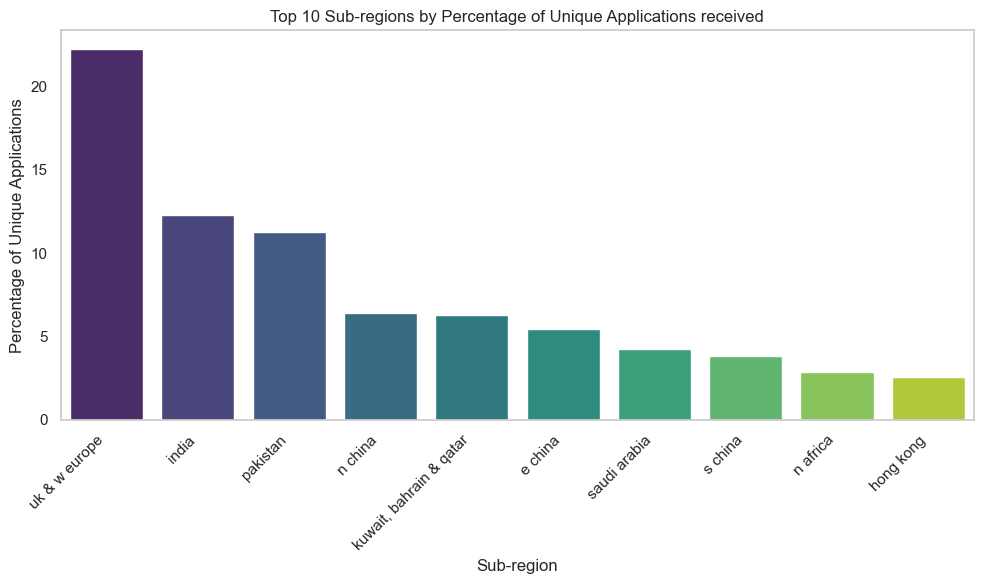

In [610]:
# Create visualisation for Top 10 sub-regions by percentage of unique application.
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the top 10 sub-regions by the percentage of unique applications
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_unique_applications_by_sub_region_percentage.index, 
            y=top_10_unique_applications_by_sub_region_percentage.values, 
            palette='viridis', hue=top_10_unique_applications_by_sub_region_percentage.index)

# Add labels and title
plt.xlabel('Sub-region')
plt.ylabel('Percentage of Unique Applications')
plt.title('Top 10 Sub-regions by Percentage of Unique Applications received')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove gridlines
plt.grid(False)

# Display the plot
plt.tight_layout()
plt.show()

**Which lead source brings the most number of applications?**

In [612]:
# Group by 'lead_source' and count the total number of students (applications)
total_applications_by_lead_source = sgdata_copy.groupby('lead_source')['student_id'].nunique()

# Sort the result by the number of applications in descending order
total_applications_by_lead_source_sorted = total_applications_by_lead_source.sort_values(ascending=False)

# Display the sorted result
print("Total unique applications by lead source (sorted):")
print(total_applications_by_lead_source_sorted)

Total unique applications by lead source (sorted):
lead_source
standard agent booking    30208
sponsor                    7333
apd                          64
Name: student_id, dtype: int64


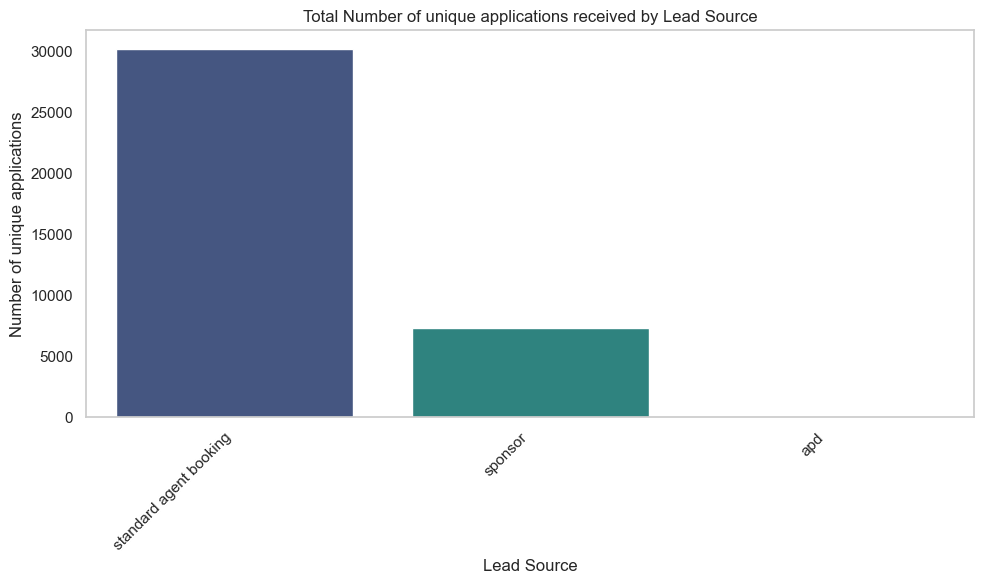

In [614]:
# Create visualisation for Total Number of unique applications received by Lead Source.
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot 
plt.figure(figsize=(10, 6))
sns.barplot(x=total_applications_by_lead_source_sorted.index, 
            y=total_applications_by_lead_source_sorted.values, 
            palette='viridis', hue=total_applications_by_lead_source_sorted.index, 
            legend=False)

# Add labels and title
plt.xlabel('Lead Source')
plt.ylabel('Number of unique applications')
plt.title('Total Number of unique applications received by Lead Source')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove grid
plt.grid(False)

# Save the plot to a file
plt.savefig("Total Number of unique applications received by Lead Source.png")

# Show the plot
plt.tight_layout()
plt.show()

In [616]:
# Group by 'lead_source' and count unique 'student_id' values (applications)
total_applications_by_lead_source = sgdata.groupby('lead_source')['student_id'].nunique()

# Calculate the total number of applications
total_applications = total_applications_by_lead_source.sum()

# Calculate the percentage of applications from each lead source
applications_percentage_by_lead_source = (total_applications_by_lead_source / total_applications) * 100

# Sort the percentages in descending order
applications_percentage_by_lead_source_sorted = applications_percentage_by_lead_source.sort_values(ascending=False)

# Display the result
print("Total unique applications by lead source in percentages (sorted):")
print(applications_percentage_by_lead_source_sorted)

Total unique applications by lead source in percentages (sorted):
lead_source
standard agent booking    80.329743
sponsor                   19.500066
apd                        0.170190
Name: student_id, dtype: float64


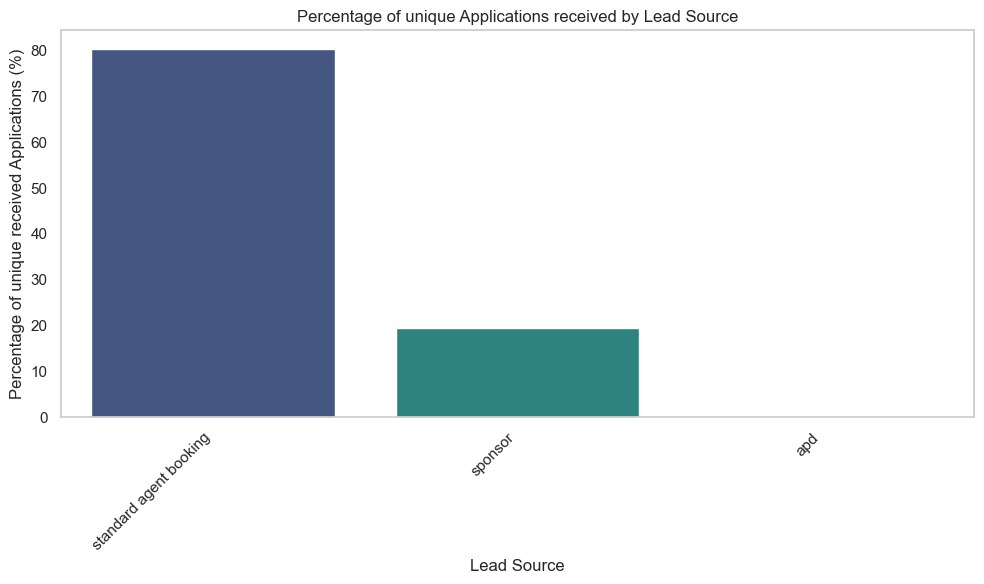

In [618]:
# Create visualisation for Percentage of unique applications received by Lead Source.
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for percentages
plt.figure(figsize=(10, 6))
sns.barplot(x=applications_percentage_by_lead_source_sorted.index, 
            y=applications_percentage_by_lead_source_sorted.values, 
            palette='viridis', hue=applications_percentage_by_lead_source_sorted.index, 
            legend=False)

# Add labels and title
plt.xlabel('Lead Source')
plt.ylabel('Percentage of unique received Applications (%)')
plt.title('Percentage of unique Applications received by Lead Source')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove grid
plt.grid(False)

# Save the plot to a file
plt.savefig("Percentage of unique received Applications by Lead Source.png")

# Show the plot
plt.tight_layout()
plt.show()

**Which program receives the most number of unique applications?**

In [620]:
# Calculate the total number of unique applications (unique student_id values overall)
total_unique_applications_overall = sgdata_copy['student_id'].nunique()

# Display the result
print(f"Total number of unique applications overall: {total_unique_applications_overall}")

Total number of unique applications overall: 37238


In [622]:
# Group by 'programme' and count unique 'student_id' values (applications)
total_unique_applications_by_programme = sgdata_copy.groupby('programme')['student_id'].nunique()

# Sort the results in descending order to find the programme with the most applications
total_unique_applications_by_programme_sorted = total_unique_applications_by_programme.sort_values(ascending=False)

# Display the distribution of unique applications by programme
print("\nDistribution of Unique Applications by Programme:")
print(total_unique_applications_by_programme_sorted)


Distribution of Unique Applications by Programme:
programme
foundation     22476
pre masters     9085
diploma         7618
Name: student_id, dtype: int64


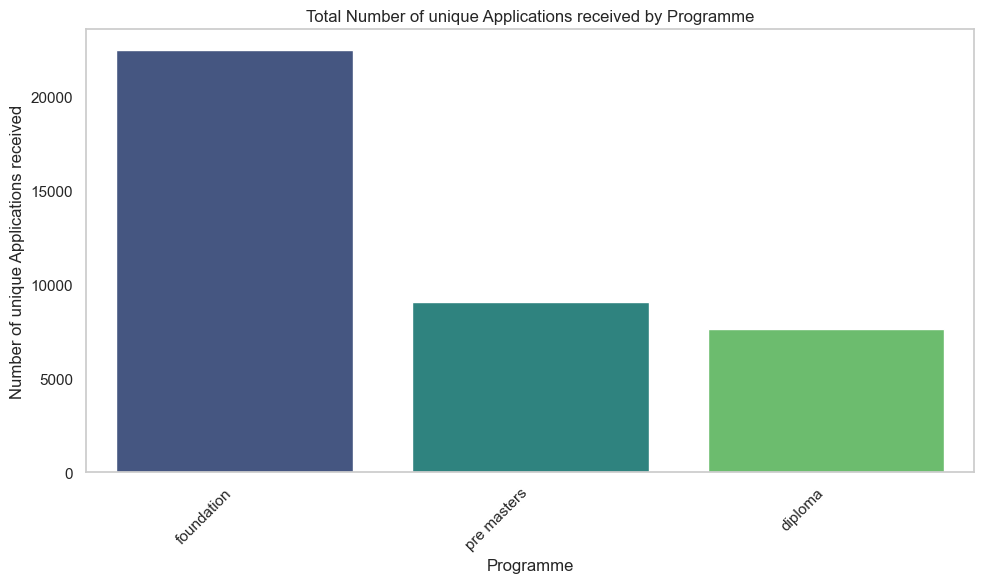

In [624]:
# Create visualisation for Total Number of unique Applications received by Programme.
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot 
plt.figure(figsize=(10, 6))
sns.barplot(x=total_unique_applications_by_programme_sorted.index, 
            y=total_unique_applications_by_programme_sorted.values, 
            palette='viridis', hue=total_unique_applications_by_programme_sorted.index, 
            legend=False)

# Add labels and title
plt.xlabel('Programme')
plt.ylabel('Number of unique Applications received')
plt.title('Total Number of unique Applications received by Programme')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove grid
plt.grid(False)

# Save the plot to a file
plt.savefig("Total Number of unique Applications received by Programme.png")

# Show the plot
plt.tight_layout()
plt.show()

In [626]:
# Total unique applications by programme in percentages.
# Group by 'programme' and count unique 'student_id' values (applications)
total_unique_applications_by_programme = sgdata_copy.groupby('programme')['student_id'].nunique()

# Calculate the total number of applications
total_unique_applications = total_unique_applications_by_programme.sum()

# Calculate the percentage of applications from each programme
unique_applications_percentage_by_programme = (total_unique_applications_by_programme / total_unique_applications) * 100

# Sort the result in descending order
unique_applications_percentage_by_programme_sorted = unique_applications_percentage_by_programme.sort_values(ascending=False)

# Display the result
print("Total unique applications by programme in percentages (sorted):")
print(unique_applications_percentage_by_programme_sorted)

Total unique applications by programme in percentages (sorted):
programme
foundation     57.367467
pre masters    23.188443
diploma        19.444090
Name: student_id, dtype: float64


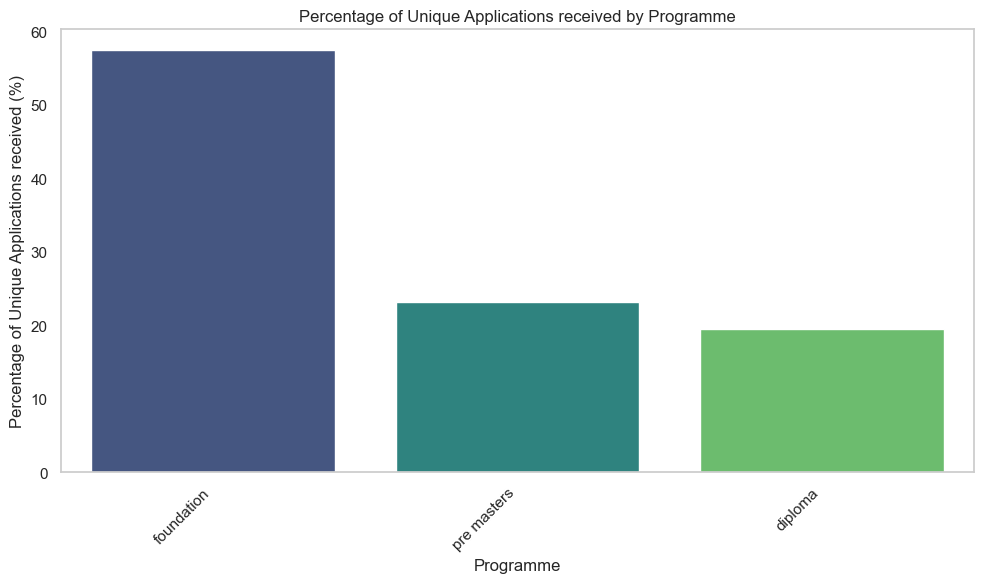

In [628]:
# Create visualisation for Total unique applications by programme in percentages.
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for 
plt.figure(figsize=(10, 6))
sns.barplot(x=unique_applications_percentage_by_programme_sorted.index, 
            y=unique_applications_percentage_by_programme_sorted.values, 
            palette='viridis', hue=unique_applications_percentage_by_programme_sorted.index, 
            legend=False)

# Add labels and title
plt.xlabel('Programme')
plt.ylabel('Percentage of Unique Applications received (%)')
plt.title('Percentage of Unique Applications received by Programme')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove grid
plt.grid(False)

# Save the plot to a file
plt.savefig("Percentage of Unique Applications received by Programme.png")

# Show the plot
plt.tight_layout()
plt.show()

# 4. Offer analysis

In [630]:
import pandas as pd

# View the DataFrame
print(sgdata_copy.head())
print(sgdata_copy.info())

    centre programme          area     region sub_region agent_location  \
0  cardiff   diploma  anz & n asia        anz  australia      aus - vic   
1  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
2  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
3  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
4  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   

  branch_urn group_urn             lead_source  student_id  ...  \
0     a31552    a31552  standard agent booking     2864317  ...   
1     a15382    a29520  standard agent booking     2853769  ...   
2     a15382    a29520  standard agent booking     2863293  ...   
3      a7608     a7608  standard agent booking     2854643  ...   
4      d1107     d1107  standard agent booking     2871048  ...   

   confirmation_date   arrived_date cancellation_date  completed progressed  \
0      not specified  not specified        10/05/2023         no   

In [632]:
# Check for datatypes
print(sgdata_copy['offered_date'].dtypes)

object


In [634]:
# Show the unique values in the 'offered_date' column
unique_offered_dates = sgdata_copy['offered_date'].unique()

print(unique_offered_dates)

['not specified' '21/11/2023' '29/11/2023' '06/12/2023' '18/11/2023'
 '19/09/2023' '24/11/2023' '12/09/2023' '14/06/2023' '05/09/2023'
 '13/09/2023' '11/10/2023' '31/01/2024' '24/10/2023' '30/08/2023'
 '04/08/2023' '20/10/2023' '18/09/2023' '07/11/2023' '09/11/2023'
 '21/10/2023' '06/09/2023' '24/08/2023' '14/05/2024' '12/08/2023'
 '27/10/2023' '15/07/2023' '19/07/2023' '28/10/2023' '06/01/2024'
 '03/11/2023' '17/10/2023' '15/08/2023' '23/05/2024' '21/12/2022'
 '02/11/2023' '04/06/2024' '14/09/2023' '16/05/2023' '18/10/2023'
 '23/01/2024' '27/09/2023' '28/09/2023' '12/10/2023' '21/09/2023'
 '22/09/2023' '20/12/2023' '23/11/2023' '29/09/2023' '29/08/2023'
 '14/12/2023' '08/10/2023' '12/11/2023' '16/11/2023' '26/09/2023'
 '07/09/2023' '13/10/2023' '16/09/2023' '21/06/2023' '23/12/2023'
 '09/12/2023' '03/10/2023' '12/07/2023' '23/09/2023' '15/09/2023'
 '04/11/2023' '08/07/2023' '02/05/2023' '15/12/2023' '22/02/2024'
 '22/11/2023' '16/12/2023' '17/05/2024' '05/04/2024' '05/12/2023'
 '17/05

**How many applications received an offer to study at StudyGroup?**

In [636]:
# Count applications that received an offer (excluding 'not specified')
applications_with_offer = sgdata_copy[sgdata_copy['offered_date'] != 'not specified'].shape[0]

# Count applications that did not receive an offer (where 'offered_date' is 'not specified')
applications_without_offer = sgdata_copy[sgdata_copy['offered_date'] == 'not specified'].shape[0]

# Calculate the total number of applications
total_applications = applications_with_offer + applications_without_offer

# Display the results
print(f"Applications that received an offer: {applications_with_offer}")
print(f"Applications that did not receive an offer: {applications_without_offer}")
print(f"Total number of applications: {total_applications}")

Applications that received an offer: 51892
Applications that did not receive an offer: 19862
Total number of applications: 71754


In [638]:
# Calculate the percentage of applications that received an offer.
# Total number of applications
total_applications = sgdata_copy.shape[0]

# Count applications that received an offer (excluding 'not specified')
applications_with_offer = sgdata_copy[sgdata_copy['offered_date'] != 'not specified'].shape[0]

# Count applications that did not receive an offer (where 'offered_date' is 'not specified')
applications_without_offer = sgdata_copy[sgdata_copy['offered_date'] == 'not specified'].shape[0]

# Calculate percentages
percentage_with_offer = (applications_with_offer / total_applications) * 100
percentage_without_offer = (applications_without_offer / total_applications) * 100

# Print the results in percentages
print(f"Applications that received an offer: {percentage_with_offer:.2f}%")
print(f"Applications that did not receive an offer: {percentage_without_offer:.2f}%")

Applications that received an offer: 72.32%
Applications that did not receive an offer: 27.68%


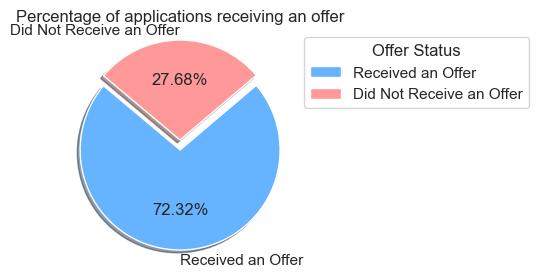

In [640]:
# Create visualisation to show the percentages of appications that received an offer.
import matplotlib.pyplot as plt

# Pie chart visualization
labels = ['Received an Offer', 'Did Not Receive an Offer']
sizes = [percentage_with_offer, percentage_without_offer]
colors = ['#66b3ff', '#ff9999']
explode = (0.1, 0)  # explode the first slice (Received an Offer)

# Adjust the figure size to make the pie chart smaller
plt.figure(figsize=(3, 3))  # Reduce the size of the chart

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.2f%%', shadow=True, startangle=140)

# Add the legend
plt.legend(labels, title="Offer Status", loc="upper left", bbox_to_anchor=(1, 1))

# Title and axis settings
plt.title('Percentage of applications receiving an offer')
plt.axis('equal')  

# Show the output
plt.show()

**How many unique applications received an offer to study at StudyGroup?**

In [642]:
# Ensure no missing student_id or offered_date and drop duplicates for student_id
sgdata_cleaned = sgdata_copy.dropna(subset=['student_id', 'offered_date']).drop_duplicates(subset='student_id')

# Total number of unique applicants
total_unique_applicants = sgdata_cleaned['student_id'].nunique()

# Count unique applicants who received an offer (excluding 'not specified' in 'offered_date')
unique_applicants_with_offer = sgdata_cleaned[sgdata_cleaned['offered_date'] != 'not specified']['student_id'].nunique()

# Count unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
unique_applicants_without_offer = sgdata_cleaned[sgdata_cleaned['offered_date'] == 'not specified']['student_id'].nunique()

# view the output
print(f"Total unique applicants: {total_unique_applicants}")
print(f"Unique applicants who received an offer: {unique_applicants_with_offer}")
print(f"Unique applicants who did not receive an offer: {unique_applicants_without_offer}")

Total unique applicants: 37238
Unique applicants who received an offer: 27202
Unique applicants who did not receive an offer: 10036


In [644]:
# Calculate the percentage of unique applicants that received an offer.
# Ensure no missing student_id or offered_date and drop duplicates for student_id
sgdata_cleaned = sgdata_copy.dropna(subset=['student_id', 'offered_date']).drop_duplicates(subset='student_id')

# Total number of unique applicants
total_unique_applicants = sgdata_cleaned['student_id'].nunique()

# Count unique applicants who received an offer (excluding 'not specified' in 'offered_date')
unique_applicants_with_offer = sgdata_cleaned[sgdata_cleaned['offered_date'] != 'not specified']['student_id'].nunique()

# Count unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
unique_applicants_without_offer = sgdata_cleaned[sgdata_cleaned['offered_date'] == 'not specified']['student_id'].nunique()

# Calculate percentages
percent_with_offer = (unique_applicants_with_offer / total_unique_applicants) * 100
percent_without_offer = (unique_applicants_without_offer / total_unique_applicants) * 100

# View the output as percentages
print(f"Total unique applicants: {total_unique_applicants}")
print(f"Unique applicants who received an offer: {unique_applicants_with_offer} ({percent_with_offer:.2f}%)")
print(f"Unique applicants who did not receive an offer: {unique_applicants_without_offer} ({percent_without_offer:.2f}%)")

Total unique applicants: 37238
Unique applicants who received an offer: 27202 (73.05%)
Unique applicants who did not receive an offer: 10036 (26.95%)


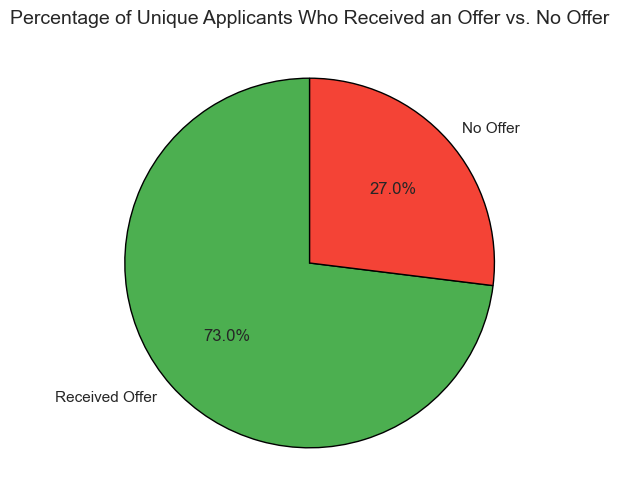

In [119]:
# Create a visualisation for percentage of unique applicants who received and did not receive an offer.
import matplotlib.pyplot as plt

# Data for pie chart
labels = ['Received Offer', 'No Offer']
values = [percent_with_offer, percent_without_offer]
colors = ['#4CAF50', '#F44336']

# Create a pie chart
plt.figure(figsize=(8, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})

# Add a title
plt.title('Percentage of Unique Applicants Who Received an Offer vs. No Offer', fontsize=14)

# Display the plot
plt.show()

**How many unique offers were sent by StudyGroup by area?**

In [646]:
# Show the distribution of unique applicant by area
# Ensure the data is clean and 'area' and 'student_id' columns are available
# Group by area and count the unique applicants (student_id) for each area
unique_applicants_by_area = sgdata_copy.drop_duplicates(subset='student_id') \
    .groupby('area')['student_id'] \
    .nunique()

# Calculate the total number of unique applicants
total_unique_applicants = sgdata_copy['student_id'].nunique()

# Print the results
print("Unique applicants by area:")
print(unique_applicants_by_area)
print(f"\nTotal number of unique applicants: {total_unique_applicants}")

Unique applicants by area:
area
anz & n asia         1742
china                7520
elmea & pakistan    12132
se asia              1160
south asia           5576
uk eu & americas     9108
Name: student_id, dtype: int64

Total number of unique applicants: 37238


In [648]:
# Unique applicants who received and did not receive an offer by Area
# Drop duplicates based on 'student_id' to count each student only once
unique_applicants_by_area = sgdata_copy.drop_duplicates(subset='student_id')

# Create two dataframes: one for applicants who received an offer and one for those who didn't
applicants_with_offer = unique_applicants_by_area[unique_applicants_by_area['offered_date'] != 'not specified']
applicants_without_offer = unique_applicants_by_area[unique_applicants_by_area['offered_date'] == 'not specified']

# Count the unique applicants with and without an offer by area
unique_applicants_with_offer_by_area = applicants_with_offer.groupby('area')['student_id'].nunique()
unique_applicants_without_offer_by_area = applicants_without_offer.groupby('area')['student_id'].nunique()

# Calculate total unique applicants by area
total_unique_applicants_by_area = unique_applicants_by_area.groupby('area')['student_id'].nunique()

# Print the results
print("Unique applicants who received an offer by area:")
print(unique_applicants_with_offer_by_area)

print("\nUnique applicants who did not receive an offer by area:")
print(unique_applicants_without_offer_by_area)

print(f"\nTotal number of unique applicants by area:")
print(total_unique_applicants_by_area)

Unique applicants who received an offer by area:
area
anz & n asia        1425
china               6566
elmea & pakistan    8514
se asia              950
south asia          3266
uk eu & americas    6481
Name: student_id, dtype: int64

Unique applicants who did not receive an offer by area:
area
anz & n asia         317
china                954
elmea & pakistan    3618
se asia              210
south asia          2310
uk eu & americas    2627
Name: student_id, dtype: int64

Total number of unique applicants by area:
area
anz & n asia         1742
china                7520
elmea & pakistan    12132
se asia              1160
south asia           5576
uk eu & americas     9108
Name: student_id, dtype: int64


In [650]:
# Percentage of unique applicants with and without an offer by Area.
# Drop duplicates based on 'student_id' to count each student only once
unique_applicants_by_area = sgdata_copy.drop_duplicates(subset='student_id')

# Create two dataframes: one for applicants who received an offer and one for those who didn't
applicants_with_offer = unique_applicants_by_area[unique_applicants_by_area['offered_date'] != 'not specified']
applicants_without_offer = unique_applicants_by_area[unique_applicants_by_area['offered_date'] == 'not specified']

# Count the unique applicants with and without an offer by area
unique_applicants_with_offer_by_area = applicants_with_offer.groupby('area')['student_id'].nunique()
unique_applicants_without_offer_by_area = applicants_without_offer.groupby('area')['student_id'].nunique()

# Calculate total unique applicants by area
total_unique_applicants_by_area = unique_applicants_by_area.groupby('area')['student_id'].nunique()

# Calculate the percentage of applicants who received an offer and those who did not by area
percentage_with_offer_by_area = (unique_applicants_with_offer_by_area / total_unique_applicants_by_area) * 100
percentage_without_offer_by_area = (unique_applicants_without_offer_by_area / total_unique_applicants_by_area) * 100

# Create a DataFrame for cleaner display
offer_status_df = pd.DataFrame({
    'Percentage with Offer': percentage_with_offer_by_area,
    'Percentage without Offer': percentage_without_offer_by_area
})

# Sort the DataFrame by 'Percentage with Offer' in descending order
sorted_offer_status_df = offer_status_df.sort_values(by='Percentage with Offer', ascending=False)

# Display the sorted result
print(sorted_offer_status_df)

                  Percentage with Offer  Percentage without Offer
area                                                             
china                         87.313830                 12.686170
se asia                       81.896552                 18.103448
anz & n asia                  81.802526                 18.197474
uk eu & americas              71.157224                 28.842776
elmea & pakistan              70.178042                 29.821958
south asia                    58.572453                 41.427547


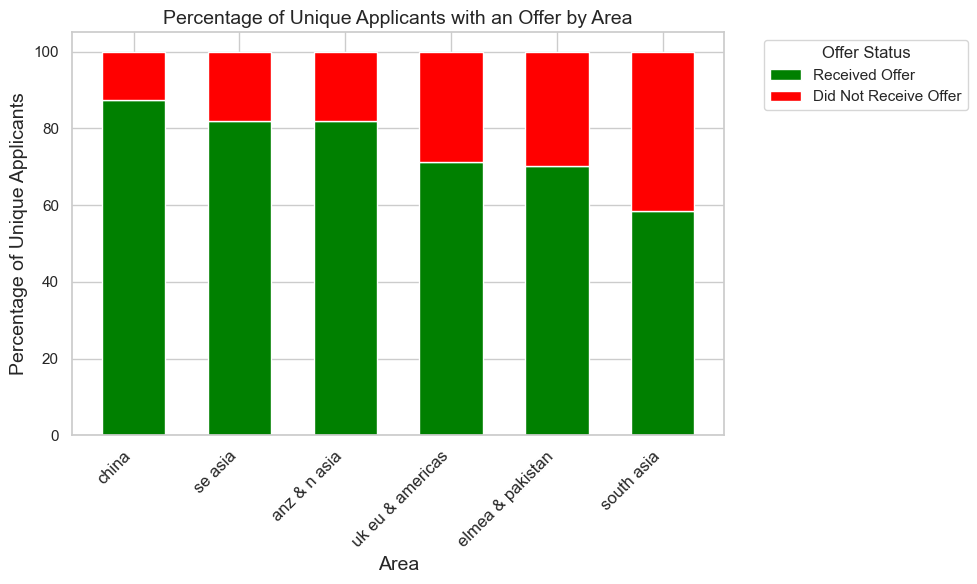

In [652]:
# Create visualisation to show the percentage of unique applicants with and without an offer by Area.
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we have the 'area' column for plotting and reset the index for proper display
sorted_offer_status_df = sorted_offer_status_df.reset_index()

# Plotting setup
fig, ax = plt.subplots(figsize=(10, 6))

# Loop through each area to create a stacked bar
bar_width = 0.6  # Width of the bars
x_pos = range(len(sorted_offer_status_df))

# Plot bars for 'Percentage with Offer'
ax.bar(x_pos, sorted_offer_status_df['Percentage with Offer'], bar_width, label='Received Offer', color='green')

# Plot bars for 'Percentage without Offer', stacked on top of the previous bars
ax.bar(x_pos, sorted_offer_status_df['Percentage without Offer'], bar_width,
       bottom=sorted_offer_status_df['Percentage with Offer'], label='Did Not Receive Offer', color='red')

# Add labels and title
ax.set_xlabel('Area', fontsize=14)
ax.set_ylabel('Percentage of Unique Applicants', fontsize=14)
ax.set_title('Percentage of Unique Applicants with an Offer by Area', fontsize=14)

# Set x-axis ticks with area names and rotate them for better readability
ax.set_xticks(x_pos)
ax.set_xticklabels(sorted_offer_status_df['area'], rotation=45, ha="right", fontsize=12)

# Add a legend to distinguish between 'Received Offer' and 'Did Not Receive Offer'
# Move the legend outside the chart
ax.legend(title='Offer Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Tight layout 
plt.tight_layout()

# Display the plot
plt.show()

In [654]:
# Show the distribution of unique applicants with an offer by Area in percentages.
# Drop duplicates based on 'student_id' to count each student only once
unique_applicants_by_area = sgdata_copy.drop_duplicates(subset='student_id')

# Filter applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants_by_area[unique_applicants_by_area['offered_date'] != 'not specified']

# Count the number of offers provided to each area
offers_by_area = applicants_with_offer.groupby('area')['student_id'].nunique()

# Calculate the total number of offers provided
total_offers = offers_by_area.sum()

# Calculate the percentage of offers given to each area based on total offers
percentage_offers_by_area = (offers_by_area / total_offers) * 100

# Create a DataFrame for cleaner display
offer_percentage_df = pd.DataFrame({
    'Total Offers by Area': offers_by_area,
    'Percentage of Total Offers': percentage_offers_by_area
})

# Sort the DataFrame by the percentage of offers in descending order
sorted_offer_percentage_df = offer_percentage_df.sort_values(by='Percentage of Total Offers', ascending=False)

# Display the sorted result
print(sorted_offer_percentage_df)

                  Total Offers by Area  Percentage of Total Offers
area                                                              
elmea & pakistan                  8514                   31.299169
china                             6566                   24.137931
uk eu & americas                  6481                   23.825454
south asia                        3266                   12.006470
anz & n asia                      1425                    5.238585
se asia                            950                    3.492390


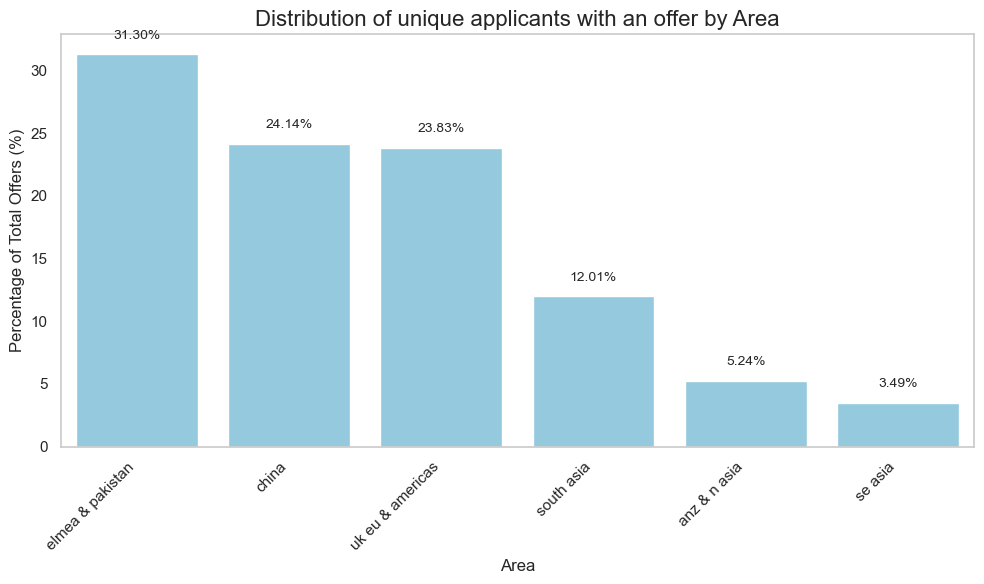

In [656]:
# Create a visualisation to display the distribution of unique applicants with an offer by Area.
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the data
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_offer_percentage_df.index, 
            y=sorted_offer_percentage_df['Percentage of Total Offers'], 
            color='skyblue')  # Color instead of palette to avoid the warning

# Add labels and title
plt.title('Distribution of unique applicants with an offer by Area', fontsize=16)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Percentage of Total Offers (%)', fontsize=12)

# Show the percentages on top of the bars
for index, value in enumerate(sorted_offer_percentage_df['Percentage of Total Offers']):
    plt.text(index, value + 1, f'{value:.2f}%', ha='center', va='bottom', fontsize=10)

# Remove gridlines
plt.grid(False)

# Show the plot
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**How many unique offers were sent by StudyGroup by region?**

In [658]:
# Show the distribution of unique applicants by region
# Group by region and count the unique applicants (student_id) for each region
unique_applicants_by_region = sgdata_copy.drop_duplicates(subset='student_id') \
    .groupby('region')['student_id'] \
    .nunique()

# Calculate the total number of unique applicants
total_unique_applicants = sgdata_copy['student_id'].nunique()

# Print the results
print("Unique applicants by region:")
print(unique_applicants_by_region)
print(f"\nTotal number of unique applicants: {total_unique_applicants}")

Unique applicants by region:
region
anz                             146
e c1 china                     2648
hong kong                       988
india                          4633
middle east                    4978
n c2 china                     2843
na & lam                        767
nigeria                         880
north asia                      608
pakistan                       4198
rest of africa                  432
rest of s asia                  943
russia, e europe, c asia        167
s europe, levant & n africa    1644
s w china                      2029
se asia 1                       372
se asia 2                       788
uk & w europe                  8174
Name: student_id, dtype: int64

Total number of unique applicants: 37238


In [660]:
# Unique applicants receiving and not receiving an offer by region
# Drop duplicates to consider each applicant only once
unique_applicants_by_region = sgdata_copy.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer
applicants_with_offer_by_region = unique_applicants_by_region[unique_applicants_by_region['offered_date'] != 'not specified'] \
    .groupby('region')['student_id'] \
    .nunique()

# Get the unique applicants who did not receive an offer
applicants_without_offer_by_region = unique_applicants_by_region[unique_applicants_by_region['offered_date'] == 'not specified'] \
    .groupby('region')['student_id'] \
    .nunique()

# Calculate the total unique applicants by region
total_unique_applicants_by_region = unique_applicants_by_region.groupby('region')['student_id'] \
    .nunique()

# Create a DataFrame to show the results
offer_status_by_region = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_by_region,
    'Applicants without Offer': applicants_without_offer_by_region,
    'Total Unique Applicants': total_unique_applicants_by_region
})

# Display the results
print("Unique applicants by region who received and did not receive an offer:")
print(offer_status_by_region)

Unique applicants by region who received and did not receive an offer:
                             Applicants with Offer  Applicants without Offer  \
region                                                                         
anz                                             96                        50   
e c1 china                                    2332                       316   
hong kong                                      826                       162   
india                                         2743                      1890   
middle east                                   3996                       982   
n c2 china                                    2459                       384   
na & lam                                       492                       275   
nigeria                                        423                       457   
north asia                                     503                       105   
pakistan                                      252

In [662]:
# Unique applicants with and without an offer by Region.
# Drop duplicates to consider each applicant only once
unique_applicants_by_region = sgdata_copy.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer
applicants_with_offer_by_region = unique_applicants_by_region[unique_applicants_by_region['offered_date'] != 'not specified'] \
    .groupby('region')['student_id'] \
    .nunique()

# Get the unique applicants who did not receive an offer
applicants_without_offer_by_region = unique_applicants_by_region[unique_applicants_by_region['offered_date'] == 'not specified'] \
    .groupby('region')['student_id'] \
    .nunique()

# Calculate the total unique applicants by region
total_unique_applicants_by_region = unique_applicants_by_region.groupby('region')['student_id'] \
    .nunique()

# Calculate the percentages
percentage_with_offer_by_region = (applicants_with_offer_by_region / total_unique_applicants_by_region) * 100
percentage_without_offer_by_region = (applicants_without_offer_by_region / total_unique_applicants_by_region) * 100

# Create a DataFrame to show the results in percentages
offer_status_percentage_by_region = pd.DataFrame({
    'Percentage with Offer': percentage_with_offer_by_region,
    'Percentage without Offer': percentage_without_offer_by_region,
    'Total Unique Applicants': total_unique_applicants_by_region
})

# Sort the DataFrame by 'Percentage with Offer' in descending order
sorted_offer_status_percentage_by_region = offer_status_percentage_by_region.sort_values(by='Percentage with Offer', ascending=False)

# Display the results
print("Unique applicants by region who received and did not receive an offer (in percentages) sorted:")
print(sorted_offer_status_percentage_by_region)

Unique applicants by region who received and did not receive an offer (in percentages) sorted:
                             Percentage with Offer  Percentage without Offer  \
region                                                                         
e c1 china                               88.066465                 11.933535   
s w china                                87.481518                 12.518482   
n c2 china                               86.493141                 13.506859   
hong kong                                83.603239                 16.396761   
se asia 1                                83.602151                 16.397849   
north asia                               82.730263                 17.269737   
russia, e europe, c asia                 82.035928                 17.964072   
se asia 2                                81.091371                 18.908629   
middle east                              80.273202                 19.726798   
s europe, levant & n afri

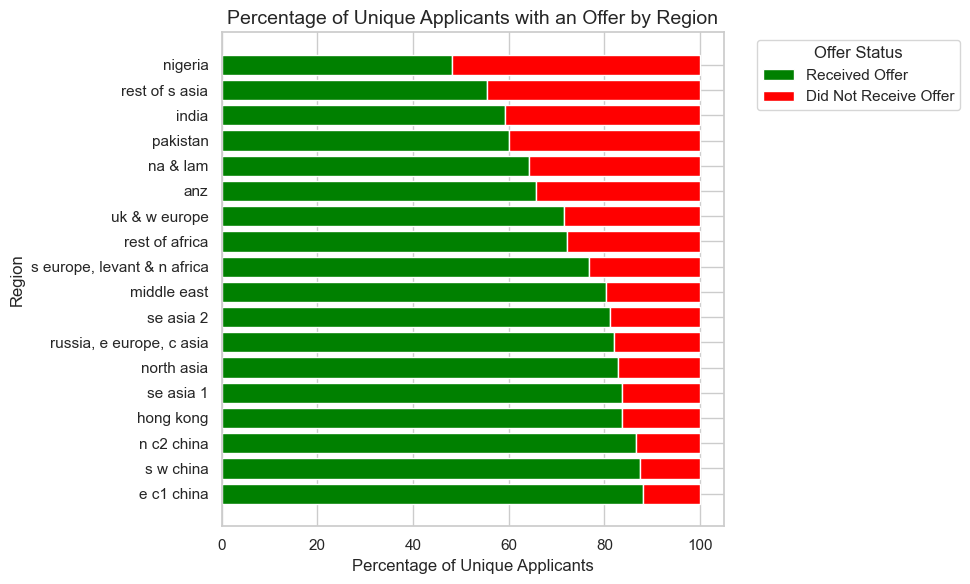

In [664]:
# Create visualisation to display the percentage of unique applicants with and without an offer by Region.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting setup
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for 'Percentage with Offer'
ax.barh(sorted_offer_status_percentage_by_region.index,
        sorted_offer_status_percentage_by_region['Percentage with Offer'],
        label='Received Offer', color='green')

# Plot bars for 'Percentage without Offer', stacked on top of the previous bars
ax.barh(sorted_offer_status_percentage_by_region.index,
        sorted_offer_status_percentage_by_region['Percentage without Offer'],
        left=sorted_offer_status_percentage_by_region['Percentage with Offer'],
        label='Did Not Receive Offer', color='red')

# Add labels and title
ax.set_xlabel('Percentage of Unique Applicants', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.set_title('Percentage of Unique Applicants with an Offer by Region', fontsize=14)

# Add a legend to distinguish between 'Received Offer' and 'Did Not Receive Offer'
ax.legend(title='Offer Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Tight layout to ensure no clipping
plt.tight_layout()

# Display the plot
plt.show()

In [666]:
# Distribution of unique applicants with an offer by Region. 
# Ensure no missing student_id, offered_date, and region, and drop duplicates for student_id
sgdata_cleaned = sgdata_copy.dropna(subset=['student_id', 'offered_date', 'region']).drop_duplicates(subset='student_id')

# Filter data to only include applicants who received an offer
applicants_with_offer = sgdata_cleaned[sgdata_cleaned['offered_date'] != 'not specified']

# Count unique applicants by region who received an offer
region_counts = applicants_with_offer['region'].value_counts()

# Calculate percentages for each region
region_percentages = (region_counts / region_counts.sum()) * 100

# Print the region percentages
print("Percentage distribution of unique applicants by region with an offer:")
print(region_percentages)

Percentage distribution of unique applicants by region with an offer:
region
uk & w europe                  21.513124
middle east                    14.690096
india                          10.083817
pakistan                        9.271377
n c2 china                      9.039776
e c1 china                      8.572899
s w china                       6.525255
s europe, levant & n africa     4.635689
hong kong                       3.036541
se asia 2                       2.349092
rest of s asia                  1.922653
north asia                      1.849129
na & lam                        1.808691
nigeria                         1.555033
rest of africa                  1.146974
se asia 1                       1.143298
russia, e europe, c asia        0.503639
anz                             0.352915
Name: count, dtype: float64


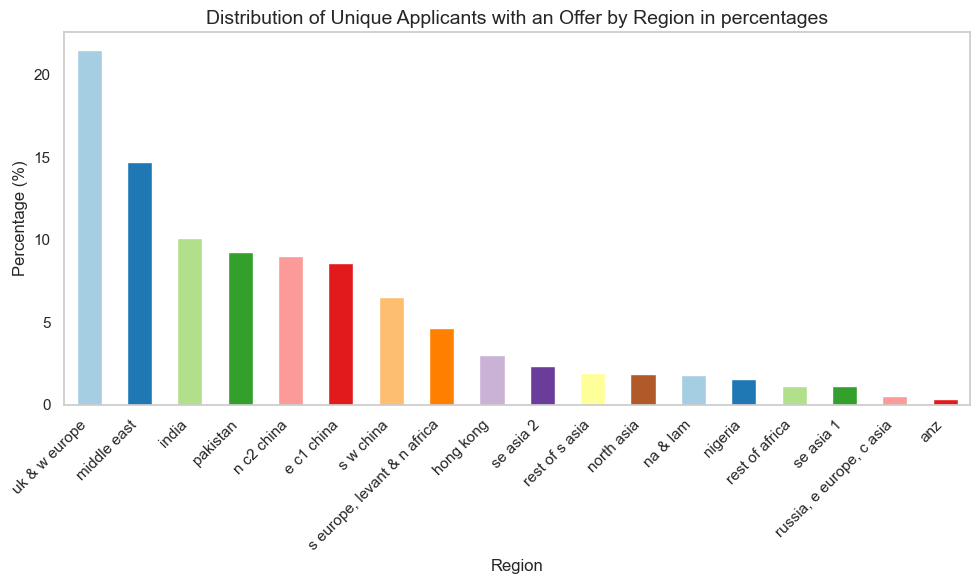

In [670]:
# Create visualisation to display the distribution of unique applicants with an offer by region in Percentages.
import matplotlib.pyplot as plt

# Ensure no missing student_id, offered_date, and region, and drop duplicates
sgdata_cleaned = sgdata_copy.dropna(subset=['student_id', 'offered_date', 'region']) \
                            .drop_duplicates(subset='student_id')

# Filter data to only include applicants who received an offer
applicants_with_offer = sgdata_cleaned[sgdata_cleaned['offered_date'] != 'not specified']

# Count unique applicants by region who received an offer
region_counts = applicants_with_offer['region'].value_counts()

# Calculate percentages for each region
region_percentages = (region_counts / region_counts.sum()) * 100

# Plotting the bar chart
plt.figure(figsize=(10, 6))
region_percentages.plot(kind='bar', color=plt.cm.Paired.colors)

# Add labels and title
plt.title('Distribution of Unique Applicants with an Offer by Region in percentages',
          fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Rotate x-axis labels and align them
plt.xticks(rotation=45, ha='right')

# Remove grid
plt.grid(False)

# Display the plot
plt.tight_layout()
plt.show()

**How many unique offers were sent by StudyGroup by sub-region?**

In [672]:
# Show the number of unique applicants with and without an offer by Sub-Region.
# Drop duplicates to consider each applicant only once
unique_applicants = sgdata_copy.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']
applicants_with_offer_count = applicants_with_offer.groupby('sub_region')['student_id'].nunique()

# Get the unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
applicants_without_offer = unique_applicants[unique_applicants['offered_date'] == 'not specified']
applicants_without_offer_count = applicants_without_offer.groupby('sub_region')['student_id'].nunique()

# Merge the counts of applicants who received and did not receive an offer
offer_status_by_sub_region = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_count,
    'Applicants without Offer': applicants_without_offer_count
}).fillna(0)

# Sort the data by the count of applicants with an offer in descending order
sorted_offer_status_by_sub_region = offer_status_by_sub_region.sort_values(by='Applicants with Offer', ascending=False)

# Print the sorted results in count
print(f"\nUnique applicants by sub-region who received and did not receive an offer (in counts):")
print(sorted_offer_status_by_sub_region)


Unique applicants by sub-region who received and did not receive an offer (in counts):
                         Applicants with Offer  Applicants without Offer
sub_region                                                              
uk & w europe                             5852                    2322.0
india                                     2743                    1890.0
pakistan                                  2522                    1676.0
n china                                   2099                     338.0
e china                                   1799                     260.0
kuwait, bahrain & qatar                   1787                     513.0
saudi arabia                              1304                     224.0
s china                                   1282                     181.0
hong kong                                  826                     162.0
n africa                                   796                     236.0
uae, iran & iraq                    

In [674]:
# Show the percentage of unique applicants with and without an offer by Sub-Region.
# Drop duplicates to consider each applicant only once
unique_applicants = sgdata_copy.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']
applicants_with_offer_count = applicants_with_offer.groupby('sub_region')['student_id'].nunique()

# Get the unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
applicants_without_offer = unique_applicants[unique_applicants['offered_date'] == 'not specified']
applicants_without_offer_count = applicants_without_offer.groupby('sub_region')['student_id'].nunique()

# Merge the counts of applicants who received and did not receive an offer
offer_status_by_sub_region = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_count,
    'Applicants without Offer': applicants_without_offer_count
}).fillna(0)

# Calculate the total unique applicants per sub-region
total_unique_applicants_by_sub_region = unique_applicants.groupby('sub_region')['student_id'].nunique()

# Calculate the percentages for applicants with and without an offer
offer_status_by_sub_region['Percentage with Offer'] = (offer_status_by_sub_region['Applicants with Offer'] / 
                                                       total_unique_applicants_by_sub_region) * 100
offer_status_by_sub_region['Percentage without Offer'] = (offer_status_by_sub_region['Applicants without Offer'] / 
                                                          total_unique_applicants_by_sub_region) * 100

# Sort the data by the percentage of applicants with an offer in descending order
sorted_offer_status_by_sub_region = offer_status_by_sub_region.sort_values(by='Percentage with Offer', ascending=False)

# Print the results in percentages
print(f"\nUnique applicants by sub-region who received and did not receive an offer (in percentages):")
print(sorted_offer_status_by_sub_region[['Percentage with Offer', 'Percentage without Offer']])


Unique applicants by sub-region who received and did not receive an offer (in percentages):
                         Percentage with Offer  Percentage without Offer
sub_region                                                              
new zealand                         100.000000                  0.000000
japan                                90.551181                  9.448819
c china 1                            90.492360                  9.507640
indonesia                            90.291262                  9.708738
oman                                 88.858696                 11.141304
c china 2                            88.669951                 11.330049
s china                              87.628161                 12.371839
e china                              87.372511                 12.627489
w china                              87.102473                 12.897527
n china                              86.130488                 13.869512
taiwan                         

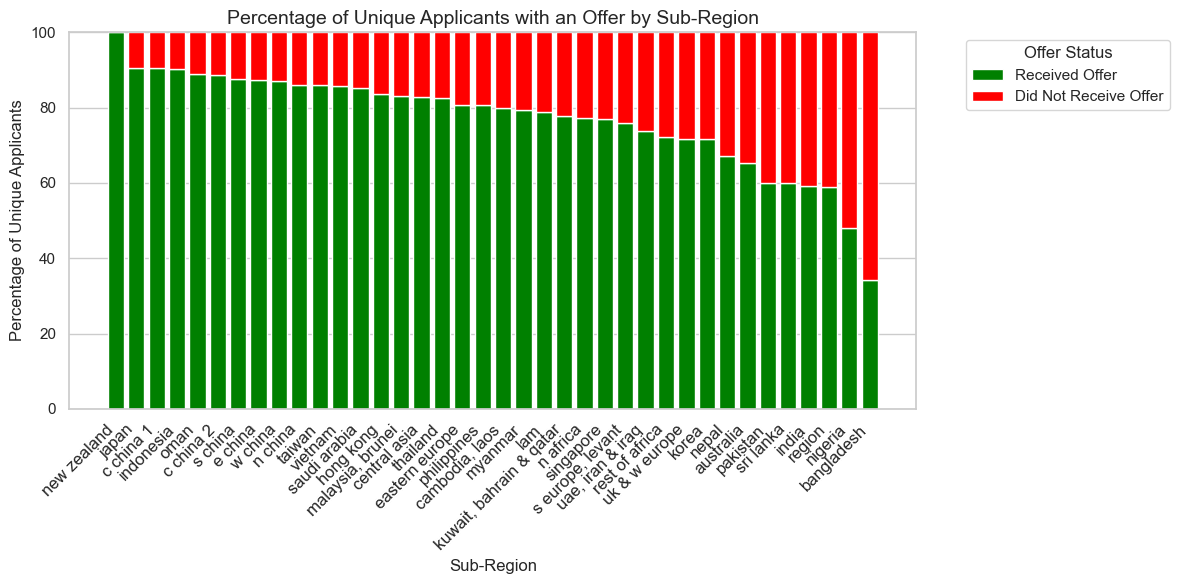

In [676]:
# Create a visualisation to display the percentage of unique applicants with and without an offer by Sub-Region.
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting setup
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for 'Percentage with Offer'
ax.bar(sorted_offer_status_by_sub_region.index, sorted_offer_status_by_sub_region['Percentage with Offer'], label='Received Offer', color='green')

# Plot bars for 'Percentage without Offer', stacked on top of the previous bars
ax.bar(sorted_offer_status_by_sub_region.index, sorted_offer_status_by_sub_region['Percentage without Offer'], 
       bottom=sorted_offer_status_by_sub_region['Percentage with Offer'], label='Did Not Receive Offer', color='red')

# Add labels and title
ax.set_xlabel('Sub-Region', fontsize=12)
ax.set_ylabel('Percentage of Unique Applicants', fontsize=12)
ax.set_title('Percentage of Unique Applicants with an Offer by Sub-Region', fontsize=14)

# Set the x-ticks explicitly to match the number of sub-regions
ax.set_xticks(range(len(sorted_offer_status_by_sub_region)))
ax.set_xticklabels(sorted_offer_status_by_sub_region.index, rotation=45, ha="right", fontsize=12)

# Add a legend to distinguish between 'Received Offer' and 'Did Not Receive Offer'
ax.legend(title='Offer Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust the layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

In [678]:
# Show the distribution of unique applicants with an offer by Sub-Region in Percentages.
# Ensure no missing student_id, offered_date, and sub_region, and drop duplicates
sgdata_cleaned = sgdata_copy.dropna(subset=['student_id', 'offered_date', 'sub_region']) \
                            .drop_duplicates(subset='student_id')

# Filter data to only include applicants who received an offer
applicants_with_offer = sgdata_cleaned[sgdata_cleaned['offered_date'] != 'not specified']

# Count unique applicants by sub-region who received an offer
sub_region_counts = applicants_with_offer['sub_region'].value_counts()

# Calculate percentages for each sub-region
sub_region_percentages = (sub_region_counts / sub_region_counts.sum()) * 100

# Get the top 10 sub-regions
top_10_sub_regions = sub_region_percentages.head(10)

# Print the top 10 sub-regions
print("Top 10 sub-regions with the highest percentage of unique applicants with an offer:")
print(top_10_sub_regions)

Top 10 sub-regions with the highest percentage of unique applicants with an offer:
sub_region
uk & w europe              21.513124
india                      10.083817
pakistan                    9.271377
n china                     7.716344
e china                     6.613484
kuwait, bahrain & qatar     6.569370
saudi arabia                4.793765
s china                     4.712889
hong kong                   3.036541
n africa                    2.926255
Name: count, dtype: float64


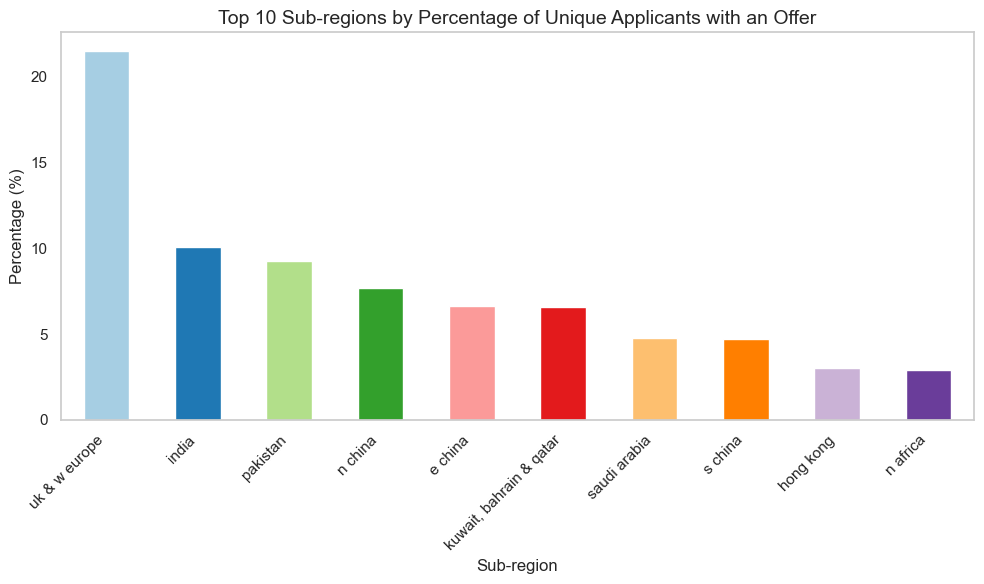

In [680]:
# Create visualisation to display the distribution of unique applicants with an offer by Sub-Region in Percentages.
import matplotlib.pyplot as plt

# Plotting the bar chart for top 10 sub-regions
plt.figure(figsize=(10, 6))
top_10_sub_regions.plot(kind='bar', color=plt.cm.Paired.colors)

# Add labels and title
plt.title('Top 10 Sub-regions by Percentage of Unique Applicants with an Offer',
          fontsize=14)
plt.xlabel('Sub-region', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Rotate x-axis labels and align them
plt.xticks(rotation=45, ha='right')

# Remove grid
plt.grid(False)

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the plot
plt.show()

**How many unique offers were sent by StudyGroup by nationality?**

In [682]:
# Calculate the number of unique applicants who received and did not receive an offer by Nationality.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']
applicants_with_offer_count = applicants_with_offer.groupby('nationality')['student_id'].nunique()

# Get the unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
applicants_without_offer = unique_applicants[unique_applicants['offered_date'] == 'not specified']
applicants_without_offer_count = applicants_without_offer.groupby('nationality')['student_id'].nunique()

# Merge the counts of applicants who received and did not receive an offer
offer_status_by_nationality = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_count,
    'Applicants without Offer': applicants_without_offer_count
}).fillna(0)

# Convert counts to integers to remove the '.0'
offer_status_by_nationality = offer_status_by_nationality.astype(int)

# Sort the results based on the number of applicants with an offer
sorted_offer_status_by_nationality = offer_status_by_nationality.sort_values(by='Applicants with Offer', ascending=False)

# Get the top 30 nationalities with the highest number of applicants who received an offer
top_30_offer_status_by_nationality = sorted_offer_status_by_nationality.head(30)

# Print the results
print("Unique applicants by nationality who received and did not receive an offer, Top 30:")
print(top_30_offer_status_by_nationality)

Unique applicants by nationality who received and did not receive an offer, Top 30:
                   Applicants with Offer  Applicants without Offer
nationality                                                       
chinese                             7030                      1123
saudi                               3302                       676
pakistani                           3301                      2284
indian                              2814                      1903
kuwaiti                             1789                       532
egyptian                            1112                       376
qatari                               800                       211
hong kong chinese                    778                       144
nigerian                             623                       757
omani                                356                        50
emirati                              334                        73
moroccan                             284     

In [684]:
# Calculate the percentages of unique applicants who received and did not receive an offer by Nationality.
# Only show in results nationality with more than 100 counts.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']
applicants_with_offer_count = applicants_with_offer.groupby('nationality')['student_id'].nunique()

# Get the unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
applicants_without_offer = unique_applicants[unique_applicants['offered_date'] == 'not specified']
applicants_without_offer_count = applicants_without_offer.groupby('nationality')['student_id'].nunique()

# Merge the counts of applicants who received and did not receive an offer
offer_status_by_nationality = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_count,
    'Applicants without Offer': applicants_without_offer_count
}).fillna(0)

# Convert counts to integers to remove the '.0'
offer_status_by_nationality = offer_status_by_nationality.astype(int)

# Calculate the total number of applicants per nationality
total_applicants_by_nationality = offer_status_by_nationality['Applicants with Offer'] + offer_status_by_nationality['Applicants without Offer']

# Calculate the percentages for applicants with and without an offer
offer_status_by_nationality['Percentage with Offer'] = (offer_status_by_nationality['Applicants with Offer'] / 
                                                        total_applicants_by_nationality) * 100
offer_status_by_nationality['Percentage without Offer'] = (offer_status_by_nationality['Applicants without Offer'] / 
                                                           total_applicants_by_nationality) * 100

# Filter nationalities with more than 100 applicants
offer_status_by_nationality_filtered = offer_status_by_nationality[total_applicants_by_nationality > 100]

# Sort the results based on the percentage of applicants with an offer
sorted_offer_status_by_nationality = offer_status_by_nationality_filtered.sort_values(by='Percentage with Offer', ascending=False)

# Get the top 30 nationalities with the highest percentage of applicants who received an offer
top_30_offer_status_by_nationality = sorted_offer_status_by_nationality.head(30)

# Print the results in percentages
print("Unique applicants by nationality who received and did not receive an offer in percentages, Top 30 (more than 100 applicants):")
print(top_30_offer_status_by_nationality[['Percentage with Offer', 'Percentage without Offer']])

Unique applicants by nationality who received and did not receive an offer in percentages, Top 30 (more than 100 applicants):
                   Percentage with Offer  Percentage without Offer
nationality                                                       
japanese                       92.500000                  7.500000
indonesian                     89.473684                 10.526316
omani                          87.684729                 12.315271
vietnamese                     86.805556                 13.194444
chinese                        86.225929                 13.774071
taiwanese                      84.967320                 15.032680
hong kong chinese              84.381779                 15.618221
turkish                        84.302326                 15.697674
saudi                          83.006536                 16.993464
malaysian                      82.795699                 17.204301
thai                           82.692308                 17.307692
emi

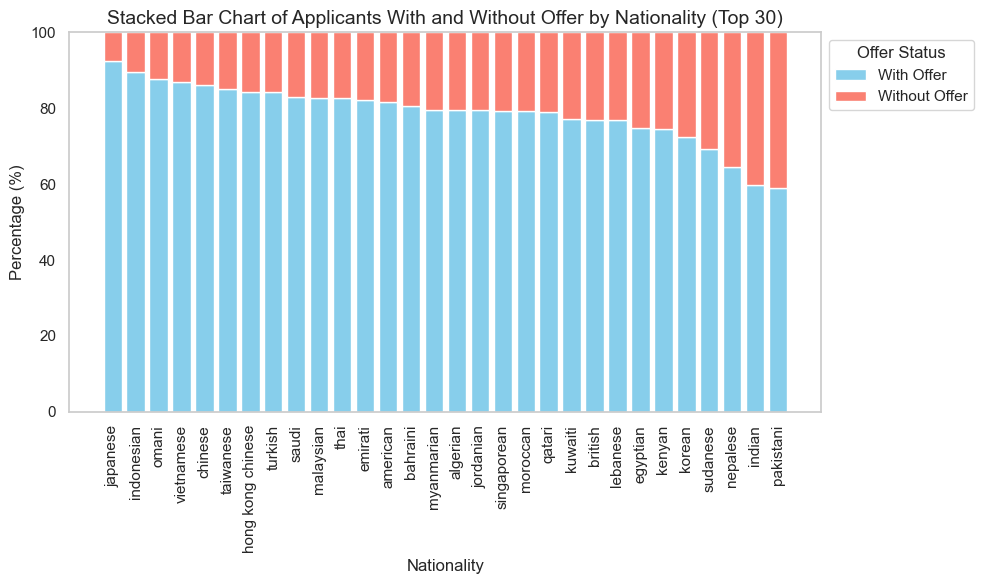

In [686]:
# Create visualisation to show the top 30 nationalities who received and did not receive an offer 
# with more than 100 applicants in count.
import matplotlib.pyplot as plt
import seaborn as sns

# Data for the filtered top 30 nationalities with more than 100 applicants
top_30_offer_status_by_nationality = sorted_offer_status_by_nationality.head(30)

# Set up the plot size
plt.figure(figsize=(10, 6))

# Plot the "With Offer" bars first (bottom of the stack)
plt.bar(top_30_offer_status_by_nationality.index, 
        top_30_offer_status_by_nationality['Percentage with Offer'], 
        color='skyblue', label='With Offer')

# Plot the "Without Offer" bars on top (stacked)
plt.bar(top_30_offer_status_by_nationality.index, 
        top_30_offer_status_by_nationality['Percentage without Offer'], 
        color='salmon', label='Without Offer', 
        bottom=top_30_offer_status_by_nationality['Percentage with Offer'])

# Customize the plot
plt.xticks(rotation=90)  # Rotate the x-axis labels to avoid overlap
plt.xlabel('Nationality', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.title('Stacked Bar Chart of Applicants With and Without Offer by Nationality (Top 30)', fontsize=14)

# Ensure the y-axis is scaled from 0 to 100
plt.ylim(0, 100)

# Remove the grid
plt.grid(False)

# Add a legend outside the chart
plt.legend(title='Offer Status', loc='upper left', bbox_to_anchor=(1, 1))

# Display the plot
plt.tight_layout()  
plt.show()

**How is the distribution of offer by Nationality?**

In [688]:
# Show the distribution of unique applicants with an offer by Nationality.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']
applicants_with_offer_count = applicants_with_offer.groupby('nationality')['student_id'].nunique()

# Get the unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
applicants_without_offer = unique_applicants[unique_applicants['offered_date'] == 'not specified']
applicants_without_offer_count = applicants_without_offer.groupby('nationality')['student_id'].nunique()

# Merge the counts of applicants who received and did not receive an offer
offer_status_by_nationality = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_count,
    'Applicants without Offer': applicants_without_offer_count
}).fillna(0)

# Convert counts to integers to remove the '.0'
offer_status_by_nationality = offer_status_by_nationality.astype(int)

# Calculate the total number of offers
total_offers = offer_status_by_nationality['Applicants with Offer'].sum()

# Calculate the percentage of offers by nationality
offer_status_by_nationality['Percentage of Total Offers'] = (offer_status_by_nationality['Applicants with Offer'] / total_offers) * 100

# Sort the results based on the number of applicants with an offer
sorted_offer_status_by_nationality = offer_status_by_nationality.sort_values(by='Applicants with Offer', ascending=False)

# Get the top 30 nationalities with the highest number of applicants who received an offer
top_30_offer_status_by_nationality = sorted_offer_status_by_nationality.head(30)

# Print the results
print("Top 30 Nationalities with the Distribution of Offers:")
print(top_30_offer_status_by_nationality[['Applicants with Offer', 'Percentage of Total Offers']])

Top 30 Nationalities with the Distribution of Offers:
                   Applicants with Offer  Percentage of Total Offers
nationality                                                         
chinese                             7030                   25.843688
saudi                               3302                   12.138813
pakistani                           3301                   12.135137
indian                              2814                   10.344828
kuwaiti                             1789                    6.576722
egyptian                            1112                    4.087935
qatari                               800                    2.940960
hong kong chinese                    778                    2.860084
nigerian                             623                    2.290273
omani                                356                    1.308727
emirati                              334                    1.227851
moroccan                             284         

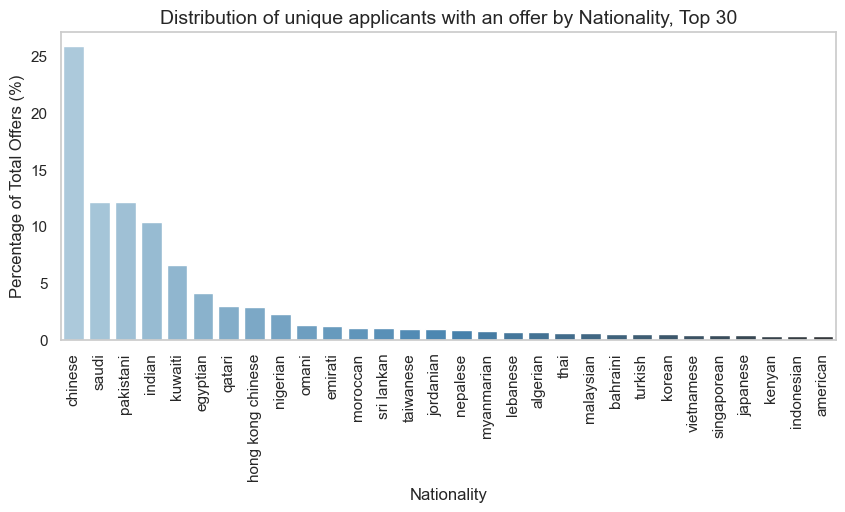

In [690]:
# Create visualisation to show the distribution of unique applicants with an offer by Nationality.
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot 
plt.figure(figsize=(10, 4))

# Adjusting the barplot to display vertical bars and avoid FutureWarning
sns.barplot(x=top_30_offer_status_by_nationality.index,
            y=top_30_offer_status_by_nationality['Percentage of Total Offers'],
            palette='Blues_d', hue=top_30_offer_status_by_nationality.index, legend=False)

# Set the labels and title
plt.title('Distribution of unique applicants with an offer by Nationality, Top 30', fontsize=14)
plt.ylabel('Percentage of Total Offers (%)', fontsize=12)
plt.xlabel('Nationality', fontsize=12)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)

# Remove gridlines
plt.grid(False)

# Show the plot
plt.show()

**How many unique offers were sent by StudyGroup receieved from lead_source?**

In [692]:
# Show the unique applicants with an offer and without an offer by Lead source.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']
applicants_with_offer_count = applicants_with_offer.groupby('lead_source')['student_id'].nunique()

# Get the unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
applicants_without_offer = unique_applicants[unique_applicants['offered_date'] == 'not specified']
applicants_without_offer_count = applicants_without_offer.groupby('lead_source')['student_id'].nunique()

# Merge the counts of applicants who received and did not receive an offer
offer_status_by_lead_source = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_count,
    'Applicants without Offer': applicants_without_offer_count
}).fillna(0)

# Convert counts to integers to remove the '.0'
offer_status_by_lead_source = offer_status_by_lead_source.astype(int)

# Sort the results based on the number of applicants with an offer
sorted_offer_status_by_lead_source = offer_status_by_lead_source.sort_values(by='Applicants with Offer', ascending=False)

# Print the results for all lead sources
print("Unique applicants by lead_source who received and did not receive an offer (sorted):")
print(sorted_offer_status_by_lead_source)

Unique applicants by lead_source who received and did not receive an offer (sorted):
                        Applicants with Offer  Applicants without Offer
lead_source                                                            
standard agent booking                  21332                      8682
sponsor                                  5813                      1347
apd                                        57                         7


In [694]:
# Show the percentages of unique applicants with and without an offer by Lead Source.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']
applicants_with_offer_count = applicants_with_offer.groupby('lead_source')['student_id'].nunique()

# Get the unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
applicants_without_offer = unique_applicants[unique_applicants['offered_date'] == 'not specified']
applicants_without_offer_count = applicants_without_offer.groupby('lead_source')['student_id'].nunique()

# Merge the counts of applicants who received and did not receive an offer
offer_status_by_lead_source = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_count,
    'Applicants without Offer': applicants_without_offer_count
}).fillna(0)

# Calculate the total unique applicants per lead source
total_unique_applicants_by_lead_source = unique_applicants.groupby('lead_source')['student_id'].nunique()

# Calculate the percentages for applicants with and without an offer
offer_status_by_lead_source['Percentage with Offer'] = (offer_status_by_lead_source['Applicants with Offer'] / 
                                                        total_unique_applicants_by_lead_source) * 100
offer_status_by_lead_source['Percentage without Offer'] = (offer_status_by_lead_source['Applicants without Offer'] / 
                                                           total_unique_applicants_by_lead_source) * 100

# Sort the results based on the percentage of applicants with an offer in descending order
sorted_offer_status_by_lead_source = offer_status_by_lead_source.sort_values(by='Percentage with Offer', ascending=False)

# Print the results for all lead sources
print("Unique applicants by lead_source who received and did not receive an offer (in percentages):")
print(sorted_offer_status_by_lead_source[['Percentage with Offer', 'Percentage without Offer']])

Unique applicants by lead_source who received and did not receive an offer (in percentages):
                        Percentage with Offer  Percentage without Offer
lead_source                                                            
apd                                 89.062500                 10.937500
sponsor                             81.187151                 18.812849
standard agent booking              71.073499                 28.926501


<Figure size 1000x600 with 0 Axes>

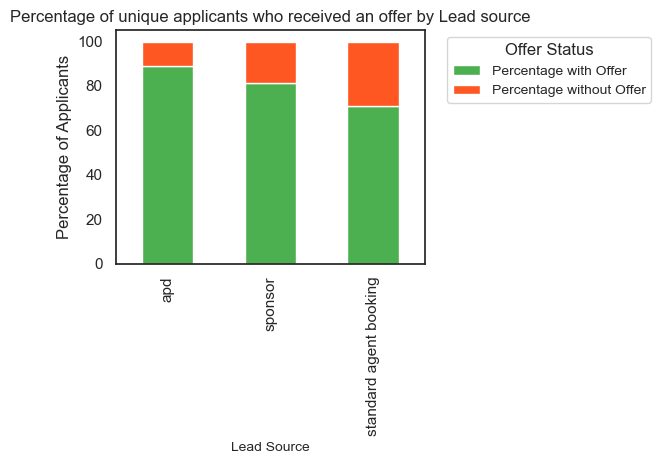

In [698]:
# Create visualisation to display the percentage of unique applicants with and without and offer by Lead source.
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style without grid
sns.set(style="white")

# Create the plot using seaborn's barplot function
plt.figure(figsize=(10, 6))

# Plot the percentages of applicants who received and did not receive an offer as a stacked bar chart
offer_status_by_lead_source[['Percentage with Offer', 'Percentage without Offer']].plot(kind='bar', 
                                                                                      stacked=True, 
                                                                                      color=['#4CAF50', '#FF5722'])

# Customize the plot
plt.title('Percentage of unique applicants who received an offer by Lead source', fontsize=12)
plt.xlabel('Lead Source', fontsize=10)
plt.ylabel('Percentage of Applicants', fontsize=12)

# Move the legend outside the plot
plt.legend(title='Offer Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Display the plot with improved layout
plt.tight_layout()
plt.show()

In [700]:
# Calculate the distribution of unique applicants with an offer by lead source in Percentages.
# Ensure no missing student_id, offered_date, and lead_source, and drop duplicates
sgdata_cleaned = sgdata_copy.dropna(subset=['student_id', 'offered_date', 'lead_source']) \
                            .drop_duplicates(subset='student_id')

# Filter data to only include applicants who received an offer
applicants_with_offer = sgdata_cleaned[sgdata_cleaned['offered_date'] != 'not specified']

# Count unique applicants by lead source who received an offer
lead_source_counts = applicants_with_offer['lead_source'].value_counts()

# Calculate percentages for each lead source
lead_source_percentages = (lead_source_counts / lead_source_counts.sum()) * 100

# Display the distribution
print("Distribution of Unique Applicants by Lead Source with an Offer:")
print(lead_source_percentages)


Distribution of Unique Applicants by Lead Source with an Offer:
lead_source
standard agent booking    78.420704
sponsor                   21.369752
apd                        0.209543
Name: count, dtype: float64


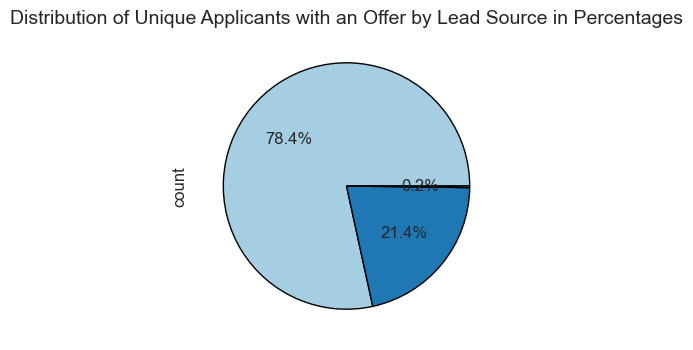

In [702]:
# Create visualisation to show the distribution of Unique applicants with an offer by Lead source.
import matplotlib.pyplot as plt

# Plotting the pie chart for lead source distribution
plt.figure(figsize=(4, 4))
lead_source_percentages.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors, 
                             wedgeprops={'edgecolor': 'black'}, labels=None)

# Add title
plt.title('Distribution of Unique Applicants with an Offer by Lead Source in Percentages', fontsize=14)

# Display the plot
plt.show()

**How many unique applicants received an offer by Programme?**

In [704]:
# Calculate the number of unique applicants with and without an offer by Programme.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']
applicants_with_offer_count = applicants_with_offer.groupby('programme')['student_id'].nunique()

# Get the unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
applicants_without_offer = unique_applicants[unique_applicants['offered_date'] == 'not specified']
applicants_without_offer_count = applicants_without_offer.groupby('programme')['student_id'].nunique()

# Merge the counts of applicants who received and did not receive an offer
offer_status_by_programme = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_count,
    'Applicants without Offer': applicants_without_offer_count
}).fillna(0)

# Convert counts to integers to remove the '.0'
offer_status_by_programme = offer_status_by_programme.astype(int)

# Sort the results based on the number of applicants with an offer
sorted_offer_status_by_programme = offer_status_by_programme.sort_values(by='Applicants with Offer', ascending=False)

# Print the results
print("Unique applicants by programme who received and did not receive an offer (sorted):")
print(sorted_offer_status_by_programme)

Unique applicants by programme who received and did not receive an offer (sorted):
             Applicants with Offer  Applicants without Offer
programme                                                   
foundation                   16625                      4794
pre masters                   6329                      2680
diploma                       4248                      2562


In [706]:
# Calculate the percentages of unique applicants with and without an offer by Programme.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']
applicants_with_offer_count = applicants_with_offer.groupby('programme')['student_id'].nunique()

# Get the unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
applicants_without_offer = unique_applicants[unique_applicants['offered_date'] == 'not specified']
applicants_without_offer_count = applicants_without_offer.groupby('programme')['student_id'].nunique()

# Merge the counts of applicants who received and did not receive an offer
offer_status_by_programme = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_count,
    'Applicants without Offer': applicants_without_offer_count
}).fillna(0)

# Calculate the total unique applicants per programme
total_unique_applicants_by_programme = unique_applicants.groupby('programme')['student_id'].nunique()

# Calculate the percentages for applicants with and without an offer
offer_status_by_programme['Percentage with Offer'] = (offer_status_by_programme['Applicants with Offer'] / 
                                                        total_unique_applicants_by_programme) * 100
offer_status_by_programme['Percentage without Offer'] = (offer_status_by_programme['Applicants without Offer'] / 
                                                           total_unique_applicants_by_programme) * 100

# Convert to integers to avoid decimals
offer_status_by_programme['Percentage with Offer'] = offer_status_by_programme['Percentage with Offer'].round(2)
offer_status_by_programme['Percentage without Offer'] = offer_status_by_programme['Percentage without Offer'].round(2)

# Sort the results based on the percentage of applicants with an offer
sorted_offer_status_by_programme = offer_status_by_programme.sort_values(by='Percentage with Offer', ascending=False)

# Print the results
print("Unique applicants by programme who received and did not receive an offer (in percentages):")
print(sorted_offer_status_by_programme[['Percentage with Offer', 'Percentage without Offer']])

Unique applicants by programme who received and did not receive an offer (in percentages):
             Percentage with Offer  Percentage without Offer
programme                                                   
foundation                   77.62                     22.38
pre masters                  70.25                     29.75
diploma                      62.38                     37.62


<Figure size 1200x800 with 0 Axes>

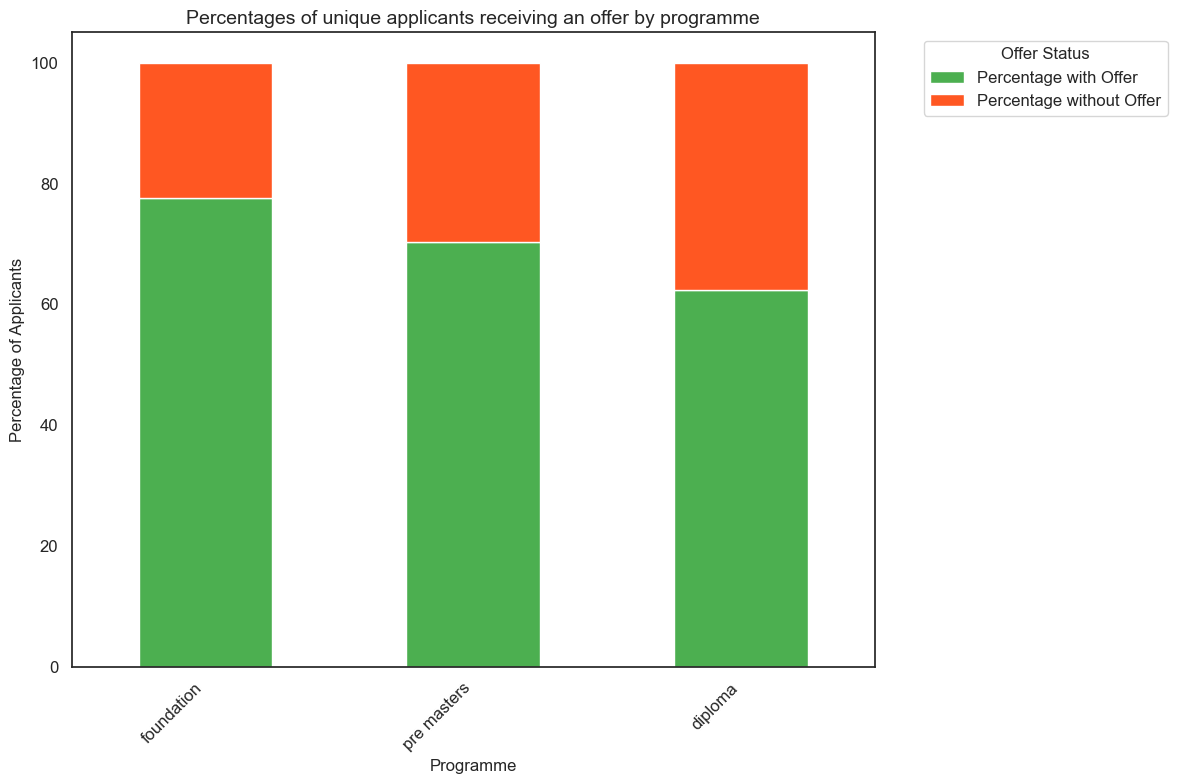

In [708]:
# Create visualisation to display the percentage of unique applicants with and without an offer by Programme.
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style without grid
sns.set(style="white")

# Sort the DataFrame by 'Percentage with Offer' in descending order
offer_status_by_programme_sorted = offer_status_by_programme.sort_values(by='Percentage with Offer', ascending=False)

# Create the plot using seaborn's barplot function
plt.figure(figsize=(12, 8))

# Plot the percentages of applicants who received and did not receive an offer as a stacked bar chart
offer_status_by_programme_sorted[['Percentage with Offer', 'Percentage without Offer']].plot(kind='bar', 
                                                                                          stacked=True, 
                                                                                          color=['#4CAF50', '#FF5722'], 
                                                                                          figsize=(12, 8))

# Customize the plot
plt.title('Percentages of unique applicants receiving an offer by programme', fontsize=14)
plt.xlabel('Programme', fontsize=12)
plt.ylabel('Percentage of Applicants', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Move the legend outside the plot
plt.legend(title='Offer Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

# Remove the grid
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

In [710]:
# Show the distribution of unique applicants with an offer by Programme.
# Ensure no missing student_id, offered_date, and programme, and drop duplicates
sgdata_cleaned = sgdata_copy.dropna(subset=['student_id', 'offered_date', 'programme']) \
                            .drop_duplicates(subset='student_id')

# Filter data to only include applicants who received an offer
applicants_with_offer = sgdata_cleaned[sgdata_cleaned['offered_date'] != 'not specified']

# Count unique applicants by programme who received an offer
programme_counts = applicants_with_offer['programme'].value_counts()

# Calculate percentages for each programme
programme_percentages = (programme_counts / programme_counts.sum()) * 100

# Display the distribution
print("Distribution of Unique Applicants with an Offer by Programme:")
print(programme_percentages)

Distribution of Unique Applicants with an Offer by Programme:
programme
foundation     61.116830
pre masters    23.266672
diploma        15.616499
Name: count, dtype: float64


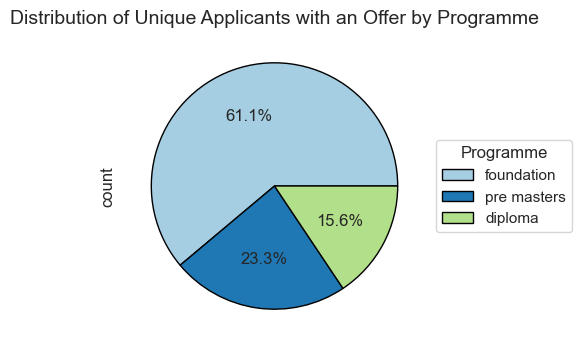

In [712]:
# Create visualisation to show the distribution of unique applicants with an offer by Programme.
import matplotlib.pyplot as plt

# Plotting the pie chart for programme distribution
plt.figure(figsize=(4, 4))
ax = programme_percentages.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors, 
                                wedgeprops={'edgecolor': 'black'}, labels=None)

# Add title
plt.title('Distribution of Unique Applicants with an Offer by Programme', fontsize=14)

# Add legend to the pie chart
plt.legend(labels=programme_percentages.index, title="Programme", loc='center left', bbox_to_anchor=(1, 0.5))

# Display the plot
plt.show()

**How many unique offers were sent by StudyGroup by centre?**

In [714]:
# Calculate the percentages of unique applicants with and without an offer by Centre.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']
applicants_with_offer_count = applicants_with_offer.groupby('centre')['student_id'].nunique()

# Get the unique applicants who did not receive an offer (where 'offered_date' is 'not specified')
applicants_without_offer = unique_applicants[unique_applicants['offered_date'] == 'not specified']
applicants_without_offer_count = applicants_without_offer.groupby('centre')['student_id'].nunique()

# Merge the counts of applicants who received and did not receive an offer
offer_status_by_centre = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_count,
    'Applicants without Offer': applicants_without_offer_count
}).fillna(0)

# Calculate the total unique applicants per centre
total_unique_applicants_by_centre = unique_applicants.groupby('centre')['student_id'].nunique()

# Calculate the percentages for applicants with and without an offer
offer_status_by_centre['Percentage with Offer'] = (offer_status_by_centre['Applicants with Offer'] / 
                                                    total_unique_applicants_by_centre) * 100
offer_status_by_centre['Percentage without Offer'] = (offer_status_by_centre['Applicants without Offer'] / 
                                                       total_unique_applicants_by_centre) * 100

# Convert to integers to avoid decimals
offer_status_by_centre['Percentage with Offer'] = offer_status_by_centre['Percentage with Offer'].round(2)
offer_status_by_centre['Percentage without Offer'] = offer_status_by_centre['Percentage without Offer'].round(2)

# Sort the results based on the percentage of applicants with an offer
sorted_offer_status_by_centre = offer_status_by_centre.sort_values(by='Percentage with Offer', ascending=False)

# Print the results
print("Unique applicants by centre who received and did not receive an offer (in percentages):")
print(sorted_offer_status_by_centre[['Percentage with Offer', 'Percentage without Offer']])

Unique applicants by centre who received and did not receive an offer (in percentages):
                Percentage with Offer  Percentage without Offer
centre                                                         
durham                          84.71                     15.29
leeds                           84.02                     15.98
sheffield                       81.92                     18.08
sussex                          76.74                     23.26
surrey                          76.02                     23.98
cardiff                         73.34                     26.66
aberdeen                        70.66                     29.34
leeds beckett                   69.18                     30.82
teesside                        66.70                     33.30
liverpool                       65.57                     34.43
royal holloway                  65.05                     34.95
lancaster                       62.65                     37.35
strathclyde     

<Figure size 1000x600 with 0 Axes>

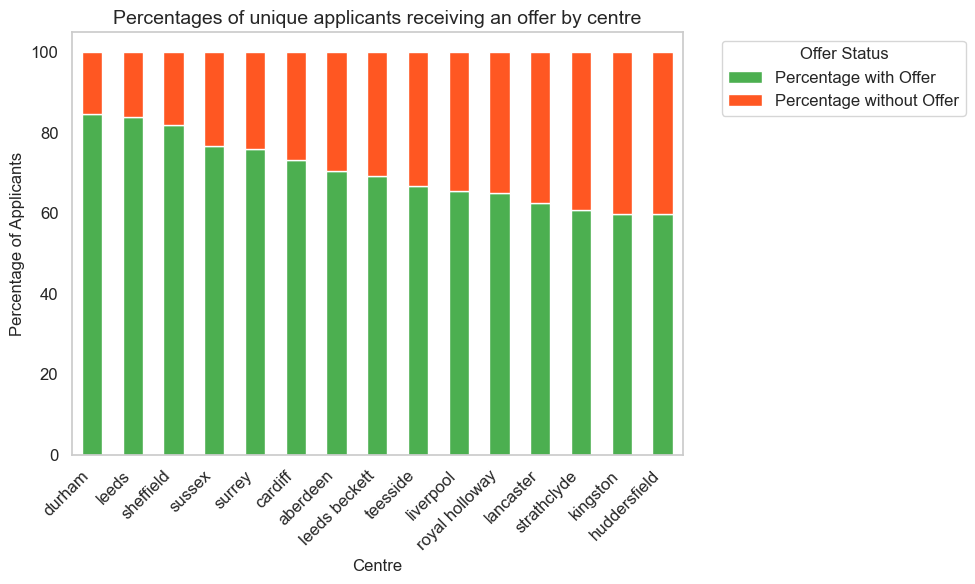

In [716]:
# Create visualisation to display the percentages of unique applicants with and without an offer by Centre.
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style without grid
sns.set(style="whitegrid")

# Sort the offer status by percentage of applicants with an offer in descending order
sorted_offer_status_by_centre = offer_status_by_centre.sort_values(by='Percentage with Offer', ascending=False)

# Prepare the data for visualization
sorted_offer_status_by_centre['Percentage with Offer'] = sorted_offer_status_by_centre['Percentage with Offer'].round(2)
sorted_offer_status_by_centre['Percentage without Offer'] = sorted_offer_status_by_centre['Percentage without Offer'].round(2)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the stacked bar chart using Seaborn
sorted_offer_status_by_centre[['Percentage with Offer', 'Percentage without Offer']].plot(kind='bar', 
                                                                                       stacked=True, 
                                                                                       color=['#4CAF50', '#FF5722'], 
                                                                                       figsize=(10, 6))

# Customize the plot
plt.title('Percentages of unique applicants receiving an offer by centre', fontsize=14)
plt.xlabel('Centre', fontsize=12)
plt.ylabel('Percentage of Applicants', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Move the legend outside the plot
plt.legend(title='Offer Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

# Remove the grid
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

In [718]:
# Show the distribution of unique applicants with an offer by Centre.
# Ensure no missing student_id, offered_date, and centre, and drop duplicates
sgdata_cleaned = sgdata_copy.dropna(subset=['student_id', 'offered_date', 'centre']) \
                            .drop_duplicates(subset='student_id')

# Filter data to only include applicants who received an offer
applicants_with_offer = sgdata_cleaned[sgdata_cleaned['offered_date'] != 'not specified']

# Count unique applicants by centre who received an offer
centre_counts = applicants_with_offer['centre'].value_counts()

# Calculate percentages for each centre
centre_percentages = (centre_counts / centre_counts.sum()) * 100

# Display the distribution
print("Distribution of Unique Applicants with an Offer by Centre:")
print(centre_percentages)

Distribution of Unique Applicants with an Offer by Centre:
centre
cardiff           16.340710
durham            15.579737
sheffield         12.289538
leeds              9.683112
kingston           6.381884
leeds beckett      6.264245
liverpool          5.370929
teesside           5.264319
huddersfield       5.084185
royal holloway     5.069480
sussex             3.845305
surrey             3.485038
aberdeen           3.205647
strathclyde        1.753548
lancaster          0.382325
Name: count, dtype: float64


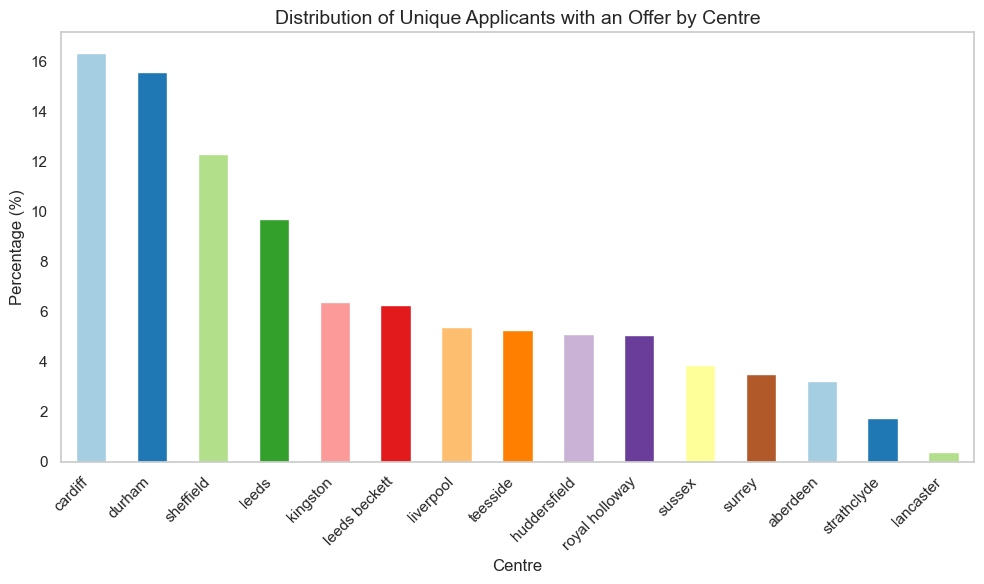

In [720]:
# Create visualisation to display the distribution of unique applicants with an offer by Centre.
import matplotlib.pyplot as plt

# Plotting the bar chart for centre distribution
plt.figure(figsize=(10, 6))
centre_percentages.plot(kind='bar', color=plt.cm.Paired.colors)

# Add title and labels
plt.title('Distribution of Unique Applicants with an Offer by Centre', fontsize=14)
plt.xlabel('Centre', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove grid
plt.grid(False)

# Display the plot
plt.tight_layout()
plt.show()

# 5. Programme enrollment.

**arrived_date column has programme start dates of students that have been enrolled. These students
have paid the program fee and started the course. So, for this analysis,
arrived_date column has been used as enrolled column.**

In [722]:
# Create a copy of the DataFrame
sgdata_copy_1 = sgdata_copy.copy()

# print the first few rows to verify the copy
print(sgdata_copy_1.head())

    centre programme          area     region sub_region agent_location  \
0  cardiff   diploma  anz & n asia        anz  australia      aus - vic   
1  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
2  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
3  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
4  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   

  branch_urn group_urn             lead_source  student_id  ...  \
0     a31552    a31552  standard agent booking     2864317  ...   
1     a15382    a29520  standard agent booking     2853769  ...   
2     a15382    a29520  standard agent booking     2863293  ...   
3      a7608     a7608  standard agent booking     2854643  ...   
4      d1107     d1107  standard agent booking     2871048  ...   

   confirmation_date   arrived_date cancellation_date  completed progressed  \
0      not specified  not specified        10/05/2023         no   

**Convert the values in arrived_date column into yes and no.**

In [724]:
# Replace 'not specified' with 'no' and everything else with 'yes'
sgdata_copy_1['arrived_date'] = sgdata_copy_1['arrived_date'].apply(
    lambda x: 'no' if x == 'not specified' else 'yes'
)

# Display the result
print(sgdata_copy_1['arrived_date'].value_counts())

arrived_date
no     67666
yes     4088
Name: count, dtype: int64


**How many students enrolled at StudyGroup?**

In [726]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who are enrolled (where 'arrived_date' is 'yes')
applicants_enrolled = unique_applicants[unique_applicants['arrived_date'] == 'yes']

# Calculate the total number of unique enrolled applicants
total_unique_enrolled = applicants_enrolled['student_id'].nunique()

# Print the result
print(f"Total number of unique applicants who enrolled: {total_unique_enrolled}")

Total number of unique applicants who enrolled: 2717


**What is the overall conversion rate from offers to enrollment?**

In [728]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']

# Get the unique applicants who are enrolled
applicants_enrolled = unique_applicants[unique_applicants['arrived_date'] == 'yes']

# Calculate the total number of unique applicants who received an offer
total_unique_applicants_with_offer = applicants_with_offer['student_id'].nunique()

# Calculate the total number of unique applicants who received an offer and enrolled
total_unique_enrolled_with_offer = applicants_enrolled[applicants_enrolled['student_id'].
isin(applicants_with_offer['student_id'])]['student_id'].nunique()

# Calculate the total number of applicants who received an offer but did not enroll
total_unique_not_enrolled_with_offer = total_unique_applicants_with_offer - total_unique_enrolled_with_offer

# Calculate the conversion rate (percentage of applicants who received an offer and enrolled)
conversion_rate = (total_unique_enrolled_with_offer / total_unique_applicants_with_offer) * 100

# Calculate the percentage of applicants who received an offer but did not enroll
not_enrolled_percentage = (total_unique_not_enrolled_with_offer / total_unique_applicants_with_offer) * 100

# Print the counts and the conversion rate
print(f"Total Unique Applicants with Offer: {total_unique_applicants_with_offer}")
print(f"Total Unique Applicants with Offer and Enrolled: {total_unique_enrolled_with_offer}")
print(f"Total Unique Applicants with Offer but Not Enrolled: {total_unique_not_enrolled_with_offer}")
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")
print(f"Percentage of unique Applicants with an offer but not enrolled: {not_enrolled_percentage:.2f}%")

Total Unique Applicants with Offer: 27202
Total Unique Applicants with Offer and Enrolled: 2717
Total Unique Applicants with Offer but Not Enrolled: 24485
Overall Conversion Rate: 9.99%
Percentage of unique Applicants with an offer but not enrolled: 90.01%


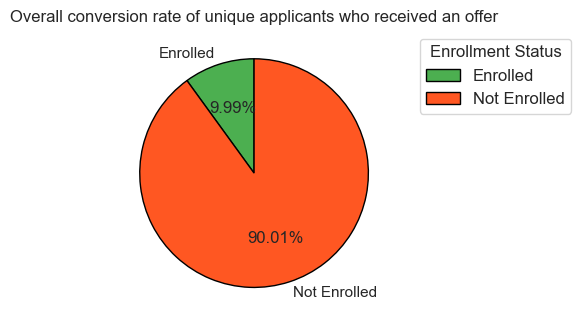

In [730]:
# Create visualisation to show the conversion rate of Unique applicants with an offer that enrolled.
import matplotlib.pyplot as plt
import seaborn as sns

# Data
labels = ['Enrolled', 'Not Enrolled']
sizes = [conversion_rate, not_enrolled_percentage]
colors = ['#4CAF50', '#FF5722']  # Green for Enrolled, Red for Not Enrolled

# Set Seaborn style
sns.set(style="whitegrid")

# Create the pie chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.2f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})

# Add a title
plt.title('Overall conversion rate of unique applicants who received an offer', fontsize=12)

# Show the legend outside the chart
plt.legend(labels, title="Enrollment Status", loc="upper left", fontsize=12, bbox_to_anchor=(1.05, 1))

# Show the plot
plt.tight_layout()
plt.show()

**Only 9.9 percentage of unique applicants who received an offer enrolled.**

**what percentage of unique applicants who received an offer successfully enroll at StudyGroup by area?**

In [732]:
# Show the distribution of unique applicants with an offer that enrolled and did not enrolled by Area.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']

# Get the unique applicants who are enrolled (arrived_date == 'yes')
applicants_enrolled = unique_applicants[unique_applicants['arrived_date'] == 'yes']

# Group by area and calculate the total unique applicants with offer and enrolled applicants
applicants_with_offer_by_area = applicants_with_offer.groupby('area')['student_id'].nunique()
applicants_enrolled_by_area = applicants_enrolled[applicants_enrolled['student_id'].isin(applicants_with_offer['student_id'])] \
    .groupby('area')['student_id'].nunique()

# Calculate the applicants who received an offer but did not enroll
applicants_not_enrolled_by_area = applicants_with_offer_by_area - applicants_enrolled_by_area

# Combine the counts into a single DataFrame (just counts)
offer_status_by_area_count = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_by_area,
    'Applicants Enrolled': applicants_enrolled_by_area,
    'Applicants Not Enrolled': applicants_not_enrolled_by_area
}).fillna(0)

# Sort by "Applicants with Offer" in descending order
sorted_offer_status_by_area_count = offer_status_by_area_count.sort_values(by='Applicants with Offer', ascending=False)

# Print the sorted result
print("Sorted count of Unique Applicants with Offer, Enrolled, and Not Enrolled by Area:")
print(sorted_offer_status_by_area_count)

Sorted count of Unique Applicants with Offer, Enrolled, and Not Enrolled by Area:
                  Applicants with Offer  Applicants Enrolled  \
area                                                           
elmea & pakistan                   8514                  767   
china                              6566                  847   
uk eu & americas                   6481                  398   
south asia                         3266                  229   
anz & n asia                       1425                  253   
se asia                             950                  223   

                  Applicants Not Enrolled  
area                                       
elmea & pakistan                     7747  
china                                5719  
uk eu & americas                     6083  
south asia                           3037  
anz & n asia                         1172  
se asia                               727  


In [734]:
# Show the conversion rate of unique applicants with an offer by Area.
import pandas as pd

# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']

# Get the unique applicants who are enrolled (arrived_date == 'yes')
applicants_enrolled = unique_applicants[unique_applicants['arrived_date'] == 'yes']

# Group by area and calculate the total unique applicants with offer and enrolled applicants
applicants_with_offer_by_area = applicants_with_offer.groupby('area')['student_id'].nunique()
applicants_enrolled_by_area = applicants_enrolled[applicants_enrolled['student_id'].isin(applicants_with_offer['student_id'])] \
    .groupby('area')['student_id'].nunique()

# Calculate the applicants who received an offer but did not enroll
applicants_not_enrolled_by_area = applicants_with_offer_by_area - applicants_enrolled_by_area

# Combine the counts into a single DataFrame (just counts)
offer_status_by_area_count = pd.DataFrame({
    'Unique applicants with Offer': applicants_with_offer_by_area,
    'Applicants Enrolled': applicants_enrolled_by_area,
    'Applicants Not Enrolled': applicants_not_enrolled_by_area
}).fillna(0)

# Calculate the percentage for each category by dividing by the total unique applicants in each area
offer_status_by_area_percentage = offer_status_by_area_count.copy()

offer_status_by_area_percentage['Percentage with Offer'] = (offer_status_by_area_percentage['Unique applicants with Offer'] / 
                                                             offer_status_by_area_percentage['Unique applicants with Offer'].sum()) * 100

offer_status_by_area_percentage['Percentage Enrolled'] = (offer_status_by_area_percentage['Applicants Enrolled'] / 
                                                           offer_status_by_area_percentage['Unique applicants with Offer']) * 100

offer_status_by_area_percentage['Percentage Not Enrolled'] = (offer_status_by_area_percentage['Applicants Not Enrolled'] / 
                                                               offer_status_by_area_percentage['Unique applicants with Offer']) * 100

# Combine both counts and percentages into a final DataFrame
final_offer_status_by_area = pd.concat([offer_status_by_area_count, offer_status_by_area_percentage[['Percentage with Offer', 
                                                                                                            'Percentage Enrolled', 
                                                                                                            'Percentage Not Enrolled']]], axis=1)

# Sort by "Percentage Enrolled" in descending order
sorted_final_offer_status_by_area = final_offer_status_by_area.sort_values(by='Percentage Enrolled', ascending=False)

# Print the sorted result with counts and percentages
print("Sorted count and percentage of Unique Applicants with Offer, Enrolled, and Not Enrolled by Area:")
print(sorted_final_offer_status_by_area)

Sorted count and percentage of Unique Applicants with Offer, Enrolled, and Not Enrolled by Area:
                  Unique applicants with Offer  Applicants Enrolled  \
area                                                                  
se asia                                    950                  223   
anz & n asia                              1425                  253   
china                                     6566                  847   
elmea & pakistan                          8514                  767   
south asia                                3266                  229   
uk eu & americas                          6481                  398   

                  Applicants Not Enrolled  Percentage with Offer  \
area                                                               
se asia                               727               3.492390   
anz & n asia                         1172               5.238585   
china                                5719              24.1379

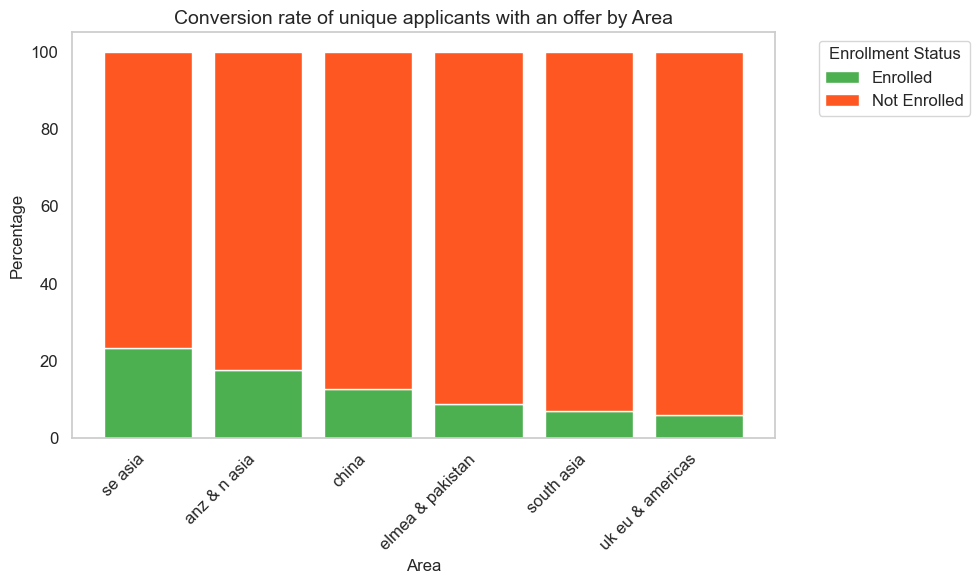

In [736]:
# Create visualisation to display the Conversion rate of unique applicants with an offer by Area.
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Create a DataFrame for the plot from the result
plot_data = sorted_final_offer_status_by_area[['Percentage Enrolled', 'Percentage Not Enrolled']].reset_index()

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the stacked bars
plt.bar(plot_data['area'], plot_data['Percentage Enrolled'], color='#4CAF50', label='Enrolled')
plt.bar(plot_data['area'], plot_data['Percentage Not Enrolled'], bottom=plot_data['Percentage Enrolled'], 
        color='#FF5722', label='Not Enrolled')

# Customize the plot
plt.title('Conversion rate of unique applicants with an offer by Area', fontsize=14)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Percentage', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a legend outside the chart
plt.legend(title='Enrollment Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

# Remove grid
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

In [738]:
# Show the distribution of unique applicants that enrolled in percentages by Area.
# Ensure no missing student_id, enrolled_status, and area, and drop duplicates
sgdata_cleaned = sgdata_copy_1.dropna(subset=['student_id', 'arrived_date', 'area']) \
                            .drop_duplicates(subset='student_id')

# Filter data to only include applicants who are enrolled
enrolled_applicants = sgdata_cleaned[sgdata_cleaned['arrived_date'] != 'not specified']

# Count unique enrolled applicants by area
area_counts = enrolled_applicants['area'].value_counts()

# Calculate percentages for each area
area_percentages = (area_counts / area_counts.sum()) * 100

# Display the distribution
print("Distribution of Enrolled Unique Applicants by Area:")
print(area_percentages)

Distribution of Enrolled Unique Applicants by Area:
area
elmea & pakistan    32.579623
uk eu & americas    24.458886
china               20.194425
south asia          14.973951
anz & n asia         4.678017
se asia              3.115097
Name: count, dtype: float64


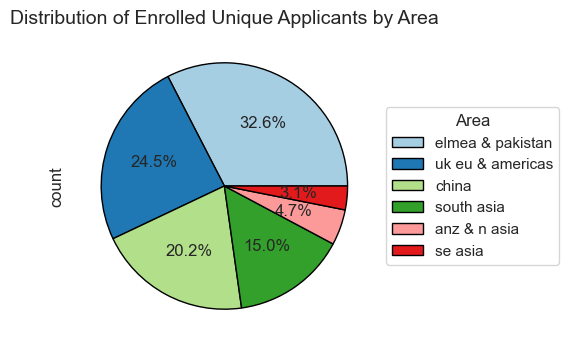

In [740]:
# Create visualisation to display the distribution of unique applicants that enrolled in percentages by Area.
import matplotlib.pyplot as plt

# Plotting the pie chart for area distribution
plt.figure(figsize=(4, 4))
area_percentages.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors, 
                      wedgeprops={'edgecolor': 'black'}, labels=None)

# Add title
plt.title('Distribution of Enrolled Unique Applicants by Area', fontsize=14)

# Add legend to the pie chart
plt.legend(labels=area_percentages.index, title="Area", loc='center left', bbox_to_anchor=(1, 0.5))

# Display the plot
plt.show()

**How many unique applicants who received an offer successfully enroll at StudyGroup by region?**

In [742]:
# Show the number of unique applicants with an offer that enrolled and did not enrolled by Region.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']

# Get the unique applicants who are enrolled (arrived_date == 'yes')
applicants_enrolled = unique_applicants[unique_applicants['arrived_date'] == 'yes']

# Group by region and calculate the total unique applicants with offer and enrolled applicants
applicants_with_offer_by_region = applicants_with_offer.groupby('region')['student_id'].nunique()
applicants_enrolled_by_region = applicants_enrolled[applicants_enrolled['student_id'].isin(applicants_with_offer['student_id'])] \
    .groupby('region')['student_id'].nunique()

# Calculate the applicants who received an offer but did not enroll
applicants_not_enrolled_by_region = applicants_with_offer_by_region - applicants_enrolled_by_region

# Combine the counts into a single DataFrame (just counts)
offer_status_by_region_count = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_by_region,
    'Applicants Enrolled': applicants_enrolled_by_region,
    'Applicants Not Enrolled': applicants_not_enrolled_by_region
}).fillna(0)

# Sort by "Applicants with Offer" in descending order
sorted_offer_status_by_region_count = offer_status_by_region_count.sort_values(by='Applicants with Offer', ascending=False)

# Print the sorted result
print("Sorted count of Unique Applicants with Offer, Enrolled, and Not Enrolled by Region:")
print(sorted_offer_status_by_region_count)

Sorted count of Unique Applicants with Offer, Enrolled, and Not Enrolled by Region:
                             Applicants with Offer  Applicants Enrolled  \
region                                                                    
uk & w europe                                 5852                  345   
middle east                                   3996                  302   
india                                         2743                  156   
pakistan                                      2522                  251   
n c2 china                                    2459                  305   
e c1 china                                    2332                  343   
s w china                                     1775                  199   
s europe, levant & n africa                   1261                  139   
hong kong                                      826                  135   
se asia 2                                      639                  158   
rest of s asia  

In [744]:
# Calculate the percentages of unique applicants that enrolled and did not enrolled with an offer by Region.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']

# Get the unique applicants who are enrolled (arrived_date == 'yes')
applicants_enrolled = unique_applicants[unique_applicants['arrived_date'] == 'yes']

# Group by region and calculate the total unique applicants with offer and enrolled applicants
applicants_with_offer_by_region = applicants_with_offer.groupby('region')['student_id'].nunique()
applicants_enrolled_by_region = applicants_enrolled[applicants_enrolled['student_id'].isin(applicants_with_offer['student_id'])] \
    .groupby('region')['student_id'].nunique()

# Calculate the number of applicants with offer who are NOT enrolled
applicants_with_offer_not_enrolled = applicants_with_offer_by_region - applicants_enrolled_by_region

# Calculate the percentages for applicants enrolled with an offer and not enrolled with an offer
enrolled_with_offer_percentage = (applicants_enrolled_by_region / applicants_with_offer_by_region) * 100
not_enrolled_with_offer_percentage = (applicants_with_offer_not_enrolled / applicants_with_offer_by_region) * 100

# Combine the counts and percentages into a single DataFrame
enrollment_percentage_by_region = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_by_region,
    'Enrolled with Offer': applicants_enrolled_by_region,
    'Enrolled with Offer Percentage': enrolled_with_offer_percentage,
    'Not Enrolled with Offer': applicants_with_offer_not_enrolled,
    'Not Enrolled with Offer Percentage': not_enrolled_with_offer_percentage
}).fillna(0)

# Sort by "Enrolled with Offer Percentage" in descending order
sorted_enrollment_percentage_by_region = enrollment_percentage_by_region.sort_values(by='Enrolled with Offer Percentage', ascending=False)

# Print the sorted result side by side
print("Sorted count and percentage of Applicants Enrolled and not Enrolled with Offer by Region:")
print(sorted_enrollment_percentage_by_region)

Sorted count and percentage of Applicants Enrolled and not Enrolled with Offer by Region:
                             Applicants with Offer  Enrolled with Offer  \
region                                                                    
se asia 2                                      639                  158   
north asia                                     503                  106   
se asia 1                                      311                   65   
hong kong                                      826                  135   
rest of africa                                 312                   49   
e c1 china                                    2332                  343   
russia, e europe, c asia                       137                   20   
rest of s asia                                 523                   73   
anz                                             96                   12   
n c2 china                                    2459                  305   
s w china 

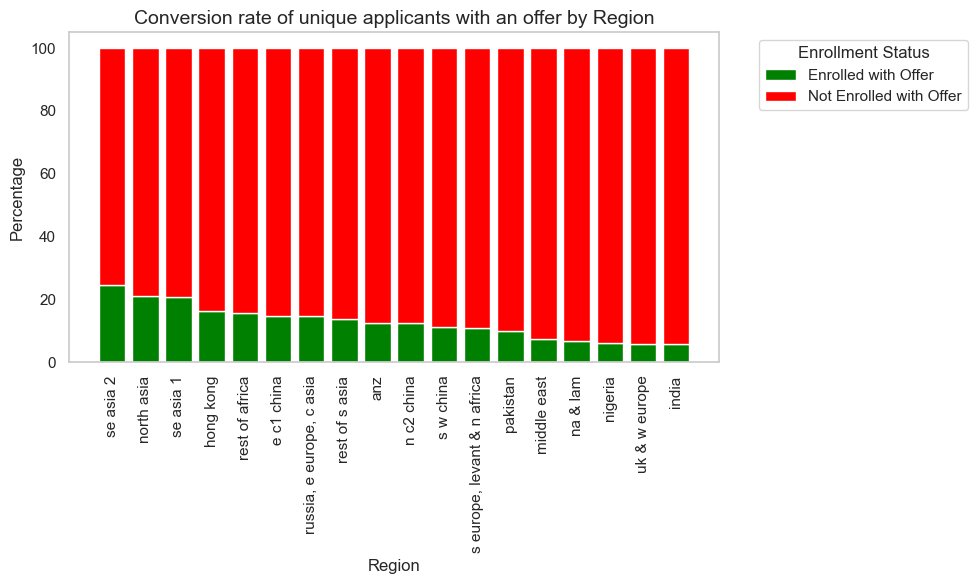

In [746]:
# Create visualisation to display the conversion rate of unique applicants with an offer by Region.
import matplotlib.pyplot as plt

# Data for stacked bar chart
regions = sorted_enrollment_percentage_by_region.index
enrolled_percentage = sorted_enrollment_percentage_by_region[
    'Enrolled with Offer Percentage'
]
not_enrolled_percentage = sorted_enrollment_percentage_by_region[
    'Not Enrolled with Offer Percentage'
]

# Create the figure and axis
plt.figure(figsize=(10, 6))

# Create stacked bar plot
plt.bar(regions, enrolled_percentage, label='Enrolled with Offer', color='green')
plt.bar(regions, not_enrolled_percentage, bottom=enrolled_percentage,
        label='Not Enrolled with Offer', color='red')

# Adding title and labels
plt.title('Conversion rate of unique applicants with an offer '
          'by Region', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Percentage', fontsize=12)

# Remove gridlines
plt.grid(False)

# Move the legend outside the plot
plt.legend(title='Enrollment Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show x-axis labels vertically
plt.xticks(rotation=90)

# Display the plot
plt.tight_layout()
plt.show()

In [748]:
# Show the distribution of uniqe applicants that enrolled with an offer by Region.
# Ensure no missing student_id, offered_date, arrived_date, and region, and drop duplicates
sgdata_cleaned_r = sgdata_copy_1.dropna(subset=['student_id', 'offered_date', 'arrived_date', 'region']) \
                            .drop_duplicates(subset='student_id')

# Filter data to only include applicants who received an offer and are enrolled
applicants_with_offer_enrolled = sgdata_cleaned_r[(sgdata_cleaned_r['offered_date'] != 'not specified') & 
                                               (sgdata_cleaned_r['arrived_date'] == 'yes')]

# Count unique applicants who received an offer and enrolled by region
region_counts = applicants_with_offer_enrolled['region'].value_counts()

# Calculate percentages for each region
region_percentages = (region_counts / region_counts.sum()) * 100

# Display the distribution
print("Distribution of Unique Applicants with an Offer that Enrolled by Region:")
print(region_percentages)


Distribution of Unique Applicants with an Offer that Enrolled by Region:
region
uk & w europe                  12.697828
e c1 china                     12.624218
n c2 china                     11.225616
middle east                    11.115201
pakistan                        9.238130
s w china                       7.324255
se asia 2                       5.815237
india                           5.741627
s europe, levant & n africa     5.115937
hong kong                       4.968715
north asia                      3.901362
rest of s asia                  2.686787
se asia 1                       2.392344
rest of africa                  1.803460
na & lam                        1.214575
nigeria                         0.956938
russia, e europe, c asia        0.736106
anz                             0.441664
Name: count, dtype: float64


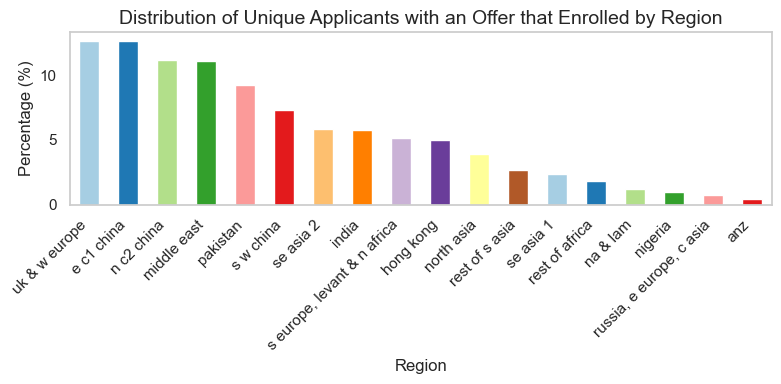

In [1077]:
# Create visualisation to display the distribution of enrolled unique applicants with an offer by region.
import matplotlib.pyplot as plt

# Plotting the bar chart for region distribution
plt.figure(figsize=(8, 4))
region_percentages.plot(kind='bar', color=plt.cm.Paired.colors)

# Add title and labels
plt.title('Distribution of Unique Applicants with an Offer that Enrolled by Region', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove grid
plt.grid(False)

# Display the plot
plt.tight_layout()
plt.show()

**How many unique applicants who received an offer successfully enroll at StudyGroup by sub_region?**

In [752]:
# Calculate the number of unique applicants that enrolled and did not enrolled with an offer 
# by Sub-Region. Also show in percentages.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[
    unique_applicants['offered_date'] != 'not specified'
]

# Get the unique applicants who are enrolled (arrived_date == 'yes')
applicants_enrolled = unique_applicants[
    unique_applicants['arrived_date'] == 'yes'
]

# Group by sub_region and calculate the total unique applicants with offer and enrolled applicants
applicants_with_offer_by_sub_region = applicants_with_offer.groupby(
    'sub_region')['student_id'].nunique()
applicants_enrolled_by_sub_region = applicants_enrolled[
    applicants_enrolled['student_id'].isin(applicants_with_offer['student_id'])
].groupby('sub_region')['student_id'].nunique()

# Calculate the number of applicants with offer who are NOT enrolled
applicants_with_offer_not_enrolled = applicants_with_offer_by_sub_region - applicants_enrolled_by_sub_region

# Calculate the percentages for applicants enrolled with an offer and not enrolled with an offer
enrolled_with_offer_percentage = (
    (applicants_enrolled_by_sub_region / applicants_with_offer_by_sub_region) * 100
)
not_enrolled_with_offer_percentage = (
    (applicants_with_offer_not_enrolled / applicants_with_offer_by_sub_region) * 100
)

# Combine the counts and percentages into a single DataFrame
enrollment_percentage_by_sub_region = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_by_sub_region,
    'Enrolled with Offer': applicants_enrolled_by_sub_region,
    'Enrolled with Offer Percentage': enrolled_with_offer_percentage,
    'Not Enrolled with Offer': applicants_with_offer_not_enrolled,
    'Not Enrolled with Offer Percentage': not_enrolled_with_offer_percentage
}).fillna(0)

# Convert counts to integers and percentages to integers (rounded)
enrollment_percentage_by_sub_region['Applicants with Offer'] = (
    enrollment_percentage_by_sub_region['Applicants with Offer'].astype(int)
)
enrollment_percentage_by_sub_region['Enrolled with Offer'] = (
    enrollment_percentage_by_sub_region['Enrolled with Offer'].astype(int)
)
enrollment_percentage_by_sub_region['Not Enrolled with Offer'] = (
    enrollment_percentage_by_sub_region['Not Enrolled with Offer'].astype(int)
)

# Sort by "Enrolled with Offer Percentage" in descending order
sorted_enrollment_percentage_by_sub_region = enrollment_percentage_by_sub_region.sort_values(
    by='Enrolled with Offer Percentage', ascending=False
)

# Print the sorted result side by side
print("Sorted count and percentage of Applicants Enrolled and Not Enrolled with Offer by Sub Region:")
print(sorted_enrollment_percentage_by_sub_region)

Sorted count and percentage of Applicants Enrolled and Not Enrolled with Offer by Sub Region:
                         Applicants with Offer  Enrolled with Offer  \
sub_region                                                            
korea                                      126                   51   
cambodia, laos                              16                    5   
myanmar                                    190                   59   
indonesia                                   93                   26   
eastern europe                              50                   12   
singapore                                  178                   42   
vietnam                                    114                   24   
thailand                                   181                   36   
sri lanka                                  256                   48   
malaysia, brunei                           153                   27   
hong kong                                  826        

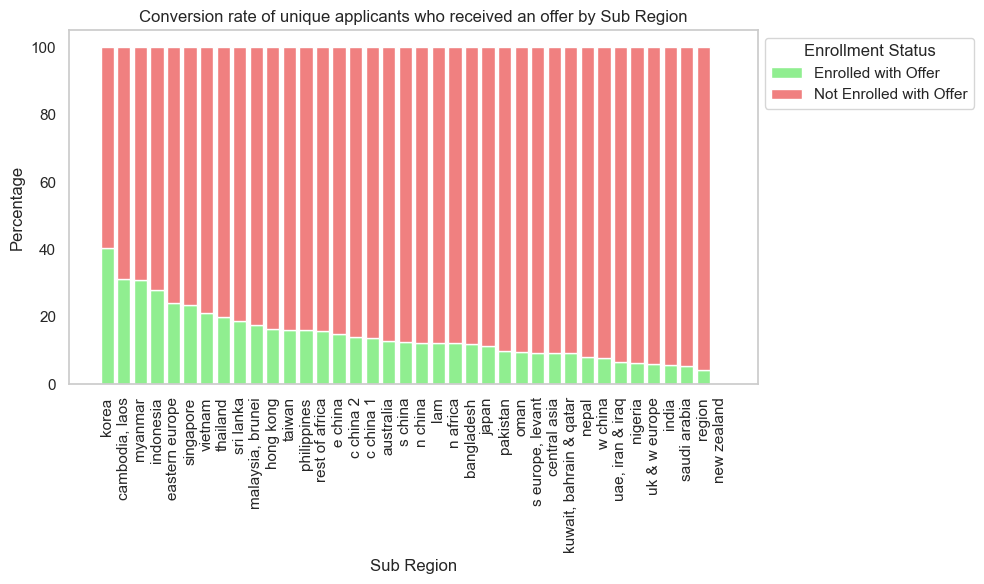

In [754]:
# Create visualisation to display the conversion rate of unique applicants with an offer by Sub-Region.
import matplotlib.pyplot as plt

# Set the plot size
plt.figure(figsize=(10, 6))

# Plot the stacked bar chart
plt.bar(
    sorted_enrollment_percentage_by_sub_region.index, 
    sorted_enrollment_percentage_by_sub_region['Enrolled with Offer Percentage'], 
    label='Enrolled with Offer', 
    color='lightgreen'
)

plt.bar(
    sorted_enrollment_percentage_by_sub_region.index, 
    sorted_enrollment_percentage_by_sub_region['Not Enrolled with Offer Percentage'], 
    bottom=sorted_enrollment_percentage_by_sub_region['Enrolled with Offer Percentage'], 
    label='Not Enrolled with Offer', 
    color='lightcoral'
)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)

# Add labels and title
plt.xlabel('Sub Region')
plt.ylabel('Percentage')
plt.title('Conversion rate of unique applicants who received an offer by Sub Region')

# Move the legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Enrollment Status")

# Remove the grid
plt.grid(False)

# Display the plot
plt.tight_layout()  
plt.show()

In [756]:
# Show the distribution of enrolled unique applicants by Sub-Region in Percentages.
# Ensure no missing student_id, offered_date, arrived_date, and sub-region, and drop duplicates
sgdata_cleaned_subregion = sgdata_copy_1.dropna(subset=['student_id', 'offered_date', 'arrived_date', 'sub_region']) \
                                         .drop_duplicates(subset='student_id')

# Filter data to only include applicants who received an offer and are enrolled
applicants_with_offer_enrolled_subregion = sgdata_cleaned_subregion[
    (sgdata_cleaned_subregion['offered_date'] != 'not specified') & 
    (sgdata_cleaned_subregion['arrived_date'] == 'yes')
]

# Count unique applicants who received an offer and enrolled by sub-region
subregion_counts = applicants_with_offer_enrolled_subregion['sub_region'].value_counts()

# Calculate percentages for each sub-region
subregion_percentages = (subregion_counts / subregion_counts.sum()) * 100

# Display the distribution
print("Distribution of Enrolled Unique Applicants with an Offer by Sub-region:")
print(subregion_percentages)

Distribution of Enrolled Unique Applicants with an Offer by Sub-region:
sub_region
uk & w europe              12.697828
e china                     9.937431
n china                     9.385351
pakistan                    9.238130
kuwait, bahrain & qatar     5.999264
s china                     5.925653
india                       5.741627
hong kong                   4.968715
n africa                    3.533309
c china 1                   2.686787
saudi arabia                2.576371
myanmar                     2.171513
korea                       1.877070
c china 2                   1.840265
rest of africa              1.803460
sri lanka                   1.766654
s europe, levant            1.582628
taiwan                      1.545823
singapore                   1.545823
uae, iran & iraq            1.398601
w china                     1.398601
thailand                    1.324991
oman                        1.140964
malaysia, brunei            0.993743
indonesia                   0

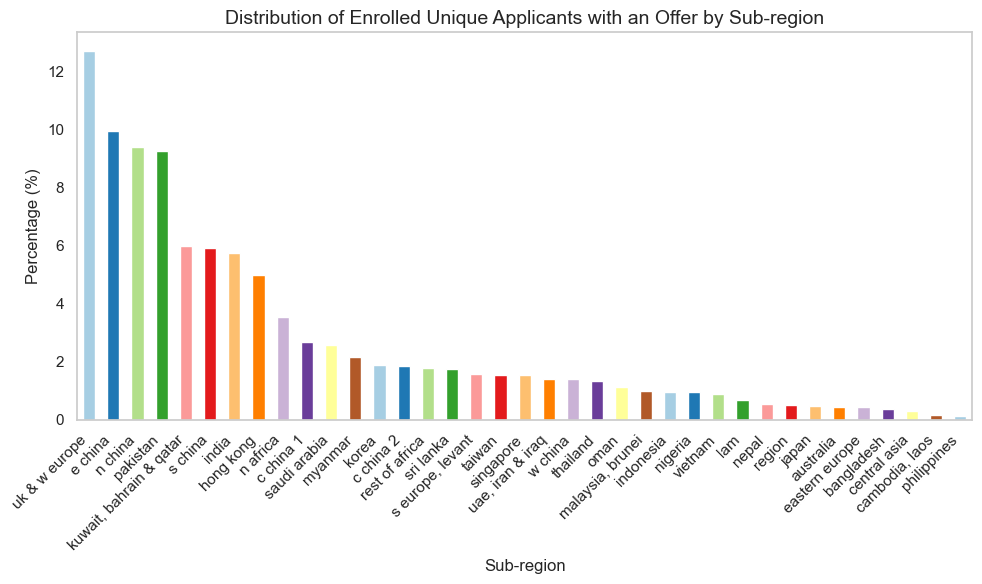

In [758]:
import matplotlib.pyplot as plt

# Plotting the bar chart for sub-region distribution
plt.figure(figsize=(10, 6))
subregion_percentages.plot(kind='bar', color=plt.cm.Paired.colors)

# Add title and labels
plt.title('Distribution of Enrolled Unique Applicants with an Offer by Sub-region', fontsize=14)
plt.xlabel('Sub-region', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove grid
plt.grid(False)

# Display the plot
plt.tight_layout()
plt.show()

**How many unique applicants who received an offer successfully enrolled at StudyGroup by nationality?**

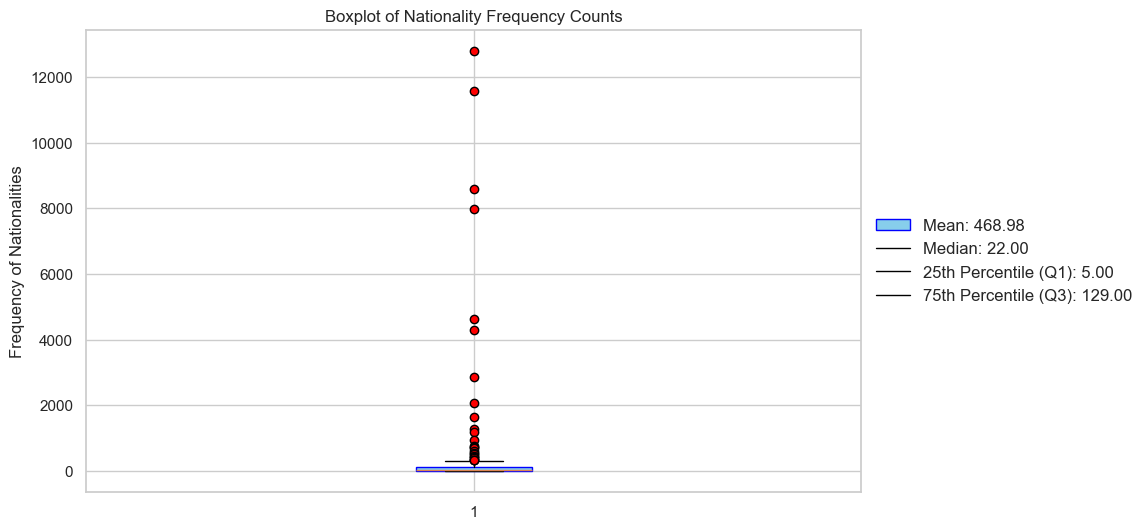

In [760]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the value counts for the 'nationality' column
nationality_counts = sgdata_copy_1['nationality'].value_counts()

# Calculate the statistics: mean, median, quartiles
mean_value = nationality_counts.mean()
median_value = nationality_counts.median()
q1_value = nationality_counts.quantile(0.25)
q3_value = nationality_counts.quantile(0.75)

# Create a vertical boxplot for the frequencies of nationalities
plt.figure(figsize=(10, 6))

# The boxplot will use 'boxprops' to control color
plt.boxplot(nationality_counts, vert=True, patch_artist=True,
            boxprops=dict(facecolor='skyblue', color='blue'),
            flierprops=dict(markerfacecolor='red', marker='o', markersize=6))

# Add labels and title
plt.title('Boxplot of Nationality Frequency Counts')
plt.ylabel('Frequency of Nationalities')

# Add a legend outside the plot
plt.legend(
    labels=[
        f'Mean: {mean_value:.2f}',
        f'Median: {median_value:.2f}',
        f'25th Percentile (Q1): {q1_value:.2f}',
        f'75th Percentile (Q3): {q3_value:.2f}'
    ],
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    frameon=False
)

# Display the plot
plt.show()

In [762]:
# Show the number of unique applicants that enrolled and did not enrolled with an offer by Nationality.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[
    unique_applicants['offered_date'] != 'not specified'
]

# Get the unique applicants who are enrolled (arrived_date == 'yes')
applicants_enrolled = unique_applicants[
    unique_applicants['arrived_date'] == 'yes'
]

# Group by nationality and calculate the total unique applicants with offer and enrolled applicants
applicants_with_offer_by_nationality = applicants_with_offer.groupby(
    'nationality')['student_id'].nunique()
applicants_enrolled_by_nationality = applicants_enrolled[
    applicants_enrolled['student_id'].isin(applicants_with_offer['student_id'])
].groupby('nationality')['student_id'].nunique()

# Calculate the number of applicants with offer who are NOT enrolled
applicants_with_offer_not_enrolled = applicants_with_offer_by_nationality - applicants_enrolled_by_nationality

# Combine the counts into a single DataFrame
count_by_nationality = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_by_nationality,
    'Enrolled with Offer': applicants_enrolled_by_nationality,
    'Not Enrolled with Offer': applicants_with_offer_not_enrolled
}).fillna(0)

# Convert counts to integers
count_by_nationality['Applicants with Offer'] = count_by_nationality['Applicants with Offer'].astype(int)
count_by_nationality['Enrolled with Offer'] = count_by_nationality['Enrolled with Offer'].astype(int)
count_by_nationality['Not Enrolled with Offer'] = count_by_nationality['Not Enrolled with Offer'].astype(int)

# Sort by "Enrolled with Offer" count in descending order and show the top 30
top_30_count_by_nationality = count_by_nationality.sort_values(
    by='Enrolled with Offer', ascending=False
).head(30)

# Print the top 30 counts by nationality
print("Top 30 count of Applicants with Offer, Enrolled with Offer, and Not Enrolled with Offer by Nationality:")
print(top_30_count_by_nationality)

Top 30 count of Applicants with Offer, Enrolled with Offer, and Not Enrolled with Offer by Nationality:
                   Applicants with Offer  Enrolled with Offer  \
nationality                                                     
chinese                             7030                  917   
pakistani                           3301                  287   
kuwaiti                             1789                  164   
indian                              2814                  161   
saudi                               3302                  150   
hong kong chinese                    778                  122   
myanmarian                           207                   67   
egyptian                            1112                   62   
korean                               129                   52   
sri lankan                           275                   49   
algerian                             179                   42   
omani                                356           

In [764]:
# Calculate the percentage of "Enrolled with Offer" and "Not Enrolled with Offer"
count_by_nationality_percentage = count_by_nationality[['Enrolled with Offer', 'Not Enrolled with Offer']].apply(
    lambda row: row / row.sum() * 100, axis=1
)

# Sort by "Enrolled with Offer" percentage in descending order and show the top 30
top_30_percentage_by_nationality = count_by_nationality_percentage.sort_values(
    by='Enrolled with Offer', ascending=False
).head(30)

# Print the top 30 percentages of Enrolled with Offer and Not Enrolled with Offer
print("Top 30 percentages of Enrolled with Offer and Not Enrolled with Offer by Nationality:")
print(top_30_percentage_by_nationality)

Top 30 percentages of Enrolled with Offer and Not Enrolled with Offer by Nationality:
                    Enrolled with Offer  Not Enrolled with Offer
nationality                                                     
kosovan                      100.000000                 0.000000
luxembourg                   100.000000                 0.000000
malawian                     100.000000                 0.000000
seychelles                   100.000000                 0.000000
honduran                      50.000000                50.000000
uruguayan                     50.000000                50.000000
mongolian                     50.000000                50.000000
bruneian                      50.000000                50.000000
colombian                     41.666667                58.333333
korean                        40.310078                59.689922
laotian                       40.000000                60.000000
armenian                      40.000000                60.000000
bots

In [766]:
# Show the distribution of enrolled unique applicants with an offer by Nationality.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']

# Get the unique applicants who are enrolled (arrived_date == 'yes')
applicants_enrolled = unique_applicants[unique_applicants['arrived_date'] == 'yes']

# Group by nationality and calculate the total unique applicants with offer and enrolled applicants
applicants_with_offer_by_nationality = applicants_with_offer.groupby('nationality')['student_id'].nunique()
applicants_enrolled_by_nationality = applicants_enrolled[applicants_enrolled['student_id'].isin(applicants_with_offer['student_id'])] \
    .groupby('nationality')['student_id'].nunique()

# Calculate the total number of enrolled students with an offer
total_enrolled_with_offer = applicants_enrolled_by_nationality.sum()

# Calculate the percentage of enrolled students by nationality
enrolled_percentage_by_nationality = (applicants_enrolled_by_nationality / total_enrolled_with_offer) * 100

# Combine the counts and percentages into a single DataFrame
enrollment_distribution_by_nationality = pd.DataFrame({
    'Enrolled with Offer': applicants_enrolled_by_nationality,
    'Enrolled Percentage': enrolled_percentage_by_nationality
}).fillna(0)

# Convert to integers
enrollment_distribution_by_nationality['Enrolled with Offer'] = (
    enrollment_distribution_by_nationality['Enrolled with Offer'].astype(int)
)
enrollment_distribution_by_nationality['Enrolled Percentage'] = (
    enrollment_distribution_by_nationality['Enrolled Percentage'].round(2)
)

# Sort by "Enrolled Percentage" in descending order
sorted_enrollment_distribution_by_nationality = enrollment_distribution_by_nationality.sort_values(
    by='Enrolled Percentage', ascending=False
)

# Limit the output to the top 30 nationalities
top_30_enrollment_distribution_by_nationality = sorted_enrollment_distribution_by_nationality.head(30)

# Print the top 30 sorted result
print("Top 30 Sorted Distribution of Enrolled Students by Nationality:")
print(top_30_enrollment_distribution_by_nationality)

Top 30 Sorted Distribution of Enrolled Students by Nationality:
                   Enrolled with Offer  Enrolled Percentage
nationality                                                
chinese                            917                33.75
pakistani                          287                10.56
kuwaiti                            164                 6.04
indian                             161                 5.93
saudi                              150                 5.52
hong kong chinese                  122                 4.49
myanmarian                          67                 2.47
egyptian                            62                 2.28
korean                              52                 1.91
sri lankan                          49                 1.80
algerian                            42                 1.55
omani                               41                 1.51
taiwanese                           40                 1.47
qatari                              

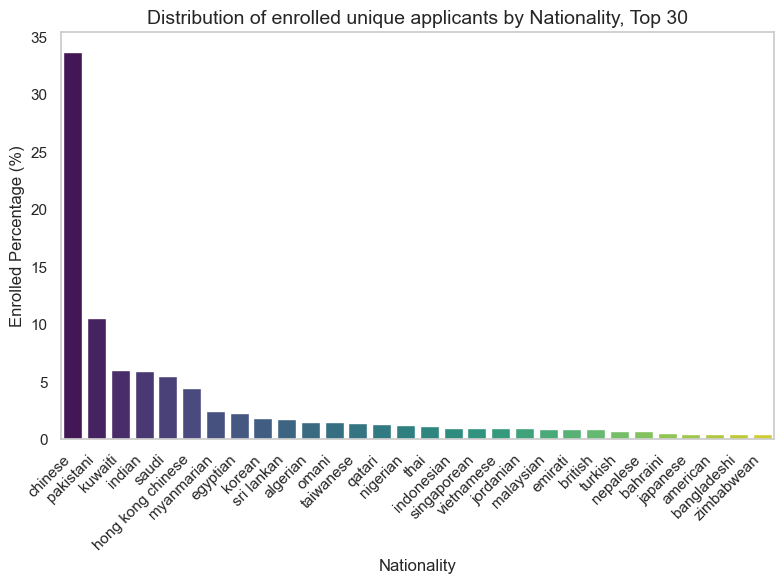

In [768]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Suppress FutureWarnings globally to avoid them in future visualizations
warnings.simplefilter(action='ignore', category=FutureWarning)

# Set the figure size
plt.figure(figsize=(8, 6))

# Create the barplot for Enrolled Percentage by Nationality
sns.barplot(
    x=top_30_enrollment_distribution_by_nationality.index,
    y=top_30_enrollment_distribution_by_nationality['Enrolled Percentage'],
    hue=top_30_enrollment_distribution_by_nationality.index,  # Assign x to hue to avoid the FutureWarning
    palette='viridis'
)

# Add labels and title
plt.xlabel('Nationality', fontsize=12)
plt.ylabel('Enrolled Percentage (%)', fontsize=12)
plt.title('Distribution of enrolled unique applicants by Nationality, Top 30', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove gridlines for cleaner presentation
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

**How many unique applicants who receive an offer successfully enroll at StudyGroup by lead source?**

In [770]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']

# Get the unique applicants who are enrolled (arrived_date == 'yes')
applicants_enrolled = unique_applicants[unique_applicants['arrived_date'] == 'yes']

# Group by lead source and calculate the total unique applicants with offer and enrolled applicants
applicants_with_offer_by_lead_source = applicants_with_offer.groupby('lead_source')['student_id'].nunique()
applicants_enrolled_by_lead_source = applicants_enrolled[applicants_enrolled['student_id'].isin(applicants_with_offer['student_id'])] \
    .groupby('lead_source')['student_id'].nunique()

# Calculate the applicants who received an offer but did not enroll
applicants_not_enrolled_by_lead_source = applicants_with_offer_by_lead_source - applicants_enrolled_by_lead_source

# Calculate the percentage of applicants enrolled and not enrolled with offer
enrolled_percentage_by_lead_source = (
    (applicants_enrolled_by_lead_source / applicants_with_offer_by_lead_source) * 100
)

not_enrolled_percentage_by_lead_source = (
    (applicants_not_enrolled_by_lead_source / applicants_with_offer_by_lead_source) * 100
)

# Combine the counts and percentages into a single DataFrame
offer_status_by_lead_source_percentage = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_by_lead_source,
    'Applicants Enrolled': applicants_enrolled_by_lead_source,
    'Enrolled Percentage': enrolled_percentage_by_lead_source,
    'Applicants Not Enrolled': applicants_not_enrolled_by_lead_source,
    'Not Enrolled Percentage': not_enrolled_percentage_by_lead_source
}).fillna(0)

# Sort by "Applicants with Offer" in descending order
sorted_offer_status_by_lead_source_percentage = offer_status_by_lead_source_percentage.sort_values(by='Enrolled Percentage', ascending=False)

# Print the sorted result
print("Sorted count and percentage of Unique Applicants with Offer, Enrolled, and Not Enrolled by Lead Source:")
print(sorted_offer_status_by_lead_source_percentage)

Sorted count and percentage of Unique Applicants with Offer, Enrolled, and Not Enrolled by Lead Source:
                        Applicants with Offer  Applicants Enrolled  \
lead_source                                                          
apd                                        57                   23   
standard agent booking                  21332                 2367   
sponsor                                  5813                  327   

                        Enrolled Percentage  Applicants Not Enrolled  \
lead_source                                                            
apd                               40.350877                       34   
standard agent booking            11.096006                    18965   
sponsor                            5.625323                     5486   

                        Not Enrolled Percentage  
lead_source                                      
apd                                   59.649123  
standard agent booking            

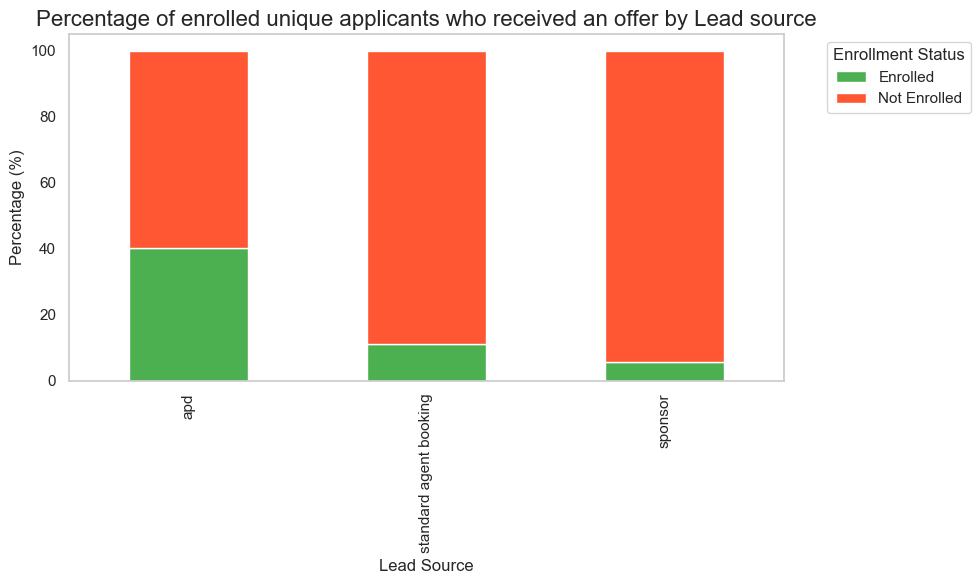

In [772]:
# Create visualisation to display the conversion rate of unique applicants by Lead source.
import matplotlib.pyplot as plt

# Create a stacked bar plot for Enrolled and Not Enrolled Percentage by Lead Source
plt.figure(figsize=(10, 6))

# Plot the stacked bar chart: Enrolled percentage and Not Enrolled percentage
ax = sorted_offer_status_by_lead_source_percentage[['Enrolled Percentage', 'Not Enrolled Percentage']].plot(
    kind='bar', stacked=True, color=['#4CAF50', '#FF5733'], ax=plt.gca()
)

# Add labels and title
plt.title('Percentage of enrolled unique applicants who received an offer by Lead source', fontsize=16)
plt.xlabel('Lead Source', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility

# Remove grid
plt.grid(False)

# Display the legend outside the chart
plt.legend(title='Enrollment Status', loc='upper left', labels=['Enrolled', 'Not Enrolled'], bbox_to_anchor=(1.05, 1))

# Display the plot
plt.tight_layout()
plt.show()

In [774]:
# Ensure no missing student_id, offered_date, arrived_date, and lead_source, and drop duplicates
sgdata_cleaned_lead = sgdata_copy_1.dropna(subset=['student_id', 'offered_date', 'arrived_date', 'lead_source']) \
                                    .drop_duplicates(subset='student_id')

# Filter data to only include applicants who received an offer and are enrolled
applicants_with_offer_enrolled_lead = sgdata_cleaned_lead[
    (sgdata_cleaned_lead['offered_date'] != 'not specified') & 
    (sgdata_cleaned_lead['arrived_date'] == 'yes')
]

# Count unique applicants by lead source who received an offer and enrolled
lead_source_counts = applicants_with_offer_enrolled_lead['lead_source'].value_counts()

# Calculate percentages for each lead source
lead_source_percentages = (lead_source_counts / lead_source_counts.sum()) * 100

# Display the distribution
print("Distribution of Unique Applicants Enrolled with an Offer by Lead Source:")
print(lead_source_percentages)

Distribution of Unique Applicants Enrolled with an Offer by Lead Source:
lead_source
standard agent booking    87.118145
sponsor                   12.035333
apd                        0.846522
Name: count, dtype: float64


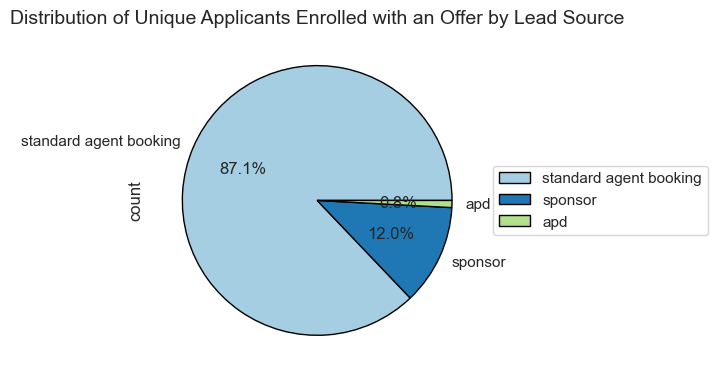

In [776]:
# Create visualisation to show the distribution of unique applicants enrolled with an offer by Lead source.
import matplotlib.pyplot as plt

# Plotting the pie chart for lead source distribution
plt.figure(figsize=(7, 7))
ax = lead_source_percentages.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors,
                                  wedgeprops={'edgecolor': 'black'}, legend=False)

# Add title
plt.title('Distribution of Unique Applicants Enrolled with an Offer by Lead Source', fontsize=14)

# Display the legend outside the pie chart
plt.legend(lead_source_percentages.index, loc='center left', bbox_to_anchor=(1, 0.5))

# Display the plot
plt.tight_layout()
plt.show()

**How many unique applicants who receive an offer successfully enroll at StudyGroup by programme?**

In [778]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']

# Get the unique applicants who are enrolled (arrived_date == 'yes')
applicants_enrolled = unique_applicants[unique_applicants['arrived_date'] == 'yes']

# Group by programme and calculate the total unique applicants with offer and enrolled applicants
applicants_with_offer_by_programme = applicants_with_offer.groupby('programme')['student_id'].nunique()
applicants_enrolled_by_programme = applicants_enrolled[applicants_enrolled['student_id'].isin(applicants_with_offer['student_id'])] \
    .groupby('programme')['student_id'].nunique()

# Calculate the applicants who received an offer but did not enroll
applicants_not_enrolled_by_programme = applicants_with_offer_by_programme - applicants_enrolled_by_programme

# Calculate the percentage of applicants enrolled and not enrolled with offer
enrolled_percentage_by_programme = (
    (applicants_enrolled_by_programme / applicants_with_offer_by_programme) * 100
)

not_enrolled_percentage_by_programme = (
    (applicants_not_enrolled_by_programme / applicants_with_offer_by_programme) * 100
)

# Combine the counts and percentages into a single DataFrame
offer_status_by_programme_percentage = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_by_programme,
    'Applicants Enrolled': applicants_enrolled_by_programme,
    'Enrolled Percentage': enrolled_percentage_by_programme,
    'Applicants Not Enrolled': applicants_not_enrolled_by_programme,
    'Not Enrolled Percentage': not_enrolled_percentage_by_programme
}).fillna(0)

# Sort by "Enrolled Percentage" in descending order
sorted_offer_status_by_programme_percentage = offer_status_by_programme_percentage.sort_values(by='Enrolled Percentage', ascending=False)

# Print the sorted result
print("Sorted count and percentage of Unique Applicants with Offer, Enrolled, and Not Enrolled by Programme:")
print(sorted_offer_status_by_programme_percentage)

Sorted count and percentage of Unique Applicants with Offer, Enrolled, and Not Enrolled by Programme:
             Applicants with Offer  Applicants Enrolled  Enrolled Percentage  \
programme                                                                      
diploma                       4248                  501            11.793785   
pre masters                   6329                  615             9.717175   
foundation                   16625                 1601             9.630075   

             Applicants Not Enrolled  Not Enrolled Percentage  
programme                                                      
diploma                         3747                88.206215  
pre masters                     5714                90.282825  
foundation                     15024                90.369925  


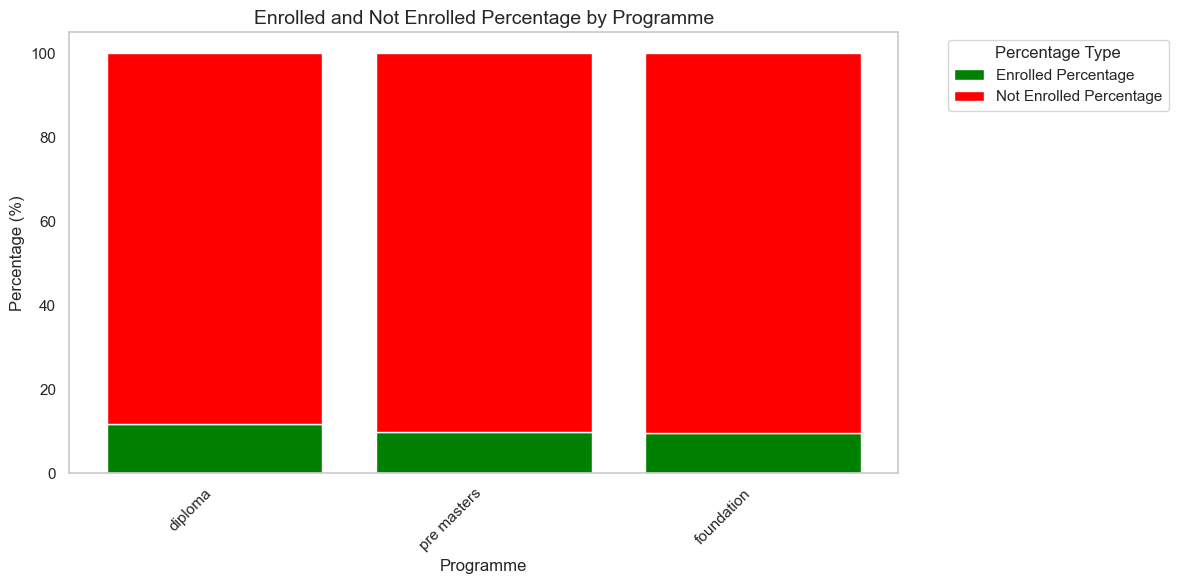

In [782]:
import matplotlib.pyplot as plt

# Prepare the data for the stacked bar chart
enrolled_percentage = sorted_offer_status_by_programme_percentage['Enrolled Percentage']
not_enrolled_percentage = sorted_offer_status_by_programme_percentage['Not Enrolled Percentage']

# Plotting the stacked bar chart
plt.figure(figsize=(12, 6))

# Bar for Enrolled Percentage
plt.bar(sorted_offer_status_by_programme_percentage.index, enrolled_percentage, 
        color='green', label='Enrolled Percentage')

# Bar for Not Enrolled Percentage (stacked on top)
plt.bar(sorted_offer_status_by_programme_percentage.index, not_enrolled_percentage, 
        bottom=enrolled_percentage, color='red', label='Not Enrolled Percentage')

# Adding title and labels
plt.title('Enrolled and Not Enrolled Percentage by Programme', fontsize=14)
plt.xlabel('Programme', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Display legend outside the chart
plt.legend(title="Percentage Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove the grid
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

**Show the distribution of enrolled students by programme.**

In [784]:
# Ensure no duplicates, each student is counted only once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']

# Get the unique applicants who are enrolled (arrived_date == 'yes') and received an offer
enrolled_applicants_with_offer = applicants_with_offer[applicants_with_offer['arrived_date'] == 'yes']

# Count the total number of enrolled students across all programmes
total_enrolled_students = enrolled_applicants_with_offer['student_id'].nunique()

# Count the number of unique enrolled applicants who received an offer by programme
enrolled_with_offer_by_programme = enrolled_applicants_with_offer.groupby('programme')['student_id'].nunique()

# Calculate the percentage of enrolled students by programme
enrolled_percentage_by_programme = (enrolled_with_offer_by_programme / total_enrolled_students) * 100

# Combine the counts and percentages into a DataFrame
enrolled_with_offer_percentages_df = pd.DataFrame({
    'Applicants Enrolled with Offer': enrolled_with_offer_by_programme,
    'Enrolled Percentage': enrolled_percentage_by_programme
}).fillna(0)

# Sort the data by "Enrolled Percentage" in descending order to find the programme with the highest enrollment trend
enrolled_with_offer_percentages_df_sorted = enrolled_with_offer_percentages_df.sort_values(by='Enrolled Percentage', ascending=False)

# Display the sorted result
print("Distribution of Unique Applicants Enrolled with Offer by Programme in Percentages:")
print(enrolled_with_offer_percentages_df_sorted)

Distribution of Unique Applicants Enrolled with Offer by Programme in Percentages:
             Applicants Enrolled with Offer  Enrolled Percentage
programme                                                       
foundation                             1601            58.925285
pre masters                             615            22.635259
diploma                                 501            18.439455


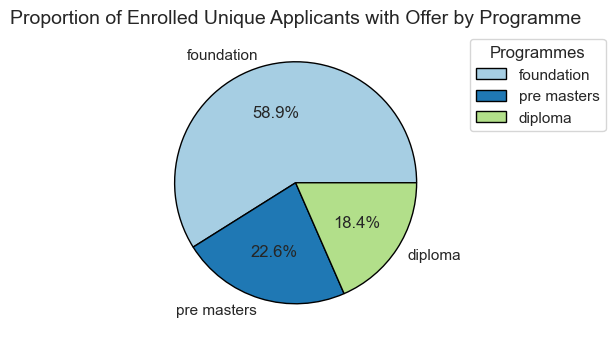

In [786]:
# Create visualisation to show the distribution of enrolled students by Programme.
import matplotlib.pyplot as plt

# Plotting the pie chart for enrolled proportion by programme
plt.figure(figsize=(5, 5))
plt.pie(enrolled_with_offer_proportion_df_sorted['Enrolled Percentage'],
        labels=enrolled_with_offer_proportion_df_sorted.index,
        autopct='%1.1f%%', 
        colors=plt.cm.Paired.colors, 
        wedgeprops={'edgecolor': 'black'})

# Add title
plt.title("Proportion of Enrolled Unique Applicants with Offer by Programme", fontsize=14)

# Add legend outside the chart
plt.legend(enrolled_with_offer_proportion_df_sorted.index, 
           title="Programmes", 
           bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

**How many unique applicants who received an offer successfully enrolled at StudyGroup by centre?**

In [788]:
# Show the count and percentages of unique applicants that enrolled and did not enrolled with an offer by Centre.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']

# Get the unique applicants who are enrolled (arrived_date == 'yes')
applicants_enrolled = unique_applicants[unique_applicants['arrived_date'] == 'yes']

# Group by centre and calculate the total unique applicants with offer and enrolled applicants
applicants_with_offer_by_centre = applicants_with_offer.groupby('centre')['student_id'].nunique()
applicants_enrolled_by_centre = applicants_enrolled[applicants_enrolled['student_id'].isin(applicants_with_offer['student_id'])] \
    .groupby('centre')['student_id'].nunique()

# Calculate the applicants who received an offer but did not enroll
applicants_not_enrolled_by_centre = applicants_with_offer_by_centre - applicants_enrolled_by_centre

# Calculate the percentage of applicants enrolled and not enrolled with offer
enrolled_percentage_by_centre = (
    (applicants_enrolled_by_centre / applicants_with_offer_by_centre) * 100
)

not_enrolled_percentage_by_centre = (
    (applicants_not_enrolled_by_centre / applicants_with_offer_by_centre) * 100
)

# Combine the counts and percentages into a single DataFrame
offer_status_by_centre_percentage = pd.DataFrame({
    'Applicants with Offer': applicants_with_offer_by_centre,
    'Applicants Enrolled': applicants_enrolled_by_centre,
    'Enrolled Percentage': enrolled_percentage_by_centre,
    'Applicants Not Enrolled': applicants_not_enrolled_by_centre,
    'Not Enrolled Percentage': not_enrolled_percentage_by_centre
}).fillna(0)

# Sort by "Enrolled Percentage" in descending order
sorted_offer_status_by_centre_percentage = offer_status_by_centre_percentage.sort_values(by='Enrolled Percentage', ascending=False)

# Print the sorted result
print("Sorted count and percentage of Unique Applicants with Offer, Enrolled, and Not Enrolled by Centre:")
print(sorted_offer_status_by_centre_percentage)

Sorted count and percentage of Unique Applicants with Offer, Enrolled, and Not Enrolled by Centre:
                Applicants with Offer  Applicants Enrolled  \
centre                                                       
sussex                           1046                172.0   
sheffield                        3343                514.0   
strathclyde                       477                 68.0   
royal holloway                   1379                167.0   
huddersfield                     1383                166.0   
leeds                            2634                294.0   
durham                           4238                448.0   
liverpool                        1461                138.0   
surrey                            948                 87.0   
leeds beckett                    1704                126.0   
kingston                         1736                114.0   
cardiff                          4445                288.0   
teesside                         

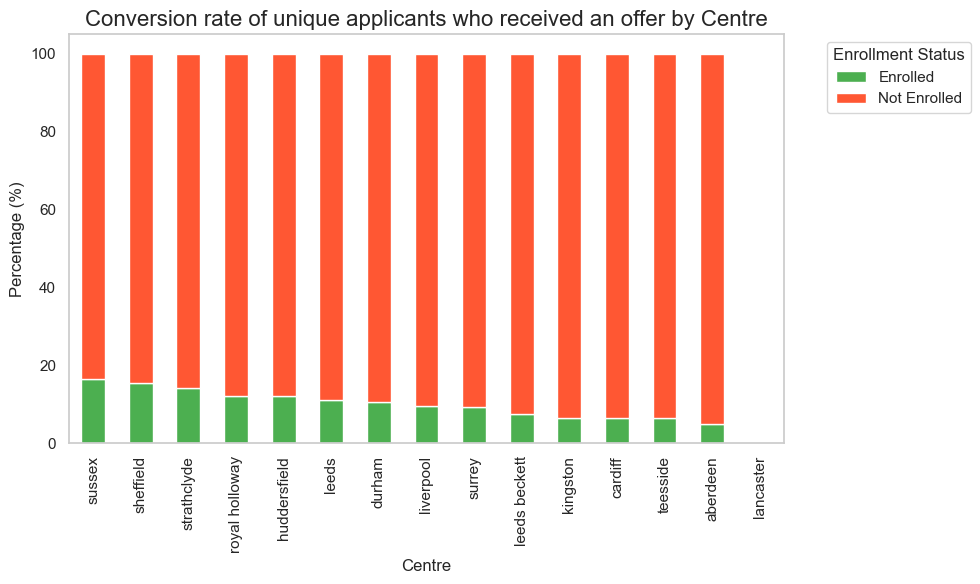

In [790]:
# Create visualisation to show the conversion rate of unique applicants with an offer by Centre.
import matplotlib.pyplot as plt

# Create a stacked bar plot for Enrolled Percentage and Not Enrolled Percentage by Centre
plt.figure(figsize=(10, 6))

# Plot the stacked bar chart: Enrolled percentage and Not Enrolled percentage
ax = sorted_offer_status_by_centre_percentage[['Enrolled Percentage', 'Not Enrolled Percentage']].plot(
    kind='bar', stacked=True, color=['#4CAF50', '#FF5733'], ax=plt.gca()
)

# Add labels and title
plt.title('Conversion rate of unique applicants who received an offer by Centre', fontsize=16)
plt.xlabel('Centre', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility

# Remove grid
plt.grid(False)

# Display the legend outside the chart
plt.legend(title='Enrollment Status', loc='upper left', labels=['Enrolled', 'Not Enrolled'], bbox_to_anchor=(1.05, 1))

# Display the plot
plt.tight_layout()
plt.show()

In [792]:
# Show the distribution of Unique Applicants that Enrolled with an Offer by Centre in Percentages
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_1.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer (excluding 'not specified')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] != 'not specified']

# Get the unique applicants who are enrolled (arrived_date == 'yes')
applicants_enrolled = unique_applicants[unique_applicants['arrived_date'] == 'yes']

# Filter the applicants who received an offer and are enrolled
applicants_with_offer_enrolled = applicants_enrolled[applicants_enrolled['student_id'].isin(applicants_with_offer['student_id'])]

# Count unique applicants who enrolled with an offer by centre
centre_counts = applicants_with_offer_enrolled['centre'].value_counts()

# Calculate percentages for each centre
centre_percentages = (centre_counts / centre_counts.sum()) * 100

# Display the distribution
print("Distribution of Unique Applicants that Enrolled with an Offer by Centre in Percentages:")
print(centre_percentages)

Distribution of Unique Applicants that Enrolled with an Offer by Centre in Percentages:
centre
sheffield         18.917924
durham            16.488774
leeds             10.820758
cardiff           10.599926
sussex             6.330512
royal holloway     6.146485
huddersfield       6.109680
liverpool          5.079131
leeds beckett      4.637468
kingston           4.195804
teesside           3.386088
surrey             3.202061
strathclyde        2.502760
aberdeen           1.582628
Name: count, dtype: float64


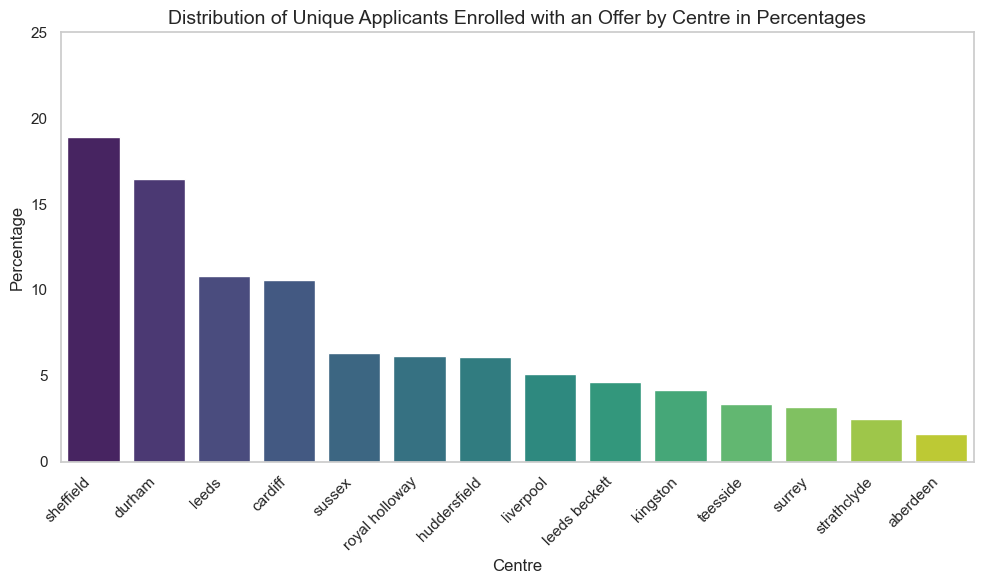

In [794]:
# Create visualisation to show the distribution of unique applicants enrolled with an offer by Centre in Percentages.
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the bar chart for the distribution of unique applicants enrolled with an offer by centre
plt.figure(figsize=(10, 6))
sns.barplot(x=centre_percentages.index, y=centre_percentages.values, palette="viridis")

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

# Set the title and labels
plt.title("Distribution of Unique Applicants Enrolled with an Offer by Centre in Percentages", fontsize=14)
plt.xlabel("Centre", fontsize=12)
plt.ylabel("Percentage", fontsize=12)

# Remove gridlines
plt.grid(False)

# Adjust the y-axis ticks to show a difference of 5 percentage points
plt.yticks(range(0, 30, 5))

# Display the plot
plt.tight_layout()
plt.show()

# 5. Discount analysis

In [880]:
import pandas as pd

# Create a copy of the 'sgdata_copy_1' DataFrame
sgdata_copy_a = sgdata_copy_1.copy()

# Verify the copy by printing the first few rows
print(sgdata_copy_a.head())

    centre programme          area     region sub_region agent_location  \
0  cardiff   diploma  anz & n asia        anz  australia      aus - vic   
1  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
2  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
3  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
4  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   

  branch_urn group_urn             lead_source  student_id  ...  \
0     a31552    a31552  standard agent booking     2864317  ...   
1     a15382    a29520  standard agent booking     2853769  ...   
2     a15382    a29520  standard agent booking     2863293  ...   
3      a7608     a7608  standard agent booking     2854643  ...   
4      d1107     d1107  standard agent booking     2871048  ...   

   confirmation_date arrived_date cancellation_date  completed progressed  \
0      not specified           no        10/05/2023         no       

In [882]:
# print the first few rows to verify the copy
print(sgdata_copy_a['discount'].dtypes)
print(sgdata_copy_a['offered_date'].dtypes)
print(sgdata_copy_a['discount'].head())
print(sgdata_copy_a['offered_date'].head())

float64
object
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: discount, dtype: float64
0    not specified
1       21/11/2023
2       29/11/2023
3    not specified
4       06/12/2023
Name: offered_date, dtype: object


In [884]:
# Replace 'not specified' with 'no' and everything else with 'yes'
sgdata_copy_a['offered_date'] = sgdata_copy_a['offered_date'].apply(
    lambda x: 'no' if x == 'not specified' else 'yes'
)

# Display the result
print(sgdata_copy_a['offered_date'].value_counts())

offered_date
yes    51892
no     19862
Name: count, dtype: int64


In [886]:
# print the first few rows to verify the copy
print(sgdata_copy_a['discount'].dtypes)
print(sgdata_copy_a['offered_date'].dtypes)
print(sgdata_copy_a['discount'].head())
print(sgdata_copy_a['offered_date'].head())

float64
object
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: discount, dtype: float64
0     no
1    yes
2    yes
3     no
4    yes
Name: offered_date, dtype: object


**What is the sum of the total discounts provided by StudyGroup?**

In [888]:
# Calculate the total sum of the discount column
total_discount_sum = sgdata_copy_a['discount'].sum()

# Format the total discount sum with £ and commas for better readability
formatted_total_discount_sum = f"£{total_discount_sum:,.2f}"

# Print the result
print(f"Total discount sum: {formatted_total_discount_sum}")

Total discount sum: £6,535,651.33


**What is the sum and average of the discounts provided to the unique applicants who received an offer to study?**

In [890]:
# Group by 'offered_date' and calculate sum and average of the 'discount'
discount_by_offer = sgdata_copy_a.groupby('offered_date')['discount'].agg(['sum', 'mean'])

# Format the results for better readability
discount_by_offer['sum'] = discount_by_offer['sum'].apply(lambda x: f"£{x:,.2f}")
discount_by_offer['mean'] = discount_by_offer['mean'].apply(lambda x: f"£{x:,.2f}" if not pd.isna(x) else "£0.00")

# Print the result
print(discount_by_offer)

                        sum     mean
offered_date                        
no               £43,235.00    £2.18
yes           £6,492,416.33  £125.11


**Show the distribution of sum and average of the discounts provided to the unique applicants who received an offer to study by Area.**

In [892]:
# Group by 'offered_date' and 'area', and calculate sum and average of the 'discount'
discount_by_area_and_offer = sgdata_copy_a.groupby(['offered_date', 'area'])['discount'].agg(['sum', 'mean'])

# Separate the "Yes" and "No" offered_date groups
offered_yes_a = discount_by_area_and_offer[discount_by_area_and_offer.index.get_level_values('offered_date') == 'yes']
offered_no_a = discount_by_area_and_offer[discount_by_area_and_offer.index.get_level_values('offered_date') == 'no']

# Sort by 'mean' for both categories (yes and no)
offered_yes_a_sorted = offered_yes_a.sort_values(by='mean', ascending=False)
offered_no_a_sorted = offered_no_a.sort_values(by='mean', ascending=False)

# Format the results for better readability
offered_yes_a_sorted['sum'] = offered_yes_a_sorted['sum'].apply(lambda x: f"£{x:,.2f}")
offered_yes_a_sorted['mean'] = offered_yes_a_sorted['mean'].apply(lambda x: f"£{x:,.2f}" if not pd.isna(x) else "£0.00")

offered_no_a_sorted['sum'] = offered_no_a_sorted['sum'].apply(lambda x: f"£{x:,.2f}")
offered_no_a_sorted['mean'] = offered_no_a_sorted['mean'].apply(lambda x: f"£{x:,.2f}" if not pd.isna(x) else "£0.00")

# Print the results separately
print("Discount Summary for Offered by Area: Yes")
print(offered_yes_a_sorted)

print("\nDiscount Summary for Offered by Area: No")
print(offered_no_a_sorted)

Discount Summary for Offered by Area: Yes
                                         sum     mean
offered_date area                                    
yes          se asia             £735,078.00  £521.70
             anz & n asia      £1,079,750.00  £458.49
             elmea & pakistan  £2,544,494.00  £149.54
             south asia          £735,448.00  £141.08
             uk eu & americas  £1,064,361.33   £67.63
             china               £333,285.00   £32.80

Discount Summary for Offered by Area: No
                                      sum   mean
offered_date area                               
no           se asia            £1,500.00  £4.31
             anz & n asia       £2,000.00  £3.44
             south asia        £10,500.00  £2.68
             china              £3,235.00  £2.11
             uk eu & americas  £11,500.00  £1.95
             elmea & pakistan  £14,500.00  £1.91


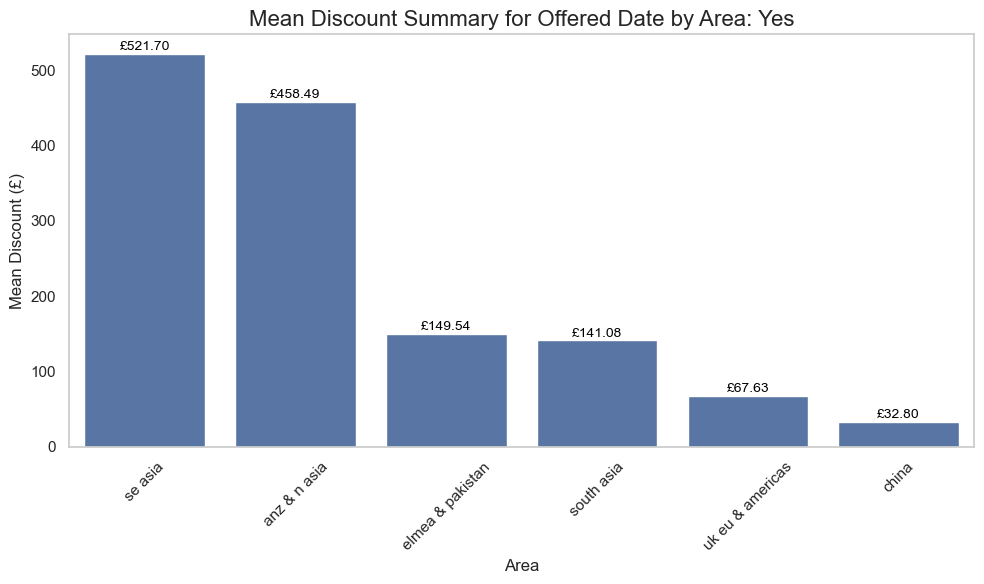

In [896]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the 'mean' values back to numeric for plotting
offered_yes_a_sorted['mean'] = offered_yes_a_sorted['mean'].replace({'£': '', ',': ''}, regex=True).astype(float)

# Create a bar plot for the mean discount by area for 'Yes' offered_date
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=offered_yes_a_sorted.index.get_level_values('area'), y=offered_yes_a_sorted['mean'])

# Set plot labels and title
plt.title('Mean Discount Summary for Offered Date by Area: Yes', fontsize=16)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Mean Discount (£)', fontsize=12)
plt.xticks(rotation=45)  # Rotate the area labels if needed for better readability

# Remove gridlines
ax.grid(False)

# Add the mean value on top of each bar
for p in ax.patches:
    ax.annotate(f'£{p.get_height():,.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')

# Display the plot
plt.tight_layout()
plt.show()

**Show the distribution of sum and average of the discounts provided to the unique applicants who received an offer to study by region?**

In [898]:
# Group by 'offered_date' and 'region', and calculate sum and average of the 'discount'
discount_by_region_and_offer = sgdata_copy_a.groupby(['offered_date', 'region'])['discount'].agg(['sum', 'mean'])

# Separate the "Yes" and "No" offered_date groups
offered_yes_r = discount_by_region_and_offer[discount_by_region_and_offer.index.get_level_values('offered_date') == 'yes']
offered_no_r = discount_by_region_and_offer[discount_by_region_and_offer.index.get_level_values('offered_date') == 'no']

# Sort by 'mean' for both categories (yes and no)
offered_yes_r_sorted = offered_yes_r.sort_values(by='mean', ascending=False)
offered_no_r_sorted = offered_no_r.sort_values(by='mean', ascending=False)

# Format the results for better readability
offered_yes_r_sorted['sum'] = offered_yes_r_sorted['sum'].apply(lambda x: f"£{x:,.2f}")
offered_yes_r_sorted['mean'] = offered_yes_r_sorted['mean'].apply(lambda x: f"£{x:,.2f}" if not pd.isna(x) else "£0.00")

offered_no_r_sorted['sum'] = offered_no_r_sorted['sum'].apply(lambda x: f"£{x:,.2f}")
offered_no_r_sorted['mean'] = offered_no_r_sorted['mean'].apply(lambda x: f"£{x:,.2f}" if not pd.isna(x) else "£0.00")

# Print the results separately
print("Discount Summary for Offered Date: Yes")
print(offered_yes_r_sorted)

print("\nDiscount Summary for Offered Date: No")
print(offered_no_r_sorted)

Discount Summary for Offered Date: Yes
                                                    sum     mean
offered_date region                                             
yes          north asia                     £467,400.00  £606.23
             se asia 2                      £553,728.00  £586.58
             hong kong                      £597,500.00  £416.09
             se asia 1                      £181,350.00  £390.00
             russia, e europe, c asia        £74,700.00  £329.07
             pakistan                     £1,408,678.00  £266.69
             rest of s asia                 £156,610.00  £192.16
             s europe, levant & n africa    £403,650.00  £140.84
             india                          £578,838.00  £131.61
             na & lam                        £85,500.00  £115.70
             anz                             £14,850.00  £100.34
             rest of africa                  £44,400.00   £86.38
             middle east                    £659,30

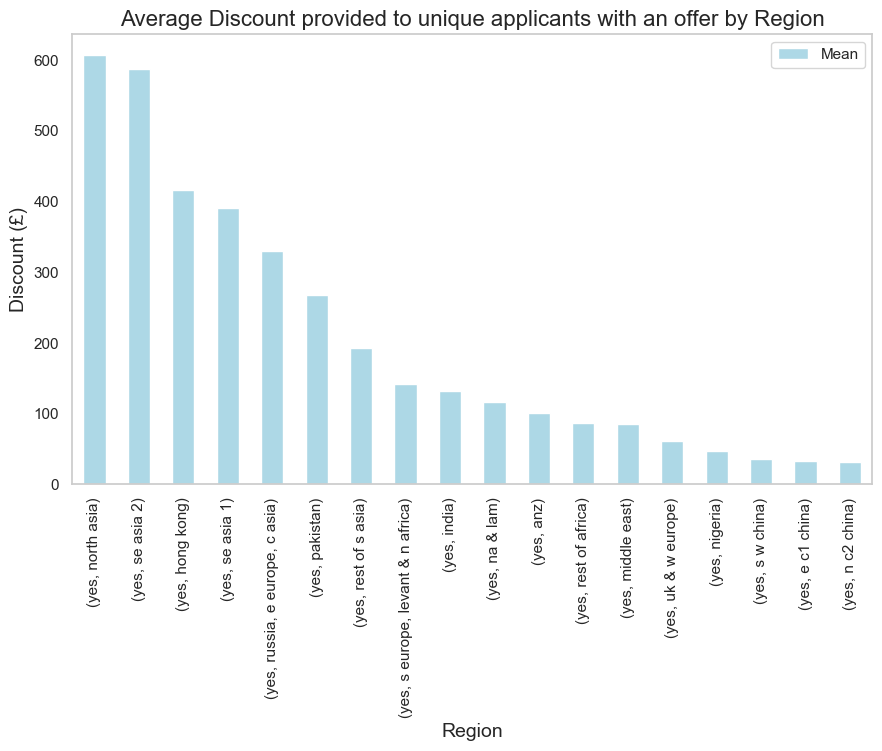

In [900]:
import matplotlib.pyplot as plt

# Plotting the bar chart 
plt.figure(figsize=(10, 6))

# Convert the 'mean' column from string to float for proper sorting
mean_discount_values = offered_yes_r_sorted['mean'].apply(
    lambda x: float(x.replace('£', '').replace(',', ''))
)

# Create a bar plot for the mean of the discount
ax_mean_yes = mean_discount_values.plot(kind='bar', color='lightblue', label='Mean')

# Add labels and title
plt.title('Average Discount provided to unique applicants with an offer by Region', fontsize=16)
plt.xlabel('Region', fontsize=14)
plt.ylabel('Discount (£)', fontsize=14)

# Remove the grid
plt.grid(False)

# Customize legend
plt.legend()

# Adjust the layout and margins
plt.subplots_adjust(bottom=0.2, top=0.95, left=0.1, right=0.9)

# Show plot
plt.show()

**Show the distribution of sum and average of the discounts provided to the unique applicants who received an offer to study by Sub-Region.**

In [902]:
# Group by 'offered_date' and 'sub_region', and calculate sum and average of the 'discount'
discount_by_sub_region_and_offer = sgdata_copy_a.groupby(['offered_date', 'sub_region'])['discount'].agg(['sum', 'mean'])

# Separate the "Yes" and "No" offered_date groups
offered_yes = discount_by_sub_region_and_offer[discount_by_sub_region_and_offer.index.get_level_values('offered_date') == 'yes']
offered_no = discount_by_sub_region_and_offer[discount_by_sub_region_and_offer.index.get_level_values('offered_date') == 'no']

# Sort by 'mean' for both categories (yes and no)
offered_yes_sorted = offered_yes.sort_values(by='mean', ascending=False)
offered_no_sorted = offered_no.sort_values(by='mean', ascending=False)

# Format the results for better readability
offered_yes_sorted['sum'] = offered_yes_sorted['sum'].apply(lambda x: f"£{x:,.2f}")
offered_yes_sorted['mean'] = offered_yes_sorted['mean'].apply(lambda x: f"£{x:,.2f}" if not pd.isna(x) else "£0.00")

offered_no_sorted['sum'] = offered_no_sorted['sum'].apply(lambda x: f"£{x:,.2f}")
offered_no_sorted['mean'] = offered_no_sorted['mean'].apply(lambda x: f"£{x:,.2f}" if not pd.isna(x) else "£0.00")

# Print the results separately
print("Discount Summary for Offered Date: Yes")
print(offered_yes_sorted)

print("\nDiscount Summary for Offered Date: No")
print(offered_no_sorted)

Discount Summary for Offered Date: Yes
                                                sum       mean
offered_date sub_region                                       
yes          korea                      £167,100.00  £1,037.89
             myanmar                    £299,228.00    £959.06
             bangladesh                  £97,860.00    £631.35
             eastern europe              £44,700.00    £580.52
             taiwan                     £245,300.00    £557.50
             vietnam                     £87,000.00    £537.04
             indonesia                   £64,500.00    £503.91
             malaysia, brunei           £107,500.00    £479.91
             cambodia, laos               £9,500.00    £475.00
             hong kong                  £597,500.00    £416.09
             japan                       £55,000.00    £323.53
             singapore                   £76,000.00    £308.94
             thailand                    £84,850.00    £299.82
             pak

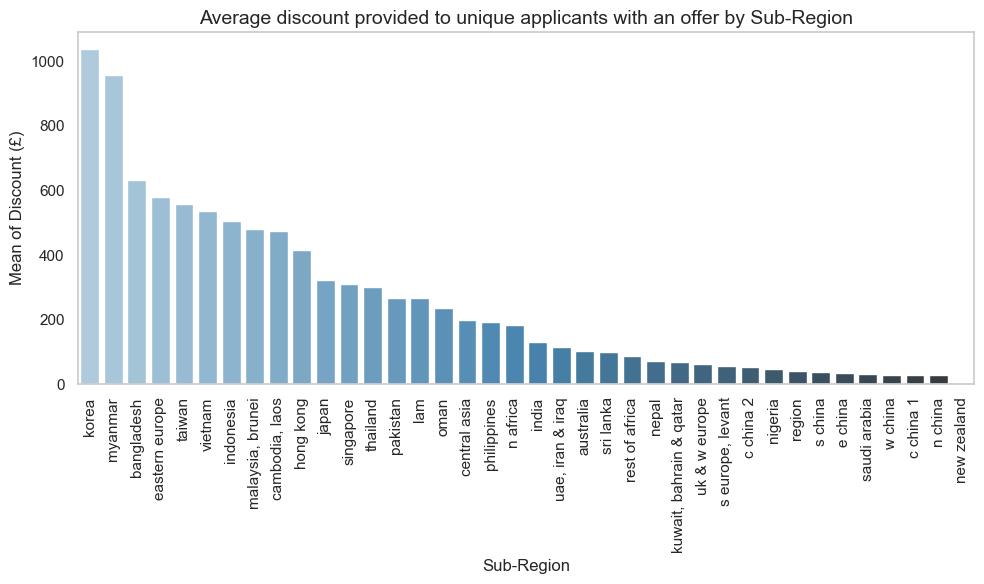

In [904]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the mean discount values for "Yes" offers and remove the currency symbols for numeric calculation
offered_yes_sorted['mean_numeric'] = offered_yes_sorted['mean'].str.replace('£', '').str.replace(',', '').astype(float)

# Plotting the bar chart 
plt.figure(figsize=(10, 6))
sns.barplot(x=offered_yes_sorted.index.get_level_values('sub_region'),
            y=offered_yes_sorted['mean_numeric'],
            palette="Blues_d")

# Title and labels
plt.title('Average discount provided to unique applicants with an offer by Sub-Region', fontsize=14)
plt.xlabel('Sub-Region', fontsize=12)
plt.ylabel('Mean of Discount (£)', fontsize=12)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)

# Remove gridlines
plt.grid(False)

# Adjust layout for better display
plt.tight_layout()

# Display the plot
plt.show()

**Show the distribution of sum and average of the discounts provided to the unique applicants who received an offer to study by Nationality.**

In [906]:
# Group by 'offered_date' and 'nationality', and calculate sum and average of the 'discount'
discount_by_nationality_and_offer = sgdata_copy_a.groupby(['offered_date', 'nationality'])['discount'].agg(['sum', 'mean'])

# Separate the "Yes" and "No" offered_date groups
offered_yes = discount_by_nationality_and_offer[discount_by_nationality_and_offer.index.get_level_values('offered_date') == 'yes']
offered_no = discount_by_nationality_and_offer[discount_by_nationality_and_offer.index.get_level_values('offered_date') == 'no']

# Sort by 'mean' for both categories (yes and no) and get the top 30
offered_yes_sorted = offered_yes.sort_values(by='mean', ascending=False).head(30)
offered_no_sorted = offered_no.sort_values(by='mean', ascending=False).head(30)

# Format the results for better readability
offered_yes_sorted['sum'] = offered_yes_sorted['sum'].apply(lambda x: f"£{x:,.2f}")
offered_yes_sorted['mean'] = offered_yes_sorted['mean'].apply(lambda x: f"£{x:,.2f}" if not pd.isna(x) else "£0.00")

offered_no_sorted['sum'] = offered_no_sorted['sum'].apply(lambda x: f"£{x:,.2f}")
offered_no_sorted['mean'] = offered_no_sorted['mean'].apply(lambda x: f"£{x:,.2f}" if not pd.isna(x) else "£0.00")

# Print the results separately
print("Top 30 Discount Summary for Offered Date: Yes")
print(offered_yes_sorted)

print("\nTop 30 Discount Summary for Offered Date: No")
print(offered_no_sorted)

Top 30 Discount Summary for Offered Date: Yes
                                        sum       mean
offered_date nationality                              
yes          korean             £166,600.00  £1,009.70
             st. lucian           £2,000.00  £1,000.00
             honduran             £3,000.00  £1,000.00
             myanmarian         £318,228.00    £947.11
             colombian           £16,900.00    £938.89
             cambodian           £12,500.00    £833.33
             greek                £5,000.00    £833.33
             malawian             £1,500.00    £750.00
             ukrainian           £39,700.00    £735.19
             sierra leonean       £5,000.00    £714.29
             swiss                £5,000.00    £714.29
             guatemalan           £5,000.00    £625.00
             bangladeshi        £111,500.00    £609.29
             venezuelan           £9,650.00    £567.65
             vietnamese          £98,000.00    £563.22
             botswa

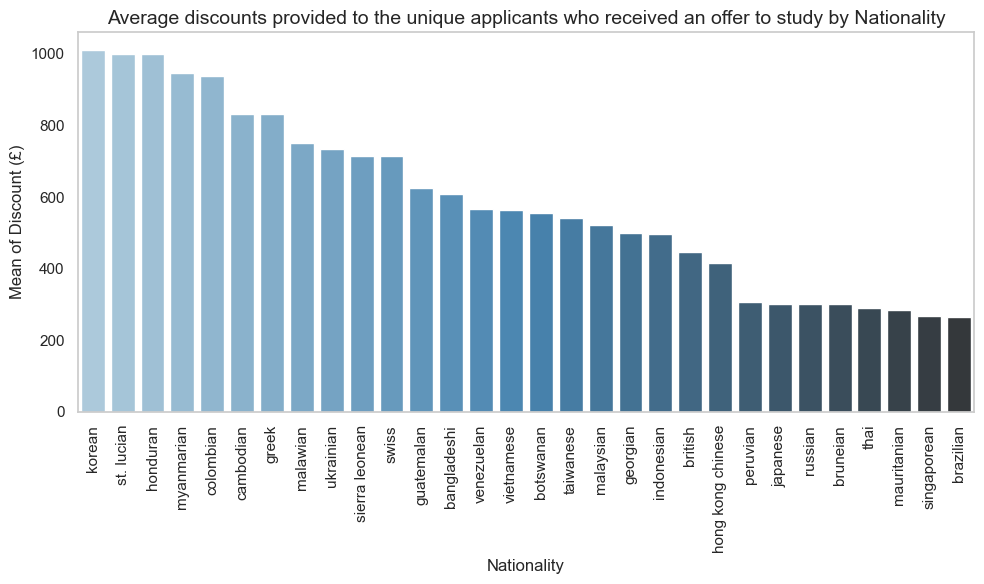

In [908]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot 
plt.figure(figsize=(10, 6))
sns.barplot(x=offered_yes_sorted.index.get_level_values('nationality'),
            y=offered_yes_sorted['mean'].str.replace('£', '').str.replace(',', '').astype(float),
            palette="Blues_d")

plt.title('Average discounts provided to the unique applicants who received an offer to study by Nationality', fontsize=14)
plt.ylabel('Mean of Discount (£)', fontsize=12)
plt.xlabel('Nationality', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Remove gridlines
plt.grid(False)

plt.tight_layout()
plt.show()

In [910]:
# Average Discount provided to Chinese Nationality with an offer.
# Filter the data for Chinese nationality
chinese_nationality_data = sgdata_copy_a[sgdata_copy_a['nationality'] == 'chinese']

# Group by 'offered_date' and calculate the sum and mean of the 'discount'
discount_by_chinese_nationality = chinese_nationality_data.groupby(['offered_date'])['discount'].agg(['sum', 'mean'])

# Format the results for better readability
discount_by_chinese_nationality['sum'] = discount_by_chinese_nationality['sum'].apply(lambda x: f"£{x:,.2f}")
discount_by_chinese_nationality['mean'] = discount_by_chinese_nationality['mean'].apply(lambda x: f"£{x:,.2f}" if not pd.isna(x) else "£0.00")

# Print the results
print("Discount Summary for Chinese Nationality by Offered Date:")
print(discount_by_chinese_nationality)

Discount Summary for Chinese Nationality by Offered Date:
                      sum    mean
offered_date                     
no              £3,235.00   £1.77
yes           £404,770.00  £36.91


**Change the discount column values into 'yes' and 'no' for further analysis.**

In [912]:
# First, Create a copy of the dataframe
sgdata_copy_2 = sgdata_copy_a.copy()

# View the output
print(sgdata_copy_2.head())

    centre programme          area     region sub_region agent_location  \
0  cardiff   diploma  anz & n asia        anz  australia      aus - vic   
1  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
2  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
3  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
4  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   

  branch_urn group_urn             lead_source  student_id  ...  \
0     a31552    a31552  standard agent booking     2864317  ...   
1     a15382    a29520  standard agent booking     2853769  ...   
2     a15382    a29520  standard agent booking     2863293  ...   
3      a7608     a7608  standard agent booking     2854643  ...   
4      d1107     d1107  standard agent booking     2871048  ...   

   confirmation_date arrived_date cancellation_date  completed progressed  \
0      not specified           no        10/05/2023         no       

**Change the values in the discount column as 'yes' and 'no'**

In [914]:
# Check the data types of discount column
print(sgdata_copy_2['discount'].dtypes)
print(sgdata_copy_2['discount'].head())

float64
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: discount, dtype: float64


In [916]:
# Ensure that all values in the 'discount' column are numeric, then change based on value
sgdata_copy_2['discount'] = pd.to_numeric(sgdata_copy_2['discount'], errors='coerce')

# Change the values in the 'discount' column to 'yes', and '0' or '0.0' to 'no'
sgdata_copy_2['discount'] = sgdata_copy_2['discount'].apply(lambda x: 'no' if x == 0 else 'yes')

print(sgdata_copy_2['discount'])

0        no
1        no
2        no
3        no
4        no
         ..
71749    no
71750    no
71751    no
71752    no
71753    no
Name: discount, Length: 71754, dtype: object


In [918]:
# Check the data types of offered_date column
print(sgdata_copy_2['offered_date'].dtypes)
print(sgdata_copy_2['offered_date'].head())

object
0     no
1    yes
2    yes
3     no
4    yes
Name: offered_date, dtype: object


**Find the total number of unique applicants who received an offer with discount.**

In [920]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer with 'Yes' in offered_date
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] == 'yes']

# Count the total number of unique applicants (who received an offer with 'Yes')
total_unique_applicants = applicants_with_offer['student_id'].nunique()

# Filter applicants who received an offer with a 'Yes' discount
applicants_with_discount_yes = applicants_with_offer[applicants_with_offer['discount'] == 'yes']

# Filter applicants who received an offer with a 'No' discount
applicants_with_discount_no = applicants_with_offer[applicants_with_offer['discount'] == 'no']

# Count the total unique applicants who received an offer with a 'Yes' discount
unique_applicants_with_discount_yes = applicants_with_discount_yes['student_id'].nunique()

# Count the total unique applicants who received an offer with a 'No' discount
unique_applicants_with_discount_no = applicants_with_discount_no['student_id'].nunique()

# Output the results
print(f"Total number of unique applicants who received an offer: {total_unique_applicants}")
print(f"Total number of unique applicants who received an offer with discount (Yes): {unique_applicants_with_discount_yes}")
print(f"Total number of unique applicants who received an offer with discount (No): {unique_applicants_with_discount_no}")

Total number of unique applicants who received an offer: 27202
Total number of unique applicants who received an offer with discount (Yes): 1590
Total number of unique applicants who received an offer with discount (No): 25612


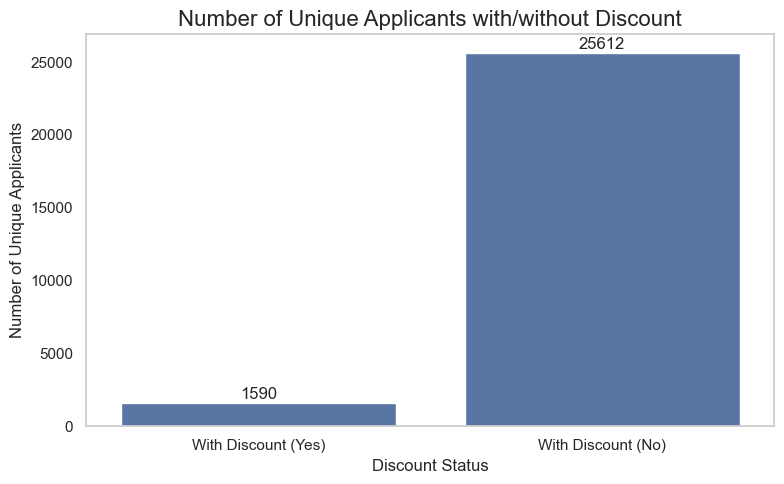

In [922]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for visualization
labels = ['With Discount (Yes)', 'With Discount (No)']
values = [unique_applicants_with_discount_yes, unique_applicants_with_discount_no]

# Create a bar plot for the number of applicants with/without discount
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=labels, y=values)

# Set plot labels and title
plt.title('Number of Unique Applicants with/without Discount', fontsize=16)
plt.xlabel('Discount Status', fontsize=12)
plt.ylabel('Number of Unique Applicants', fontsize=12)

# Display the count labels on top of each bar
for i, value in enumerate(values):
    plt.text(i, value + 50, str(value), ha='center', va='bottom', fontsize=12)

# Remove gridlines
ax.grid(False)

# Display the plot
plt.tight_layout()
plt.show()

In [924]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Get the unique applicants who received an offer with 'Yes' in offered_date
applicants_with_offer = unique_applicants[
    unique_applicants['offered_date'] == 'yes'
]

# Count the total number of unique applicants (who received an offer with 'Yes')
total_unique_applicants = applicants_with_offer['student_id'].nunique()

# Filter applicants who received an offer with a 'Yes' discount
applicants_with_discount_yes = applicants_with_offer[
    applicants_with_offer['discount'] == 'yes'
]

# Filter applicants who received an offer with a 'No' discount
applicants_with_discount_no = applicants_with_offer[
    applicants_with_offer['discount'] == 'no'
]

# Count the total unique applicants who received an offer with a 'Yes' discount
unique_applicants_with_discount_yes = applicants_with_discount_yes[
    'student_id'].nunique()

# Count the total unique applicants who received an offer with a 'No' discount
unique_applicants_with_discount_no = applicants_with_discount_no[
    'student_id'].nunique()

# Calculate the percentages
percentage_with_discount_yes = (
    (unique_applicants_with_discount_yes / total_unique_applicants) * 100
)
percentage_with_discount_no = (
    (unique_applicants_with_discount_no / total_unique_applicants) * 100
)

# Output the results in percentages
print(f"Total number of unique applicants who received an offer: "
      f"{total_unique_applicants}")
print(f"Total number of unique applicants who received an offer with discount "
      f"(Yes): {unique_applicants_with_discount_yes} "
      f"({percentage_with_discount_yes:.2f}%)")
print(f"Total number of unique applicants who received an offer with discount "
      f"(No): {unique_applicants_with_discount_no} "
      f"({percentage_with_discount_no:.2f}%)")

Total number of unique applicants who received an offer: 27202
Total number of unique applicants who received an offer with discount (Yes): 1590 (5.85%)
Total number of unique applicants who received an offer with discount (No): 25612 (94.15%)


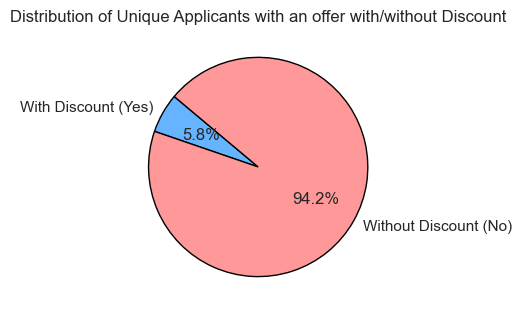

In [926]:
import matplotlib.pyplot as plt

# Data for the pie chart
labels = ['With Discount (Yes)', 'Without Discount (No)']
sizes = [unique_applicants_with_discount_yes, unique_applicants_with_discount_no]

# Define the colors for the chart
colors = ['#66b3ff', '#ff9999']

# Create the pie chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})

# Set the title of the chart
plt.title('Distribution of Unique Applicants with an offer with/without Discount')

# Display the chart
plt.tight_layout()
plt.show()

**How many unique enrolled students received discounts?**

In [928]:
# Ensure no duplicates, each student should only be counted once
unique_enrolled_students = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter enrolled students who received a discount
enrolled_with_discount = unique_enrolled_students[
    (unique_enrolled_students['discount'] == 'yes') &
    (unique_enrolled_students['arrived_date'] == 'yes')]

# Filter enrolled students who did not receive a discount
enrolled_without_discount = unique_enrolled_students[
    (unique_enrolled_students['discount'] == 'no') &
    (unique_enrolled_students['arrived_date'] == 'yes')]

# Count the total unique enrolled students who received a discount
unique_enrolled_with_discount = enrolled_with_discount['student_id'].nunique()

# Count the total unique enrolled students who did not receive a discount
unique_enrolled_without_discount = enrolled_without_discount['student_id'].nunique()

# Count the total unique enrolled students
total_unique_enrolled_students = unique_enrolled_students[
    unique_enrolled_students['arrived_date'] == 'yes'].shape[0]

# Output the results
print(f"Total number of unique enrolled students who received a discount: {unique_enrolled_with_discount}")
print(f"Total number of unique enrolled students who did not receive a discount: {unique_enrolled_without_discount}")
print(f"Total number of unique enrolled students: {total_unique_enrolled_students}")

Total number of unique enrolled students who received a discount: 1121
Total number of unique enrolled students who did not receive a discount: 1596
Total number of unique enrolled students: 2717


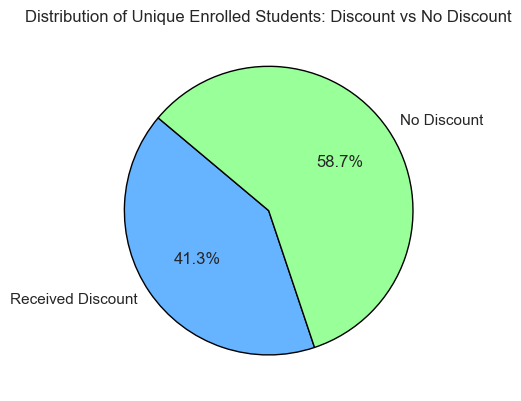

In [930]:
import matplotlib.pyplot as plt

# Data for pie chart
labels = ['Received Discount', 'No Discount']
sizes = [unique_enrolled_with_discount, unique_enrolled_without_discount]

# Define colors for the pie chart
colors = ['#66b3ff', '#99ff99']

# Create a pie chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})

# Set the title of the chart
plt.title('Distribution of Unique Enrolled Students: Discount vs No Discount')

# Show the plot
plt.tight_layout()
plt.show()

**What is the conversion rate of students with an Offer and Discount: Enrolled vs Not Enrolled?**

In [932]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer with a 'Yes' discount
applicants_with_discount_yes = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') &
    (unique_applicants['discount'] == 'yes')
]

# Filter applicants who enrolled after receiving an offer with a 'Yes' discount
enrolled_with_discount = applicants_with_discount_yes[applicants_with_discount_yes['arrived_date'] == 'yes']

# Filter applicants who did not enroll after receiving an offer with a 'Yes' discount
not_enrolled_with_discount = applicants_with_discount_yes[applicants_with_discount_yes['arrived_date'] != 'yes']

# Count the total unique applicants who enrolled after receiving an offer with a discount
unique_enrolled_with_discount = enrolled_with_discount['student_id'].nunique()

# Count the total unique applicants who did not enroll after receiving an offer with a discount
unique_not_enrolled_with_discount = not_enrolled_with_discount['student_id'].nunique()

# Output the results
print(f"Total number of unique students who received an offer with a discount and enrolled: {unique_enrolled_with_discount}")
print(f"Total number of unique students who received an offer with a discount and did not enroll: {unique_not_enrolled_with_discount}")

Total number of unique students who received an offer with a discount and enrolled: 1121
Total number of unique students who received an offer with a discount and did not enroll: 469


In [934]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer with a 'Yes' discount
applicants_with_discount_yes = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') &
    (unique_applicants['discount'] == 'yes')
]

# Filter applicants who enrolled after receiving an offer with a 'Yes' discount
enrolled_with_discount = applicants_with_discount_yes[applicants_with_discount_yes['arrived_date'] == 'yes']

# Filter applicants who did not enroll after receiving an offer with a 'Yes' discount
not_enrolled_with_discount = applicants_with_discount_yes[applicants_with_discount_yes['arrived_date'] != 'yes']

# Count the total unique applicants who received an offer with a discount
total_applicants_with_discount = applicants_with_discount_yes['student_id'].nunique()

# Count the total unique applicants who enrolled after receiving an offer with a discount
unique_enrolled_with_discount = enrolled_with_discount['student_id'].nunique()

# Count the total unique applicants who did not enroll after receiving an offer with a discount
unique_not_enrolled_with_discount = not_enrolled_with_discount['student_id'].nunique()

# Calculate percentages
percentage_enrolled = (unique_enrolled_with_discount / total_applicants_with_discount) * 100
percentage_not_enrolled = (unique_not_enrolled_with_discount / total_applicants_with_discount) * 100

# Output the results in percentages
print(f"Total number of unique students who received an offer with a discount and enrolled: "
      f"{unique_enrolled_with_discount} ({percentage_enrolled:.2f}%)")
print(f"Total number of unique students who received an offer with a discount and did not enroll: "
      f"{unique_not_enrolled_with_discount} ({percentage_not_enrolled:.2f}%)")

Total number of unique students who received an offer with a discount and enrolled: 1121 (70.50%)
Total number of unique students who received an offer with a discount and did not enroll: 469 (29.50%)


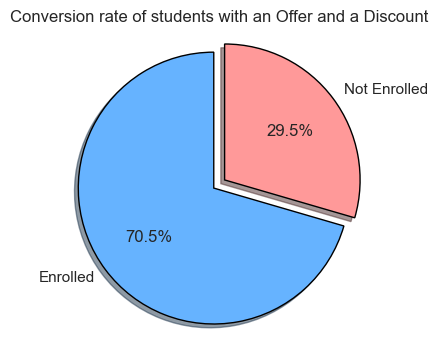

In [936]:
import matplotlib.pyplot as plt

# Data for pie chart
labels = ['Enrolled', 'Not Enrolled']
sizes = [unique_enrolled_with_discount, unique_not_enrolled_with_discount]

# Define explode effect to highlight 'Enrolled'
explode = (0.1, 0)  

# Create the pie chart with explode effect
fig, ax = plt.subplots(figsize=(4, 4)) 
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
       colors=['#66b3ff', '#ff9999'], wedgeprops={'edgecolor': 'black'}, explode=explode, 
       shadow=True)  

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

# Title for the chart
plt.title('Conversion rate of students with an Offer and a Discount')

# Show the plot
plt.show()

**What is the conversion rate of students with an Offer but No Discount: Enrolled vs Not Enrolled?**

In [938]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer but no discount
applicants_with_offer_no_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') &
    (unique_applicants['discount'] == 'no')
]

# Filter applicants who enrolled after receiving an offer but no discount
enrolled_with_no_discount = applicants_with_offer_no_discount[applicants_with_offer_no_discount['arrived_date'] == 'yes']

# Filter applicants who did not enroll after receiving an offer but no discount
not_enrolled_with_no_discount = applicants_with_offer_no_discount[applicants_with_offer_no_discount['arrived_date'] != 'yes']

# Count the total unique applicants who enrolled after receiving an offer but no discount
unique_enrolled_with_no_discount = enrolled_with_no_discount['student_id'].nunique()

# Count the total unique applicants who did not enroll after receiving an offer but no discount
unique_not_enrolled_with_no_discount = not_enrolled_with_no_discount['student_id'].nunique()

# Output the results
print(f"Total number of unique students who received an offer but no discount and enrolled: {unique_enrolled_with_no_discount}")
print(f"Total number of unique students who received an offer but no discount and did not enroll: {unique_not_enrolled_with_no_discount}")

Total number of unique students who received an offer but no discount and enrolled: 1596
Total number of unique students who received an offer but no discount and did not enroll: 24016


In [940]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer but no discount
applicants_with_offer_no_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') &
    (unique_applicants['discount'] == 'no')
]

# Filter applicants who enrolled after receiving an offer but no discount
enrolled_with_no_discount = applicants_with_offer_no_discount[applicants_with_offer_no_discount['arrived_date'] == 'yes']

# Filter applicants who did not enroll after receiving an offer but no discount
not_enrolled_with_no_discount = applicants_with_offer_no_discount[applicants_with_offer_no_discount['arrived_date'] != 'yes']

# Count the total unique applicants who received an offer but no discount
total_unique_applicants_with_no_discount = applicants_with_offer_no_discount['student_id'].nunique()

# Count the total unique applicants who enrolled after receiving an offer but no discount
unique_enrolled_with_no_discount = enrolled_with_no_discount['student_id'].nunique()

# Count the total unique applicants who did not enroll after receiving an offer but no discount
unique_not_enrolled_with_no_discount = not_enrolled_with_no_discount['student_id'].nunique()

# Calculate the percentages
percentage_enrolled_with_no_discount = (
    (unique_enrolled_with_no_discount / total_unique_applicants_with_no_discount) * 100
)

percentage_not_enrolled_with_no_discount = (
    (unique_not_enrolled_with_no_discount / total_unique_applicants_with_no_discount) * 100
)

# Output the results in percentages
print(f"Total number of unique students who received an offer but no discount: {total_unique_applicants_with_no_discount}")
print(f"Total number of unique students who received an offer but no discount and enrolled: "
      f"{unique_enrolled_with_no_discount} ({percentage_enrolled_with_no_discount:.2f}%)")
print(f"Total number of unique students who received an offer but no discount and did not enroll: "
      f"{unique_not_enrolled_with_no_discount} ({percentage_not_enrolled_with_no_discount:.2f}%)")

Total number of unique students who received an offer but no discount: 25612
Total number of unique students who received an offer but no discount and enrolled: 1596 (6.23%)
Total number of unique students who received an offer but no discount and did not enroll: 24016 (93.77%)


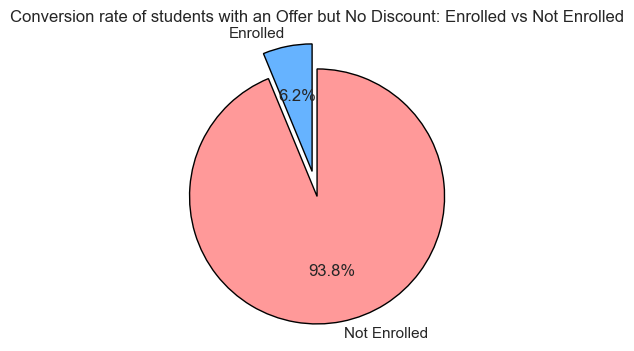

In [942]:
import matplotlib.pyplot as plt

# Data for pie chart
labels = ['Enrolled', 'Not Enrolled']
sizes = [unique_enrolled_with_no_discount, unique_not_enrolled_with_no_discount]
percentages = [percentage_enrolled_with_no_discount, percentage_not_enrolled_with_no_discount]

# Define explode effect to highlight 'Enrolled'
explode = (0.2, 0)  

# Create the pie chart with explode effect
fig, ax = plt.subplots(figsize=(4, 4))  # Corrected the parenthesis here
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, 
       colors=['#66b3ff','#ff9999'], wedgeprops={'edgecolor': 'black'}, explode=explode)

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

# Title for the chart
plt.title('Conversion rate of students with an Offer but No Discount: Enrolled vs Not Enrolled')

# Show the plot
plt.show()

**How many discounts are provided?**

In [944]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer (offered_date == 'yes')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] == 'yes']

# Filter applicants who received a discount ("yes" in the discount column)
applicants_with_discount = applicants_with_offer[applicants_with_offer['discount'] == 'yes']

# Count the number of unique applicants who received a discount
total_discounted_applicants = applicants_with_discount['student_id'].nunique()

# Output the total number of unique applicants who received a discount
print(f"Total Number of Unique Applicants Who Received a Discount: {total_discounted_applicants}")

Total Number of Unique Applicants Who Received a Discount: 1590


**How is discount allocated by area?**

In [946]:
# Count of discount provided by area to unique applicants with an offer.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer (offered_date == 'yes')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] == 'yes']

# Filter applicants who received a discount ("yes" in the discount column)
applicants_with_discount = applicants_with_offer[applicants_with_offer['discount'] == 'yes']

# Group by 'area' and count the unique 'student_id' who received a discount
discount_by_area = applicants_with_discount.groupby('area')['student_id'].nunique()

# Output the result
print("Total Number of Unique Applicants Who Received a Discount by Area:")
print(discount_by_area)

Total Number of Unique Applicants Who Received a Discount by Area:
area
anz & n asia        213
china               199
elmea & pakistan    586
se asia             181
south asia          166
uk eu & americas    245
Name: student_id, dtype: int64


In [952]:
# Discount provided to unique applicants with an offer by area in percentages.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer (offered_date == 'yes')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] == 'yes']

# Filter applicants who received a discount ("yes" in the discount column)
applicants_with_discount = applicants_with_offer[applicants_with_offer['discount'] == 'yes']

# Group by 'area' and count the unique 'student_id' who received a discount
discount_by_area = applicants_with_discount.groupby('area')['student_id'].nunique()

# Calculate the total number of unique applicants who received a discount
total_discount_applicants = applicants_with_discount['student_id'].nunique()

# Calculate the percentage of unique applicants who received a discount by area
discount_percentage_by_area = (discount_by_area / total_discount_applicants) * 100

# Sort by percentage in descending order
discount_percentage_by_area_sorted = discount_percentage_by_area.sort_values(ascending=False)

# Output the result in percentages
print("Sorted Percentage of Unique Applicants Who Received a Discount by Area:")
print(discount_percentage_by_area_sorted)

Sorted Percentage of Unique Applicants Who Received a Discount by Area:
area
elmea & pakistan    36.855346
uk eu & americas    15.408805
anz & n asia        13.396226
china               12.515723
se asia             11.383648
south asia          10.440252
Name: student_id, dtype: float64


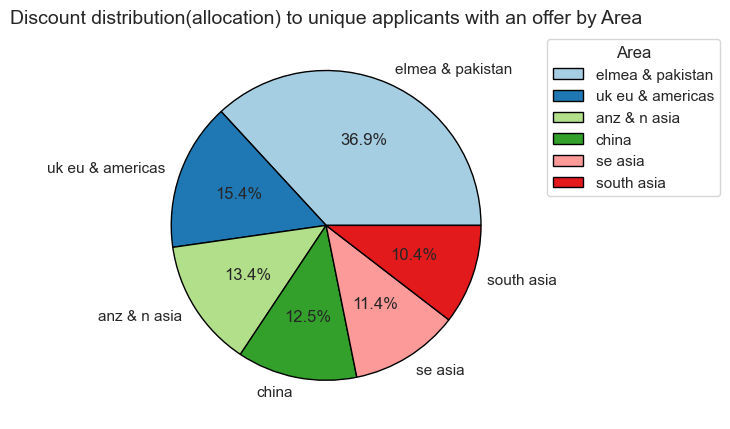

In [960]:
# Discount distribution(allocation) to unique applicants with an offer by Area.
import matplotlib.pyplot as plt

# Plotting the pie chart for discount percentage by area
plt.figure(figsize=(7, 7))
plt.pie(discount_percentage_by_area_sorted,
        labels=discount_percentage_by_area_sorted.index,
        autopct='%1.1f%%', colors=plt.cm.Paired.colors, wedgeprops={'edgecolor': 'black'})

# Add a title
plt.title("Discount distribution(allocation) to unique applicants with an offer by Area", fontsize=14)

# Add the legend outside the chart
plt.legend(discount_percentage_by_area_sorted.index, title="Area", bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

**What is the conversion rate of unique applicants with an offer and discount by Area?**

In [973]:
# Find the Number of Unique Applicants Enrolled and Not Enrolled with Offer and Discount by Area
# Ensure no duplicates, each student is counted only once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer and a discount
applicants_with_offer_and_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') & 
    (unique_applicants['discount'] == 'yes')
]

# Filter applicants who enrolled after receiving an offer and discount
enrolled_with_offer_and_discount = applicants_with_offer_and_discount[
    applicants_with_offer_and_discount['arrived_date'] == 'yes'
]

# Filter applicants who did not enroll after receiving an offer and discount
not_enrolled_with_offer_and_discount = applicants_with_offer_and_discount[
    applicants_with_offer_and_discount['arrived_date'] != 'yes'
]

# Count the number of unique applicants who enrolled with offer and discount by area
enrolled_with_offer_and_discount_by_area = enrolled_with_offer_and_discount.groupby('area')['student_id'].nunique()

# Count the number of unique applicants who did not enroll with offer and discount by area
not_enrolled_with_offer_and_discount_by_area = not_enrolled_with_offer_and_discount.groupby('area')['student_id'].nunique()

# Combine the counts into a single DataFrame
enrollment_status_by_area_offer_discount = pd.DataFrame({
    'Enrolled with Offer and Discount': enrolled_with_offer_and_discount_by_area,
    'Not Enrolled with Offer and Discount': not_enrolled_with_offer_and_discount_by_area
}).fillna(0)

# Print the results
print("Number of Unique Applicants Enrolled and Not Enrolled with Offer and Discount by Area:")
print(enrollment_status_by_area_offer_discount)

Number of Unique Applicants Enrolled and Not Enrolled with Offer and Discount by Area:
                  Enrolled with Offer and Discount  \
area                                                 
anz & n asia                                   154   
china                                          118   
elmea & pakistan                               439   
se asia                                        155   
south asia                                     106   
uk eu & americas                               149   

                  Not Enrolled with Offer and Discount  
area                                                    
anz & n asia                                        59  
china                                               81  
elmea & pakistan                                   147  
se asia                                             26  
south asia                                          60  
uk eu & americas                                    96  


In [966]:
# Find the Number of Unique Applicants Enrolled and Not Enrolled with Offer and Discount by Area
# Ensure no duplicates, each student is counted only once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer and a discount
applicants_with_offer_and_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') & 
    (unique_applicants['discount'] == 'yes')
]

# Filter applicants who enrolled after receiving an offer and discount
enrolled_with_offer_and_discount = applicants_with_offer_and_discount[
    applicants_with_offer_and_discount['arrived_date'] == 'yes'
]

# Filter applicants who did not enroll after receiving an offer and discount
not_enrolled_with_offer_and_discount = applicants_with_offer_and_discount[
    applicants_with_offer_and_discount['arrived_date'] != 'yes'
]

# Count the number of unique applicants who enrolled with offer and discount by area
enrolled_with_offer_and_discount_by_area = enrolled_with_offer_and_discount.groupby('area')['student_id'].nunique()

# Count the number of unique applicants who did not enroll with offer and discount by area
not_enrolled_with_offer_and_discount_by_area = not_enrolled_with_offer_and_discount.groupby('area')['student_id'].nunique()

# Count the total number of unique applicants with offer and discount by area
total_with_offer_and_discount_by_area = applicants_with_offer_and_discount.groupby('area')['student_id'].nunique()

# Calculate the percentage of enrolled and not enrolled with offer and discount by area
enrolled_percentage_by_area = (enrolled_with_offer_and_discount_by_area / total_with_offer_and_discount_by_area) * 100
not_enrolled_percentage_by_area = (not_enrolled_with_offer_and_discount_by_area / total_with_offer_and_discount_by_area) * 100

# Combine the counts and percentages into a single DataFrame
enrollment_status_by_area_offer_discount_percentage = pd.DataFrame({
    'Enrolled with Offer and Discount': enrolled_with_offer_and_discount_by_area,
    'Enrolled Percentage': enrolled_percentage_by_area,
    'Not Enrolled with Offer and Discount': not_enrolled_with_offer_and_discount_by_area,
    'Not Enrolled Percentage': not_enrolled_percentage_by_area
}).fillna(0)

# Sort the DataFrame by "Enrolled Percentage" in descending order
enrollment_status_by_area_offer_discount_percentage_sorted = enrollment_status_by_area_offer_discount_percentage.sort_values(
    by='Enrolled Percentage', ascending=False
)

# Print the sorted results
print("Sorted Number of Unique Applicants Enrolled and Not Enrolled with Offer and Discount by Area (with Percentages):")
print(enrollment_status_by_area_offer_discount_percentage_sorted)

Sorted Number of Unique Applicants Enrolled and Not Enrolled with Offer and Discount by Area (with Percentages):
                  Enrolled with Offer and Discount  Enrolled Percentage  \
area                                                                      
se asia                                        155            85.635359   
elmea & pakistan                               439            74.914676   
anz & n asia                                   154            72.300469   
south asia                                     106            63.855422   
uk eu & americas                               149            60.816327   
china                                          118            59.296482   

                  Not Enrolled with Offer and Discount  \
area                                                     
se asia                                             26   
elmea & pakistan                                   147   
anz & n asia                                        59

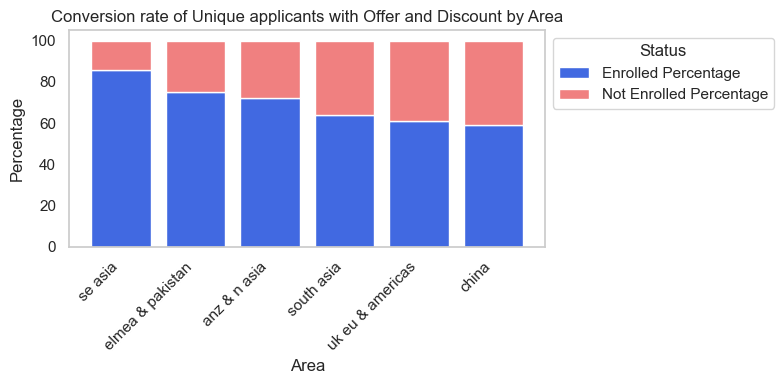

In [991]:
import matplotlib.pyplot as plt
import pandas as pd

# Plot the stacked bar chart
plt.figure(figsize=(8, 4))

# Create the bar chart with Enrolled and Not Enrolled Percentage
plt.bar(enrollment_status_by_area_offer_discount_percentage_sorted.index,
        enrollment_status_by_area_offer_discount_percentage_sorted['Enrolled Percentage'],
        label='Enrolled Percentage', color='royalblue')

plt.bar(enrollment_status_by_area_offer_discount_percentage_sorted.index,
        enrollment_status_by_area_offer_discount_percentage_sorted['Not Enrolled Percentage'],
        bottom=enrollment_status_by_area_offer_discount_percentage_sorted['Enrolled Percentage'],
        label='Not Enrolled Percentage', color='lightcoral')

# Add labels and title
plt.xlabel('Area', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.title('Conversion rate of Unique applicants with Offer and Discount by Area', fontsize=12)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

# Remove gridlines
plt.grid(False)

# Add legend outside the chart
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Status')

# Show the plot
plt.tight_layout()
plt.show()

**What is the conversion rate of unique applicants with an offer and No discount by Area?**

In [975]:
# Find the Number of Unique Applicants Enrolled and Not Enrolled with Offer and NO Discount by Area
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer and NO discount
applicants_with_offer_and_no_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') & 
    (unique_applicants['discount'] == 'no')
]

# Filter applicants who enrolled after receiving an offer and NO discount
enrolled_with_offer_and_no_discount = applicants_with_offer_and_no_discount[
    applicants_with_offer_and_no_discount['arrived_date'] == 'yes'
]

# Filter applicants who did not enroll after receiving an offer and NO discount
not_enrolled_with_offer_and_no_discount = applicants_with_offer_and_no_discount[
    applicants_with_offer_and_no_discount['arrived_date'] != 'yes'
]

# Count the number of unique applicants who enrolled with offer and no discount by area
enrolled_with_offer_and_no_discount_by_area = enrolled_with_offer_and_no_discount.groupby('area')['student_id'].nunique()

# Count the number of unique applicants who did not enroll with offer and no discount by area
not_enrolled_with_offer_and_no_discount_by_area = not_enrolled_with_offer_and_no_discount.groupby('area')['student_id'].nunique()

# Combine the counts into a single DataFrame
enrollment_status_by_area_offer_no_discount = pd.DataFrame({
    'Enrolled with Offer and No Discount': enrolled_with_offer_and_no_discount_by_area,
    'Not Enrolled with Offer and No Discount': not_enrolled_with_offer_and_no_discount_by_area
}).fillna(0)

# Print the results
print("Number of Unique Applicants Enrolled and Not Enrolled with Offer and No Discount by Area:")
print(enrollment_status_by_area_offer_no_discount)

Number of Unique Applicants Enrolled and Not Enrolled with Offer and No Discount by Area:
                  Enrolled with Offer and No Discount  \
area                                                    
anz & n asia                                       99   
china                                             729   
elmea & pakistan                                  328   
se asia                                            68   
south asia                                        123   
uk eu & americas                                  249   

                  Not Enrolled with Offer and No Discount  
area                                                       
anz & n asia                                         1113  
china                                                5638  
elmea & pakistan                                     7600  
se asia                                               701  
south asia                                           2977  
uk eu & americas                 

In [979]:
# Find the Number of Unique Applicants Enrolled and Not Enrolled with Offer and NO Discount by Area in percentages.
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer and NO discount
applicants_with_offer_and_no_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') & 
    (unique_applicants['discount'] == 'no')
]

# Filter applicants who enrolled after receiving an offer and NO discount
enrolled_with_offer_and_no_discount = applicants_with_offer_and_no_discount[
    applicants_with_offer_and_no_discount['arrived_date'] == 'yes'
]

# Filter applicants who did not enroll after receiving an offer and NO discount
not_enrolled_with_offer_and_no_discount = applicants_with_offer_and_no_discount[
    applicants_with_offer_and_no_discount['arrived_date'] != 'yes'
]

# Count the number of unique applicants who enrolled with offer and no discount by area
enrolled_with_offer_and_no_discount_by_area = enrolled_with_offer_and_no_discount.groupby('area')['student_id'].nunique()

# Count the number of unique applicants who did not enroll with offer and no discount by area
not_enrolled_with_offer_and_no_discount_by_area = not_enrolled_with_offer_and_no_discount.groupby('area')['student_id'].nunique()

# Calculate the total number of applicants (enrolled + not enrolled) by area
total_applicants_by_area = applicants_with_offer_and_no_discount.groupby('area')['student_id'].nunique()

# Calculate the percentages
enrolled_percentage_by_area = (enrolled_with_offer_and_no_discount_by_area / total_applicants_by_area) * 100
not_enrolled_percentage_by_area = (not_enrolled_with_offer_and_no_discount_by_area / total_applicants_by_area) * 100

# Combine the counts and percentages into a single DataFrame
enrollment_status_by_area_offer_no_discount_percentages = pd.DataFrame({
    'Enrolled with Offer and No Discount': enrolled_percentage_by_area,
    'Not Enrolled with Offer and No Discount': not_enrolled_percentage_by_area
}).fillna(0)

# Sort by 'Enrolled with Offer and No Discount' in descending order
enrollment_status_by_area_offer_no_discount_percentages_sorted = enrollment_status_by_area_offer_no_discount_percentages.sort_values(
    by='Enrolled with Offer and No Discount', ascending=False
)

# Print the sorted results
print("Percentage of Unique Applicants Enrolled and Not Enrolled with Offer and No Discount by Area (Sorted):")
print(enrollment_status_by_area_offer_no_discount_percentages_sorted)

Percentage of Unique Applicants Enrolled and Not Enrolled with Offer and No Discount by Area (Sorted):
                  Enrolled with Offer and No Discount  \
area                                                    
china                                       11.449662   
se asia                                      8.842653   
anz & n asia                                 8.168317   
elmea & pakistan                             4.137235   
uk eu & americas                             3.992944   
south asia                                   3.967742   

                  Not Enrolled with Offer and No Discount  
area                                                       
china                                           88.550338  
se asia                                         91.157347  
anz & n asia                                    91.831683  
elmea & pakistan                                95.862765  
uk eu & americas                                96.007056  
south asia          

<Figure size 800x400 with 0 Axes>

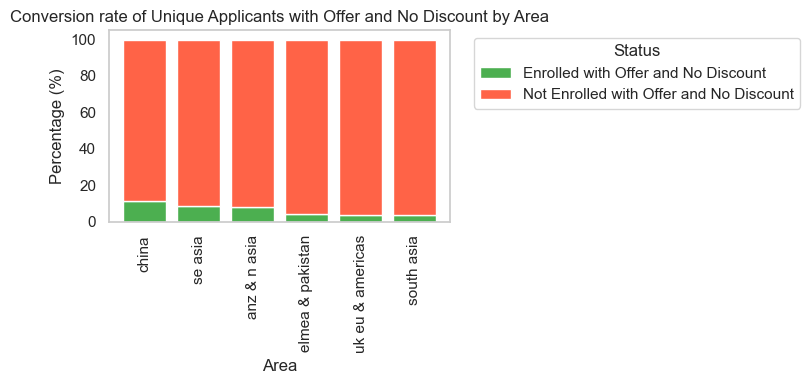

In [995]:
# Visualize the percentages of enrolled and not enrolled applicants by area
import matplotlib.pyplot as plt

# Create a stacked bar chart 
plt.figure(figsize=(8, 4))

# Plot Enrolled and Not Enrolled percentages as a stacked bar chart
enrollment_status_by_area_offer_no_discount_percentages_sorted.plot(
    kind='bar', 
    stacked=True, 
    figsize=(8, 4), 
    color=['#4CAF50', '#FF6347'],  
    width=0.8
)

# Remove gridlines
plt.grid(False)

# Set title and labels
plt.title('Conversion rate of Unique Applicants with Offer and No Discount by Area', fontsize=12)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Display legend outside the chart
plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to make room for the legend
plt.tight_layout()

# Display the plot
plt.show()

**How is discount distributed(allocated) by Nationality?**

In [1003]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer (offered_date == 'yes')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] == 'yes']

# Filter applicants who received a discount ("yes" in the discount column)
applicants_with_discount = applicants_with_offer[applicants_with_offer['discount'] == 'yes']

# Group by 'nationality' and count the unique 'student_id' who received a discount
discount_by_nationality = applicants_with_discount.groupby('nationality')['student_id'].nunique()

# Sort by the count of unique applicants in descending order and get the top 30
discount_by_nationality_sorted_top_30 = discount_by_nationality.sort_values(ascending=False).head(30)

# Output the sorted result
print("Top 30 Nationalities with the Most Unique Applicants receiving a Discount:")
print(discount_by_nationality_sorted_top_30)

Top 30 Nationalities with the Most Unique Applicants Who Received a Discount:
nationality
pakistani            352
chinese              214
indian               138
hong kong chinese    104
kuwaiti               90
egyptian              86
myanmarian            70
taiwanese             43
korean                42
omani                 37
vietnamese            32
algerian              30
saudi                 24
indonesian            21
malaysian             21
thai                  19
sri lankan            19
british               18
bangladeshi           14
jordanian             13
singaporean           13
emirati               13
moroccan              13
bahraini              13
nepalese              12
lebanese              10
nigerian              10
japanese               9
ukrainian              8
peruvian               7
Name: student_id, dtype: int64


In [1007]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer (offered_date == 'yes')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] == 'yes']

# Filter applicants who received a discount ("yes" in the discount column)
applicants_with_discount = applicants_with_offer[applicants_with_offer['discount'] == 'yes']

# Group by 'nationality' and count the unique 'student_id' who received a discount
discount_by_nationality = applicants_with_discount.groupby('nationality')['student_id'].nunique()

# Calculate the total number of applicants who received a discount
total_discount_applicants = applicants_with_discount['student_id'].nunique()

# Calculate the percentage for each nationality as a distribution of the discount total
discount_percentage_by_nationality = (discount_by_nationality / total_discount_applicants) * 100

# Sort by the percentage of unique applicants in descending order and get the top 30
discount_percentage_by_nationality_sorted_top_30 = discount_percentage_by_nationality.sort_values(ascending=False).head(30)

# Output the sorted result with percentages
print("Top 30 Nationalities with the Most Unique Applicants Who Received a Discount (as distribution of discount total):")
print(discount_percentage_by_nationality_sorted_top_30)

Top 30 Nationalities with the Most Unique Applicants Who Received a Discount (as distribution of discount total):
nationality
pakistani            22.138365
chinese              13.459119
indian                8.679245
hong kong chinese     6.540881
kuwaiti               5.660377
egyptian              5.408805
myanmarian            4.402516
taiwanese             2.704403
korean                2.641509
omani                 2.327044
vietnamese            2.012579
algerian              1.886792
saudi                 1.509434
indonesian            1.320755
malaysian             1.320755
thai                  1.194969
sri lankan            1.194969
british               1.132075
bangladeshi           0.880503
jordanian             0.817610
singaporean           0.817610
emirati               0.817610
moroccan              0.817610
bahraini              0.817610
nepalese              0.754717
lebanese              0.628931
nigerian              0.628931
japanese              0.566038
ukrain

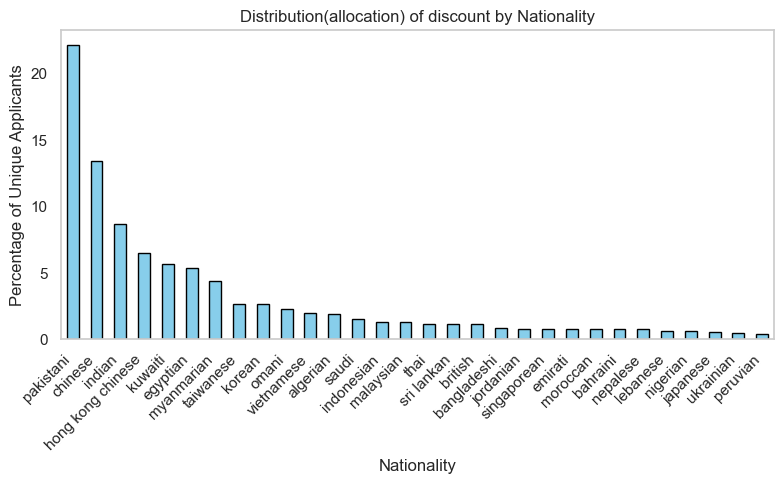

In [1021]:
import matplotlib.pyplot as plt

# Plotting the discount percentage by nationality (top 30) as a bar chart
plt.figure(figsize=(8, 5))
discount_percentage_by_nationality_sorted_top_30.plot(kind='bar', color='skyblue', edgecolor='black')

# Adding titles and labels
plt.title("Distribution(allocation) of discount by Nationality", fontsize=12)
plt.xlabel("Nationality", fontsize=12)
plt.ylabel("Percentage of Unique Applicants", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Removing gridlines
plt.grid(False)

# Display the plot
plt.tight_layout()
plt.show()

**What is the conversion rate of unique applicants with an offer and discount by Nationality?**

In [1051]:
# Ensure no duplicates, each student is counted only once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer and a discount
applicants_with_offer_and_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') & 
    (unique_applicants['discount'] == 'yes')
]

# Count the number of unique applicants who received an offer and discount by nationality
total_applicants_with_offer_and_discount = applicants_with_offer_and_discount.groupby(
    'nationality')['student_id'].nunique()

# Filter nationalities with at least 10 unique applicants
total_applicants_with_offer_and_discount_filtered = total_applicants_with_offer_and_discount[
    total_applicants_with_offer_and_discount >= 10]

# Filter applicants who enrolled after receiving an offer and discount
enrolled_with_offer_and_discount = applicants_with_offer_and_discount[
    applicants_with_offer_and_discount['arrived_date'] == 'yes'
]

# Count the number of unique applicants who enrolled with offer and discount by nationality
enrolled_with_offer_and_discount_by_nationality = enrolled_with_offer_and_discount.groupby(
    'nationality')['student_id'].nunique()

# Count the number of unique applicants who did not enroll with offer and discount by nationality
not_enrolled_with_offer_and_discount_by_nationality = applicants_with_offer_and_discount.groupby(
    'nationality')['student_id'].nunique() - enrolled_with_offer_and_discount_by_nationality

# Filter the nationalities to only include those with at least 10 applicants
enrolled_with_offer_and_discount_by_nationality_filtered = enrolled_with_offer_and_discount_by_nationality[
    total_applicants_with_offer_and_discount_filtered.index]
not_enrolled_with_offer_and_discount_by_nationality_filtered = not_enrolled_with_offer_and_discount_by_nationality[
    total_applicants_with_offer_and_discount_filtered.index]

# Calculate percentages
enrolled_percentage_by_nationality = (enrolled_with_offer_and_discount_by_nationality_filtered /
                                      total_applicants_with_offer_and_discount_filtered) * 100
not_enrolled_percentage_by_nationality = (not_enrolled_with_offer_and_discount_by_nationality_filtered /
                                          total_applicants_with_offer_and_discount_filtered) * 100

# Combine the counts and percentages into a single DataFrame
enrollment_status_by_nationality_offer_discount_percentage = pd.DataFrame({
    'Enrolled with Offer and Discount (%)': enrolled_percentage_by_nationality,
    'Not Enrolled with Offer and Discount (%)': not_enrolled_percentage_by_nationality
}).fillna(0)

# Sort by 'Enrolled with Offer and Discount (%)' in descending order
enrollment_status_by_nationality_offer_discount_percentage_sorted = enrollment_status_by_nationality_offer_discount_percentage.sort_values(
    by='Enrolled with Offer and Discount (%)', ascending=False)

# Print the sorted result for nationalities with at least 10 applicants
print("Nationalities with at least 10 Applicants Enrolled with Offer and Discount (Percentage):")
print(enrollment_status_by_nationality_offer_discount_percentage_sorted)

Nationalities with at least 10 Applicants Enrolled with Offer and Discount (Percentage):
                   Enrolled with Offer and Discount (%)  \
nationality                                               
omani                                         97.297297   
kuwaiti                                       94.444444   
korean                                        92.857143   
emirati                                       92.307692   
myanmarian                                    90.000000   
singaporean                                   84.615385   
bahraini                                      84.615385   
jordanian                                     84.615385   
british                                       83.333333   
indonesian                                    80.952381   
malaysian                                     80.952381   
saudi                                         79.166667   
thai                                          78.947368   
algerian                  

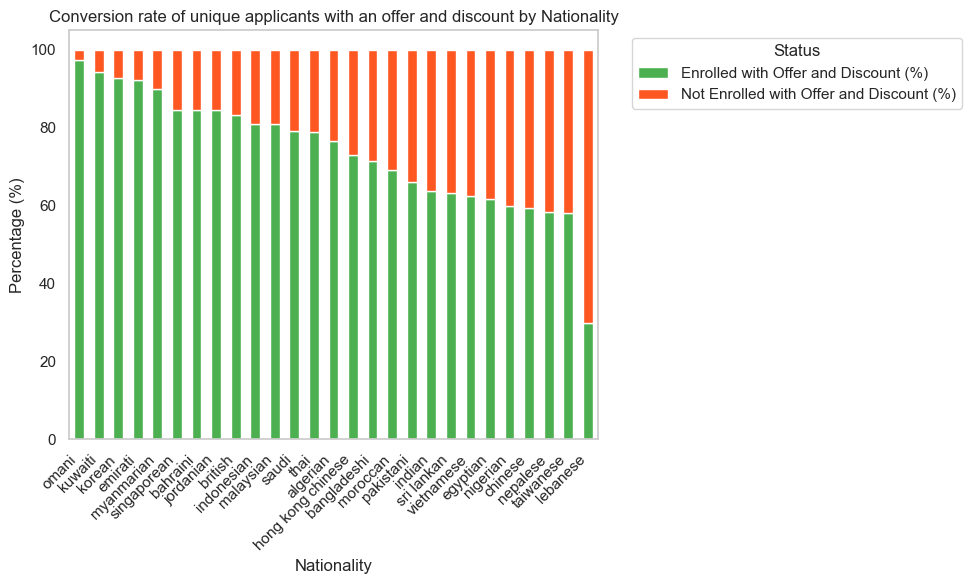

In [1041]:
import matplotlib.pyplot as plt

# Create a bar chart to visualize enrollment and non-enrollment percentages by nationality
ax = enrollment_status_by_nationality_offer_discount_percentage_sorted.plot(
    kind='bar', stacked=True, figsize=(10, 6), color=['#4CAF50', '#FF5722'])

# Set chart title and labels
plt.title('Conversion rate of unique applicants with an offer and discount by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Percentage (%)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show the legend outside the chart
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove gridlines for a cleaner chart
plt.grid(False)

# Show the chart
plt.tight_layout()
plt.show()

**What is the conversion rate of unique applicants with an offer and No discount by Nationality?**

In [1045]:
# Ensure no duplicates, each student is counted only once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer and a discount
applicants_with_offer_and_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') & 
    (unique_applicants['discount'] == 'yes')
]

# Filter applicants who enrolled after receiving an offer and discount
enrolled_with_offer_and_discount = applicants_with_offer_and_discount[
    applicants_with_offer_and_discount['arrived_date'] == 'yes'
]

# Filter applicants who did not enroll after receiving an offer and discount
not_enrolled_with_offer_and_discount = applicants_with_offer_and_discount[
    applicants_with_offer_and_discount['arrived_date'] != 'yes'
]

# Count the number of unique applicants who enrolled with offer and discount by nationality
enrolled_with_offer_and_discount_by_nationality = enrolled_with_offer_and_discount.groupby('nationality')['student_id'].nunique()

# Count the number of unique applicants who did not enroll with offer and discount by nationality
not_enrolled_with_offer_and_discount_by_nationality = not_enrolled_with_offer_and_discount.groupby('nationality')['student_id'].nunique()

# Combine the counts into a single DataFrame
enrollment_status_by_nationality_offer_discount = pd.DataFrame({
    'Enrolled with Offer and Discount': enrolled_with_offer_and_discount_by_nationality,
    'Not Enrolled with Offer and Discount': not_enrolled_with_offer_and_discount_by_nationality
}).fillna(0)

# Sort by 'Enrolled with Offer and Discount' in descending order and get the top 30
enrollment_status_by_nationality_offer_discount_sorted_top_30 = enrollment_status_by_nationality_offer_discount.sort_values(
    by='Enrolled with Offer and Discount', ascending=False).head(30)

# Print the sorted result
print("Top 30 Nationalities with the Most Unique Applicants Enrolled with Offer and Discount:")
print(enrollment_status_by_nationality_offer_discount_sorted_top_30)

Top 30 Nationalities with the Most Unique Applicants Enrolled with Offer and Discount:
                   Enrolled with Offer and Discount  \
nationality                                           
pakistani                                     233.0   
chinese                                       127.0   
indian                                         88.0   
kuwaiti                                        85.0   
hong kong chinese                              76.0   
myanmarian                                     63.0   
egyptian                                       53.0   
korean                                         39.0   
omani                                          36.0   
taiwanese                                      25.0   
algerian                                       23.0   
vietnamese                                     20.0   
saudi                                          19.0   
malaysian                                      17.0   
indonesian                       

**What is the conversion rate of unique applicants with an offer and no discount by Nationality?**

In [1055]:
# Ensure no duplicates, each student is counted only once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer and NO discount
applicants_with_offer_and_no_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') & 
    (unique_applicants['discount'] == 'no')
]

# Filter applicants who enrolled after receiving an offer and NO discount
enrolled_with_offer_and_no_discount = applicants_with_offer_and_no_discount[
    applicants_with_offer_and_no_discount['arrived_date'] == 'yes'
]

# Filter applicants who did not enroll after receiving an offer and NO discount
not_enrolled_with_offer_and_no_discount = applicants_with_offer_and_no_discount[
    applicants_with_offer_and_no_discount['arrived_date'] != 'yes'
]

# Count the number of unique applicants who enrolled with offer and no discount
enrolled_with_offer_and_no_discount_by_nationality = enrolled_with_offer_and_no_discount.groupby(
    'nationality')['student_id'].nunique()

# Count the number of unique applicants who did not enroll with offer and no discount
not_enrolled_with_offer_and_no_discount_by_nationality = not_enrolled_with_offer_and_no_discount.groupby(
    'nationality')['student_id'].nunique()

# Combine the counts into a single DataFrame
enrollment_status_by_nationality_offer_no_discount = pd.DataFrame({
    'Enrolled with Offer and No Discount': enrolled_with_offer_and_no_discount_by_nationality,
    'Not Enrolled with Offer and No Discount': not_enrolled_with_offer_and_no_discount_by_nationality
}).fillna(0)

# Sort by 'Enrolled with Offer and No Discount' in descending order 
# and get the top 30
enrollment_status_by_nationality_offer_no_discount_sorted_top_30 = enrollment_status_by_nationality_offer_no_discount.sort_values(
    by='Enrolled with Offer and No Discount', ascending=False).head(30)

# Print the sorted result
print("Top 30 Nationalities with the Most Unique Applicants Enrolled with Offer and No Discount:")
print(enrollment_status_by_nationality_offer_no_discount_sorted_top_30)

Top 30 Nationalities with the Most Unique Applicants Enrolled with Offer and No Discount:
                   Enrolled with Offer and No Discount  \
nationality                                              
chinese                                          790.0   
saudi                                            131.0   
kuwaiti                                           79.0   
indian                                            73.0   
pakistani                                         54.0   
hong kong chinese                                 46.0   
sri lankan                                        37.0   
qatari                                            32.0   
nigerian                                          29.0   
algerian                                          19.0   
turkish                                           18.0   
thai                                              17.0   
singaporean                                       16.0   
taiwanese                               

In [1067]:
# Ensure no duplicates, each student is counted only once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer and NO discount
applicants_with_offer_and_no_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') & 
    (unique_applicants['discount'] == 'no')
]

# Filter applicants who enrolled after receiving an offer and NO discount
enrolled_with_offer_and_no_discount = applicants_with_offer_and_no_discount[
    applicants_with_offer_and_no_discount['arrived_date'] == 'yes'
]

# Filter applicants who did not enroll after receiving an offer and NO discount
not_enrolled_with_offer_and_no_discount = applicants_with_offer_and_no_discount[
    applicants_with_offer_and_no_discount['arrived_date'] != 'yes'
]

# Count the number of unique applicants who enrolled with offer and no discount by nationality
enrolled_with_offer_and_no_discount_by_nationality = enrolled_with_offer_and_no_discount.groupby(
    'nationality')['student_id'].nunique()

# Count the number of unique applicants who did not enroll with offer and no discount by nationality
not_enrolled_with_offer_and_no_discount_by_nationality = not_enrolled_with_offer_and_no_discount.groupby(
    'nationality')['student_id'].nunique()

# Combine the counts into a single DataFrame
enrollment_status_by_nationality_offer_no_discount = pd.DataFrame({
    'Enrolled with Offer and No Discount': enrolled_with_offer_and_no_discount_by_nationality,
    'Not Enrolled with Offer and No Discount': not_enrolled_with_offer_and_no_discount_by_nationality
}).fillna(0)

# Calculate total number of applicants per nationality (enrolled + not enrolled)
enrollment_status_by_nationality_offer_no_discount['Total Applicants'] = (
    enrollment_status_by_nationality_offer_no_discount['Enrolled with Offer and No Discount'] +
    enrollment_status_by_nationality_offer_no_discount['Not Enrolled with Offer and No Discount']
)

# Filter nationalities with more than 10 applicants
enrollment_status_by_nationality_offer_no_discount_filtered = enrollment_status_by_nationality_offer_no_discount[
    enrollment_status_by_nationality_offer_no_discount['Total Applicants'] > 10
].copy()  # Creating a copy here

# Calculate percentages for each nationality
enrollment_status_by_nationality_offer_no_discount_filtered['Enrolled Percentage'] = (
    (enrollment_status_by_nationality_offer_no_discount_filtered['Enrolled with Offer and No Discount'] /
     enrollment_status_by_nationality_offer_no_discount_filtered['Total Applicants']) * 100
)

enrollment_status_by_nationality_offer_no_discount_filtered['Not Enrolled Percentage'] = (
    (enrollment_status_by_nationality_offer_no_discount_filtered['Not Enrolled with Offer and No Discount'] /
     enrollment_status_by_nationality_offer_no_discount_filtered['Total Applicants']) * 100
)

# Sort by 'Enrolled Percentage' in descending order and get the top 30
enrollment_status_by_nationality_offer_no_discount_filtered_sorted = enrollment_status_by_nationality_offer_no_discount_filtered.sort_values(
    by='Enrolled Percentage', ascending=False).head(30)

# Print the sorted result
print("Top Nationalities (more than 10 applicants) with the Most Unique Applicants Enrolled with Offer and No Discount (as percentage):")
print(enrollment_status_by_nationality_offer_no_discount_filtered_sorted)

Top Nationalities (more than 10 applicants) with the Most Unique Applicants Enrolled with Offer and No Discount (as percentage):
                   Enrolled with Offer and No Discount  \
nationality                                              
zambian                                            6.0   
azerbaijani                                        5.0   
ugandan                                           10.0   
zimbabwean                                        11.0   
angolan                                            4.0   
brazilian                                          4.0   
mexican                                            2.0   
albanian                                           2.0   
korean                                            13.0   
singaporean                                       16.0   
sri lankan                                        37.0   
portuguese                                         2.0   
algerian                                          19.0   
t

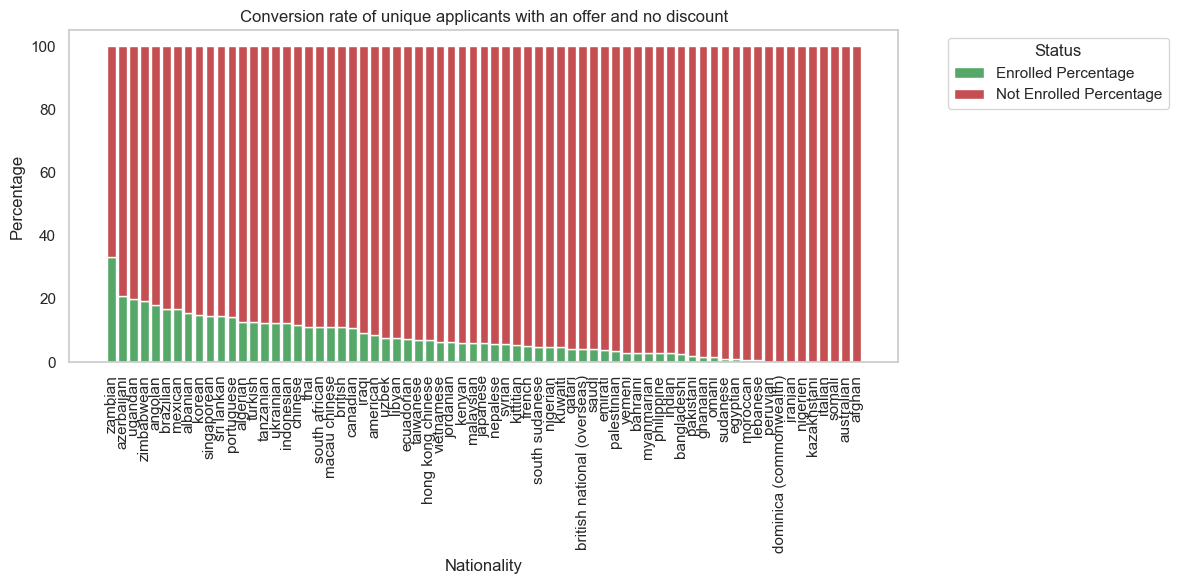

In [1073]:
import matplotlib.pyplot as plt

# Ensure the DataFrame is sorted by the "Enrolled Percentage"
enrollment_status_by_nationality_offer_no_discount_filtered_sorted = enrollment_status_by_nationality_offer_no_discount_filtered.sort_values(
    by='Enrolled Percentage', ascending=False)

# Plotting the stacked bar chart
plt.figure(figsize=(12, 6))

# Create a stacked bar chart
plt.bar(enrollment_status_by_nationality_offer_no_discount_filtered_sorted.index, 
        enrollment_status_by_nationality_offer_no_discount_filtered_sorted['Enrolled Percentage'], 
        label='Enrolled Percentage', color='g')

plt.bar(enrollment_status_by_nationality_offer_no_discount_filtered_sorted.index, 
        enrollment_status_by_nationality_offer_no_discount_filtered_sorted['Not Enrolled Percentage'], 
        label='Not Enrolled Percentage', color='r', bottom=enrollment_status_by_nationality_offer_no_discount_filtered_sorted['Enrolled Percentage'])

# Adding labels and title
plt.xlabel('Nationality')
plt.ylabel('Percentage')
plt.title('Conversion rate of unique applicants with an offer and no discount')
plt.xticks(rotation=90)  
# Remove gridlines
plt.grid(False)

# Move the legend outside the plot
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot 
plt.tight_layout()
plt.show()

**How is discount distributed across for unique applicants with an offer by Sub-region?**

In [1082]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer (offered_date == 'yes')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] == 'yes']

# Filter applicants who received a discount ("yes" in the discount column)
applicants_with_discount = applicants_with_offer[applicants_with_offer['discount'] == 'yes']

# Group by 'region' and count the unique 'student_id' who received a discount
discount_by_region = applicants_with_discount.groupby('region')['student_id'].nunique()

# Sort by the number of unique applicants in descending order
discount_by_region_sorted = discount_by_region.sort_values(ascending=False)

# Output the sorted result for all regions
print("Number of Unique Applicants by Region who received a Discount (Sorted):")
print(discount_by_region_sorted)

Number of Unique Applicants by Region who received a Discount (Sorted):
region
pakistan                       306
uk & w europe                  204
middle east                    169
india                          129
se asia 2                      129
hong kong                      110
north asia                      94
s europe, levant & n africa     91
n c2 china                      69
e c1 china                      68
s w china                       62
se asia 1                       52
rest of s asia                  37
na & lam                        26
russia, e europe, c asia        15
rest of africa                  13
anz                              9
nigeria                          7
Name: student_id, dtype: int64


In [1084]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer (offered_date == 'yes')
applicants_with_offer = unique_applicants[unique_applicants['offered_date'] == 'yes']

# Filter applicants who received a discount ("yes" in the discount column)
applicants_with_discount = applicants_with_offer[applicants_with_offer['discount'] == 'yes']

# Group by 'region' and count the unique 'student_id' who received a discount
discount_by_region = applicants_with_discount.groupby('region')['student_id'].nunique()

# Calculate the total number of applicants who received a discount
total_discount_applicants = applicants_with_discount['student_id'].nunique()

# Calculate the percentage for each region as a distribution of the discount total
discount_percentage_by_region = (discount_by_region / total_discount_applicants) * 100

# Sort by percentage in descending order
discount_percentage_by_region_sorted = discount_percentage_by_region.sort_values(ascending=False)

# Output the sorted result with percentages
print("Percentage of Unique Applicants by Region who received a Discount (Sorted):")
print(discount_percentage_by_region_sorted)

Percentage of Unique Applicants by Region who received a Discount (Sorted):
region
pakistan                       19.245283
uk & w europe                  12.830189
middle east                    10.628931
india                           8.113208
se asia 2                       8.113208
hong kong                       6.918239
north asia                      5.911950
s europe, levant & n africa     5.723270
n c2 china                      4.339623
e c1 china                      4.276730
s w china                       3.899371
se asia 1                       3.270440
rest of s asia                  2.327044
na & lam                        1.635220
russia, e europe, c asia        0.943396
rest of africa                  0.817610
anz                             0.566038
nigeria                         0.440252
Name: student_id, dtype: float64


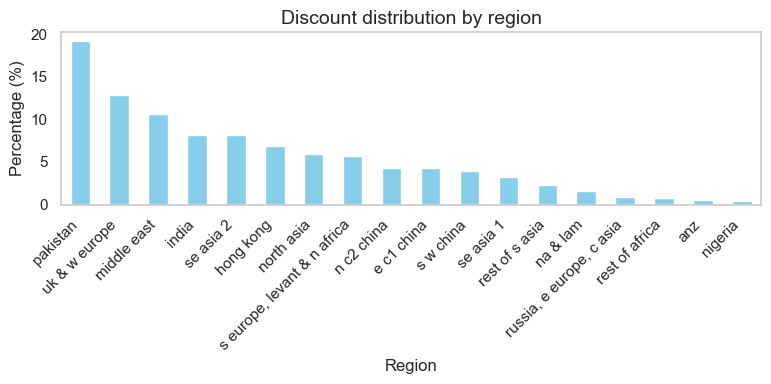

In [1090]:
import matplotlib.pyplot as plt

# Plot the bar chart
plt.figure(figsize=(8, 4))
discount_percentage_by_region_sorted.plot(kind='bar', color='skyblue')

# Adding labels and title
plt.title("Discount distribution by region", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Remove gridlines
plt.grid(False)

# Display the chart
plt.tight_layout()
plt.show()

**What is the conversion rate of unique applicants with an offer and discount by Region?**

In [1100]:
# Ensure no duplicates, each student is counted only once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer and a discount
applicants_with_offer_and_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') & 
    (unique_applicants['discount'] == 'yes')
]

# Filter applicants who enrolled after receiving an offer and discount
enrolled_with_offer_and_discount = applicants_with_offer_and_discount[
    applicants_with_offer_and_discount['arrived_date'] == 'yes'
]

# Filter applicants who did not enroll after receiving an offer and discount
not_enrolled_with_offer_and_discount = applicants_with_offer_and_discount[
    applicants_with_offer_and_discount['arrived_date'] != 'yes'
]

# Count the number of unique applicants who enrolled with offer and discount by region
enrolled_with_offer_and_discount_by_region = enrolled_with_offer_and_discount.groupby('region')['student_id'].nunique()

# Count the number of unique applicants who did not enroll with offer and discount by region
not_enrolled_with_offer_and_discount_by_region = not_enrolled_with_offer_and_discount.groupby('region')['student_id'].nunique()

# Combine the counts into a single DataFrame
enrollment_status_by_region_offer_discount = pd.DataFrame({
    'Enrolled with Offer and Discount': enrolled_with_offer_and_discount_by_region,
    'Not Enrolled with Offer and Discount': not_enrolled_with_offer_and_discount_by_region
}).fillna(0)

# Calculate total number of applicants per region (enrolled + not enrolled)
enrollment_status_by_region_offer_discount['Total Applicants'] = (
    enrollment_status_by_region_offer_discount['Enrolled with Offer and Discount'] +
    enrollment_status_by_region_offer_discount['Not Enrolled with Offer and Discount']
)

# Calculate the enrollment percentage for each region
enrollment_status_by_region_offer_discount['Enrolled Percentage'] = (
    (enrollment_status_by_region_offer_discount['Enrolled with Offer and Discount'] /
     enrollment_status_by_region_offer_discount['Total Applicants']) * 100
)

# Calculate the not enrolled percentage for each region
enrollment_status_by_region_offer_discount['Not Enrolled Percentage'] = (
    (enrollment_status_by_region_offer_discount['Not Enrolled with Offer and Discount'] /
     enrollment_status_by_region_offer_discount['Total Applicants']) * 100
)

# Sort by 'Enrolled Percentage' in descending order
enrollment_status_by_region_offer_discount_sorted = enrollment_status_by_region_offer_discount.sort_values(
    by='Enrolled Percentage', ascending=False)

# Print the sorted result
print("Regions Sorted by the Enrollment Percentage (with Offer and Discount):")
print(enrollment_status_by_region_offer_discount_sorted)

Regions Sorted by the Enrollment Percentage (with Offer and Discount):
                             Enrolled with Offer and Discount  \
region                                                          
se asia 2                                                 116   
middle east                                               148   
na & lam                                                   20   
se asia 1                                                  39   
north asia                                                 70   
hong kong                                                  80   
s europe, levant & n africa                                66   
nigeria                                                     5   
pakistan                                                  212   
russia, e europe, c asia                                   10   
e c1 china                                                 44   
india                                                      83   
rest of s asia     

<Figure size 800x400 with 0 Axes>

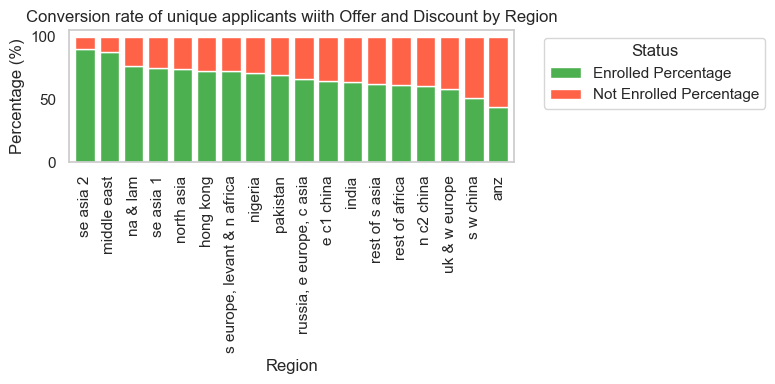

In [1112]:
import matplotlib.pyplot as plt

# Plot the Enrolled and Not Enrolled Percentages for each region as stacked bars
plt.figure(figsize=(8, 4))

# Stacked bar plot for Enrolled and Not Enrolled Percentages
ax = enrollment_status_by_region_offer_discount_sorted[['Enrolled Percentage', 'Not Enrolled Percentage']].plot(
    kind='bar', stacked=True, figsize=(8, 4), color=['#4CAF50', '#FF6347'], width=0.8)

# Set plot title and labels
plt.title('Conversion rate of unique applicants wiith Offer and Discount by Region', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Display the legend outside the plot
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove grid lines
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

**What is the conversion rate of unique applicants with an offer but no discount by Region?**

In [1114]:
# Ensure no duplicates, each student should only be counted once
unique_applicants = sgdata_copy_2.drop_duplicates(subset='student_id')

# Filter applicants who received an offer and NO discount
applicants_with_offer_and_no_discount = unique_applicants[
    (unique_applicants['offered_date'] == 'yes') & 
    (unique_applicants['discount'] == 'no')
]

# Filter applicants who enrolled after receiving an offer and no discount
enrolled_with_offer_and_no_discount = applicants_with_offer_and_no_discount[
    applicants_with_offer_and_no_discount['arrived_date'] == 'yes'
]

# Filter applicants who did not enroll after receiving an offer and no discount
not_enrolled_with_offer_and_no_discount = applicants_with_offer_and_no_discount[
    applicants_with_offer_and_no_discount['arrived_date'] != 'yes'
]

# Count the number of unique applicants who enrolled with offer and no discount by region
enrolled_with_offer_and_no_discount_by_region = enrolled_with_offer_and_no_discount.groupby('region')['student_id'].nunique()

# Count the number of unique applicants who did not enroll with offer and no discount by region
not_enrolled_with_offer_and_no_discount_by_region = not_enrolled_with_offer_and_no_discount.groupby('region')['student_id'].nunique()

# Combine the counts into a single DataFrame
enrollment_status_by_region_offer_no_discount = pd.DataFrame({
    'Enrolled with Offer and No Discount': enrolled_with_offer_and_no_discount_by_region,
    'Not Enrolled with Offer and No Discount': not_enrolled_with_offer_and_no_discount_by_region
}).fillna(0)

# Calculate total number of applicants per region (enrolled + not enrolled)
enrollment_status_by_region_offer_no_discount['Total Applicants'] = (
    enrollment_status_by_region_offer_no_discount['Enrolled with Offer and No Discount'] +
    enrollment_status_by_region_offer_no_discount['Not Enrolled with Offer and No Discount']
)

# Calculate the enrollment percentage for each region
enrollment_status_by_region_offer_no_discount['Enrolled Percentage'] = (
    (enrollment_status_by_region_offer_no_discount['Enrolled with Offer and No Discount'] /
     enrollment_status_by_region_offer_no_discount['Total Applicants']) * 100
)

# Calculate the not enrolled percentage for each region
enrollment_status_by_region_offer_no_discount['Not Enrolled Percentage'] = (
    (enrollment_status_by_region_offer_no_discount['Not Enrolled with Offer and No Discount'] /
     enrollment_status_by_region_offer_no_discount['Total Applicants']) * 100
)

# Sort by 'Enrolled Percentage' in descending order
enrollment_status_by_region_offer_no_discount_sorted = enrollment_status_by_region_offer_no_discount.sort_values(
    by='Enrolled Percentage', ascending=False)

# Print the sorted result
print("Regions Sorted by the Enrollment Percentage (with Offer and No Discount):")
print(enrollment_status_by_region_offer_no_discount_sorted)

Regions Sorted by the Enrollment Percentage (with Offer and No Discount):
                             Enrolled with Offer and No Discount  \
region                                                             
rest of africa                                                41   
e c1 china                                                   299   
n c2 china                                                   263   
rest of s asia                                                50   
se asia 1                                                     26   
s w china                                                    167   
anz                                                            8   
north asia                                                    36   
se asia 2                                                     42   
russia, e europe, c asia                                      10   
hong kong                                                     55   
s europe, levant & n africa               

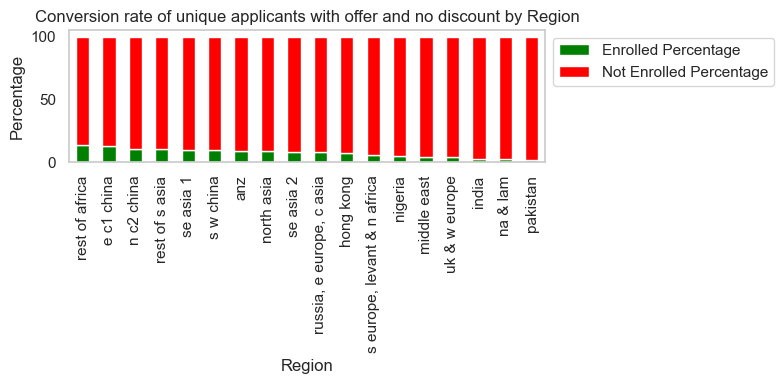

In [1123]:
import matplotlib.pyplot as plt

# Create a stacked bar chart for Enrolled and Not Enrolled percentages
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the stacked bar chart
enrollment_status_by_region_offer_no_discount_sorted[['Enrolled Percentage', 'Not Enrolled Percentage']].plot(
    kind='bar', stacked=True, ax=ax, color=['green', 'red'])

# Set chart title and labels
ax.set_title('Conversion rate of unique applicants with offer and no discount by Region', fontsize=12)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Percentage', fontsize=12)

# Show legend outside the plot
ax.legend(["Enrolled Percentage", "Not Enrolled Percentage"], loc='upper left', bbox_to_anchor=(1, 1))

# Remove grid
ax.grid(False)

# Display the plot
plt.tight_layout()
plt.show()

**Save the dataframe as an excel file**

In [1126]:
# Save the cleaned dataset to an Excel file
sgdata_copy_2.to_excel('sgdata_cleaned.xlsx', index=False, engine='openpyxl')

# Confirm the file is saved
print("Data saved as 'sgdata_cleaned.xlsx'")

Data saved as 'sgdata_cleaned.xlsx'


# 7. Finding relationships in the enrollment of students with different demographic variables within the dataset.

In [1127]:
# Create a copy of DataFrame
sgdata_copy_3 = sgdata_copy_2.copy()

# Display the copied DataFrame 
print(sgdata_copy_3.head())

    centre programme          area     region sub_region agent_location  \
0  cardiff   diploma  anz & n asia        anz  australia      aus - vic   
1  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
2  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
3  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   
4  cardiff   diploma  anz & n asia  hong kong  hong kong      hong kong   

  branch_urn group_urn             lead_source  student_id  ...  \
0     a31552    a31552  standard agent booking     2864317  ...   
1     a15382    a29520  standard agent booking     2853769  ...   
2     a15382    a29520  standard agent booking     2863293  ...   
3      a7608     a7608  standard agent booking     2854643  ...   
4      d1107     d1107  standard agent booking     2871048  ...   

   confirmation_date arrived_date cancellation_date  completed progressed  \
0      not specified           no        10/05/2023         no       

## 7a. Does discount have an effect on the enrolled students in completing the programme successfully?

In [483]:
import pandas as pd
from scipy.stats import chi2_contingency

# Check for dtypes
print(sgdata_copy_3['discount'].dtypes)
print(sgdata_copy_3['arrived_date'].dtypes)

# Filter the data for enrolled students (arrived_date = 'yes')
enrolled_data = sgdata_copy_3[sgdata_copy_3['arrived_date'] == 'yes']

# Create a contingency table for discount vs progression
contingency_table = pd.crosstab(enrolled_data['discount'], enrolled_data['progressed'], margins=True)

# Display the contingency table
print("Contingency Table (Discount vs Progressed):")
print(contingency_table)

# Perform the Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table[['yes', 'no']])

# Display the result of the Chi-squared test
print("\nChi-squared Test Result:")
print(f"Chi-squared value: {chi2}")
print(f"P-value: {p}")

# Interpretation of the result
if p < 0.05:
    print("\nThere is a significant relationship between receiving a discount and progressing in the program.")
else:
    print("\nThere is no significant relationship between receiving a discount and progressing in the program.")


object
object
Contingency Table (Discount vs Progressed):
progressed   no   yes   All
discount                   
no          471  1927  2398
yes         363  1327  1690
All         834  3254  4088

Chi-squared Test Result:
Chi-squared value: 2.0621363956035177
P-value: 0.35662581012692945

There is no significant relationship between receiving a discount and progressing in the program.


**Since the p-value (0.3566) is greater than 0.05, we fail to reject the null hypothesis. This means that there is no 
significant relationship between receiving a discount and progressing in the program. In other words, the discount does 
not appear to have an effect on whether enrolled students progress from the program.**

**The discount status does not significantly affect the likelihood of enrolled students progressing through the program.**

## 7b. Is there a relationship between nationality and student enrollments?

In [484]:
import pandas as pd
import scipy.stats as stats

# Check for dtypes
print(sgdata_copy_3['nationality'].dtypes)
print(sgdata_copy_3['arrived_date'].dtypes)

# Create a contingency table for nationality and enrollment status
contingency_table = pd.crosstab(sgdata_copy_3['nationality'], sgdata_copy_3['arrived_date'])

# Perform the Chi-Square test of independence
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# Display the result
print(f"Chi-Square Statistic: {chi2_stat}")
print(f"P-value: {p_value}")

# If p-value < 0.05, we can reject the null hypothesis, indicating an association
if p_value < 0.05:
    print("There is a significant correlation between nationality and enrollment.")
else:
    print("There is no significant correlation between nationality and enrollment.")


object
object
Chi-Square Statistic: 2388.7663103656632
P-value: 0.0
There is a significant correlation between nationality and enrollment.


**Statistical Significance: The Chi-Square test indicates that nationality and enrollment are not independent. 
Based on the Chi-Square statistic and the P-value, it can be concluded that there is a significant correlation 
between nationality and enrollment. In other words, nationality influences whether or not someone is likely to enroll, 
as the two variables are associated rather than independent.**

## 7c. Does the region of the applicant have an impact on enrollment?

In [489]:
import pandas as pd
import scipy.stats as stats

# Check for dtypes
print(sgdata_copy_3['region'].dtypes)
print(sgdata_copy_3['arrived_date'].dtypes)

# Create a contingency table for region and enrollment status
contingency_table = pd.crosstab(sgdata_copy_3['region'], sgdata_copy_3['arrived_date'])

# Perform the Chi-Square test of independence
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# Display the result
print(f"Chi-Square Statistic: {chi2_stat}")
print(f"P-value: {p_value}")

# If p-value < 0.05, we can reject the null hypothesis, indicating an association
if p_value < 0.05:
    print("There is a significant correlation between region and enrollment.")
else:
    print("There is no significant correlation between region and enrollment.")

object
object
Chi-Square Statistic: 1942.266017218589
P-value: 0.0
There is a significant correlation between region and enrollment.


**The Chi-Square statistic is quite large (1942.26), which suggests that region and enrollment are not independent, and 
there is a strong relationship between them. There is a significant correlation between region and enrollment. This means 
that the region in which an individual is located appears to have an effect on their likelihood to enroll in the program. 
The two variables are dependent, meaning region plays a role in determining whether or not someone enrolls.**
**The P-value of 0.0 is extremely small, which indicates that the probability of observing the data assuming there is no 
relationship between region and enrollment is essentially zero.**

## 7d. Does the area of the applicant have an impact on enrollment?

In [491]:
import pandas as pd
import scipy.stats as stats

# Check for dtypes
print(sgdata_copy_3['area'].dtypes)
print(sgdata_copy_3['arrived_date'].dtypes)

# Create a contingency table for area and enrollment status
contingency_table = pd.crosstab(sgdata_copy_3['area'], sgdata_copy_3['arrived_date'])

# Perform the Chi-Square test of independence
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# Display the result
print(f"Chi-Square Statistic: {chi2_stat}")
print(f"P-value: {p_value}")

# If p-value < 0.05, we can reject the null hypothesis, indicating an association
if p_value < 0.05:
    print("There is a significant correlation between area and enrollment.")
else:
    print("There is no significant correlation between area and enrollment.")

object
object
Chi-Square Statistic: 1754.6928867515596
P-value: 0.0
There is a significant correlation between area and enrollment.


**The Chi-Square statistic value of 1754.69 is quite large which indicates a strong association between area and enrollment.
There is a significant correlation between area and enrollment. This means that area  has a significant effect on 
whether an individual is enrolled or not. The two variables (area and enrollment) are dependent, suggesting 
that the likelihood of enrollment is influenced by the area.**
**The P-value of 0.0 is very small, essentially zero, which indicates that the probability of obtaining this result 
under the null hypothesis (i.e., assuming area and enrollment are independent) is extremely unlikely.**

## 7e. Does the sub-region of the applicant have an impact on enrollment?

In [493]:
import pandas as pd
import scipy.stats as stats

# Check for dtypes
print(sgdata_copy_3['sub_region'].dtypes)
print(sgdata_copy_3['arrived_date'].dtypes)

# Create a contingency table for sub_region and enrollment status
contingency_table = pd.crosstab(sgdata_copy_3['sub_region'], sgdata_copy_3['arrived_date'])

# Perform the Chi-Square test of independence
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# Display the result
print(f"Chi-Square Statistic: {chi2_stat}")
print(f"P-value: {p_value}")

# If p-value < 0.05, we can reject the null hypothesis, indicating an association
if p_value < 0.05:
    print("There is a significant correlation between sub_region and enrollment.")
else:
    print("There is no significant correlation between sub_region and enrollment.")

object
object
Chi-Square Statistic: 2087.8214541072957
P-value: 0.0
There is a significant correlation between sub_region and enrollment.


**The Chi-Square statistic value of 2087.82 which suggests a strong relationship between sub_region and enrollment. 
This is a clear indication that the two variables are not independent.**
**There is a significant correlation between sub_region and enrollment. This means that the sub_region plays a role 
in determining whether an individual is enrolled or not. The two variables (sub_region and enrollment) are dependent, 
indicating that the likelihood of enrollment is influenced by the sub_region.**


## 7f1. Does discount have an effect on student enrollment?

In [495]:
import pandas as pd
import scipy.stats as stats

# Check for dtypes
print(sgdata_copy_3['discount'].dtypes)
print(sgdata_copy_3['arrived_date'].dtypes)

# Create a contingency table for discount and enrollment status
contingency_table = pd.crosstab(sgdata_copy_3['discount'], sgdata_copy_3['arrived_date'])

# Perform the Chi-Square test of independence
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# Display the result
print(f"Chi-Square Statistic: {chi2_stat}")
print(f"P-value: {p_value}")

# If p-value < 0.05, we can reject the null hypothesis, indicating an association
if p_value < 0.05:
    print("There is a significant correlation between discount and enrollment.")
else:
    print("There is no significant correlation between discount and enrollment.")

object
object
Chi-Square Statistic: 18599.065984100165
P-value: 0.0
There is a significant correlation between discount and enrollment.


**The Chi-Square statistic value of 18599.07 is very large, suggesting that discount and enrollment are strongly related.
There is a significant correlation between discount and enrollment. This suggests that discount plays a significant role 
in influencing the likelihood of enrollment. The two variables are dependent, meaning the presence or magnitude of a discount 
is likely to affect enrollment decisions.**

## 7f2. Does discount have an effect on student enrollment?

In [497]:
import pandas as pd
import statsmodels.api as sm

# 1. Convert 'arrived_date' to binary (1 for 'yes', 0 for 'no')
sgdata_copy_3['arrived_date'] = sgdata_copy_3['arrived_date'].map({'yes': 1, 'no': 0})

# 2. Convert 'discount' to binary (1 for 'yes', 0 for 'no')
sgdata_copy_3['discount'] = sgdata_copy_3['discount'].map({'yes': 1, 'no': 0})

# 3. Define the dependent and independent variables
X = sgdata_copy_3['discount']  # Independent variable (discount)
y = sgdata_copy_3['arrived_date']  # Dependent variable (arrived_date)

# Add a constant to the independent variable to include the intercept in the model
X = sm.add_constant(X)

# 4. Perform the OLS regression
model = sm.OLS(y, X).fit()

# 5. Print the summary of the regression analysis
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           arrived_date   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                 2.513e+04
Date:                Sun, 23 Feb 2025   Prob (F-statistic):               0.00
Time:                        22:53:23   Log-Likelihood:                 13857.
No. Observations:               71754   AIC:                        -2.771e+04
Df Residuals:                   71752   BIC:                        -2.769e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0346      0.001     45.675      0.0

**The findings from the regression model suggests that receiving a discount has a significant positive effect on the likelihood of a student enrolling in the program, with an estimated increase of about 64.6% in enrollment probability for those receiving a discount.
However, R-squared = 0.259 indicates that only about 25.9% of the variation in enrollment can be explained by whether a student received a discount. This suggests that while discounts play a role, other factors also influence enrollment.**